In [1]:
# NN-bax things
import sys

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from matplotlib import pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import random

# NEB things
from ase.io import read
from ase.neb import NEB

from ase.neb import NEBTools
import copy

from ase.calculators.lj import LennardJones

from ase import Atoms
from ase.optimize import LBFGS, MDMin, FIRE
from ase.io import Trajectory

from ase.optimize.basin import BasinHopping
from ase.optimize.minimahopping import MinimaHopping

from ase.visualize import view
from tqdm import tqdm
import sys
import os
import glob
import time
import subprocess
import sys

from fairchem.core import OCPCalculator
from fairchem.core.models.model_registry import available_pretrained_models

import pickle
from sklearn.decomposition import PCA
from scipy.interpolate import griddata


from fairchem.core import OCPCalculator
from fairchem.core.models.model_registry import available_pretrained_models
from fairchem.core.common.tutorial_utils import fairchem_main

# Redirect stderr to null
sys.stderr = open(os.devnull, 'w')


In [2]:
from ase.io import read
from ase.db import connect
from ase.calculators.singlepoint import SinglePointCalculator

# Generating List of Atoms Objects to Write in

In [3]:
ase_calculator = LennardJones(rc=100)
test = Trajectory("/sdf/group/mli/pranav/local_minima_test.traj")
test

In [4]:
energies = []
for i in range(len(test)):
    print(test[i].get_potential_energy())
    energies.append(test[i].get_potential_energy())

-16.505384167423653
-16.505384165417773
-16.505384154630285
-16.5053841656132
-15.533060019886065
-15.935043046941086


In [5]:
initial_ase = copy.deepcopy(test[0])
initial_ase.set_calculator(copy.deepcopy(ase_calculator))
final_ase = copy.deepcopy(test[5])
final_ase.set_calculator(copy.deepcopy(ase_calculator))

In [6]:


# 2.A. NEB using ASE
n_images = 20
images_ase = [initial_ase]
for i in range(1, n_images-1):
    image_ase = initial_ase.copy()
    image_ase.set_calculator(copy.deepcopy(ase_calculator))
    images_ase.append(image_ase)
images_ase.append(final_ase)


neb_ase = NEB(images_ase, climb=False, remove_rotation_and_translation=True, method='string')
neb_ase.interpolate(method='linear')
qn_ase = FIRE(neb_ase)
qn_ase.run(fmax=0.05, steps=500)

      Step     Time          Energy          fmax
FIRE:    0 18:23:14      -15.002005        9.127576
FIRE:    1 18:23:15      -15.406114        2.433229
FIRE:    2 18:23:15      -15.425460        1.701338
FIRE:    3 18:23:15      -15.437039        0.815503
FIRE:    4 18:23:15      -15.431111        1.252813
FIRE:    5 18:23:15      -15.434361        1.065878
FIRE:    6 18:23:15      -15.439041        0.734421
FIRE:    7 18:23:16      -15.442669        0.400627
FIRE:    8 18:23:16      -15.443642        0.371648
FIRE:    9 18:23:16      -15.442445        0.669091
FIRE:   10 18:23:16      -15.442581        0.653378
FIRE:   11 18:23:16      -15.442838        0.622376
FIRE:   12 18:23:16      -15.443186        0.576954
FIRE:   13 18:23:17      -15.443585        0.518500
FIRE:   14 18:23:17      -15.443988        0.449033
FIRE:   15 18:23:17      -15.444351        0.374886
FIRE:   16 18:23:17      -15.444640        0.312046
FIRE:   17 18:23:17      -15.444848        0.270107
FIRE:   18 18:

True

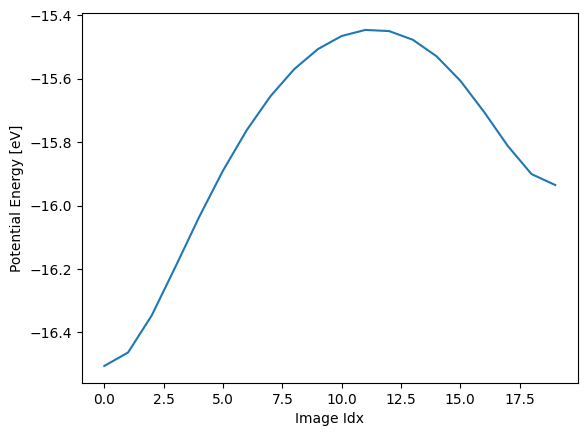

Barrier:  1.0592937540536624


In [7]:
energies = [images_ase[i].get_potential_energy() for i in range(len(images_ase))]
%matplotlib inline
plt.plot(energies)
plt.xlabel('Image Idx')
plt.ylabel('Potential Energy [eV]')

#plt.savefig('lj7_example_energy_barriers.pdf', bbox_inches='tight')
plt.show()
print("Barrier: ", max(energies) - initial_ase.get_potential_energy())

In [8]:
# Assume initial_ase and final_ase are defined as before:
initial_ase = copy.deepcopy(test[0])
initial_ase.set_calculator(copy.deepcopy(ase_calculator))
final_ase = copy.deepcopy(test[5])
final_ase.set_calculator(copy.deepcopy(ase_calculator))

# Define the number of interpolated images

# Create a new list of images via linear interpolation
alphas = np.linspace(0, 1, n_images)
linear_images_ase = []
for alpha in alphas:
    # Interpolate positions between initial and final
    pos_interp = (1 - alpha) * images_ase[0].positions + alpha * images_ase[-1].positions
    # Create a new Atoms object from the initial one and update positions
    atoms_interp = initial_ase.copy()
    atoms_interp.positions = pos_interp
    linear_images_ase.append(atoms_interp)

# Plotting Paths

In [9]:

# Convert ASE Atoms object list to a 2D numpy array (20 steps x 21D positions)
neb_positions = np.array([atoms.positions.flatten() for atoms in images_ase])  # Shape (20, 21)

# Perform PCA (reduce 21D path to 2D)
pca = PCA(n_components=2)
neb_pca = pca.fit_transform(neb_positions)  # Shape (20, 2)

# Extract the transformed coordinates
pca_x, pca_y = neb_pca[:, 0], neb_pca[:, 1]

# Function to calculate LJ energy for a given configuration
def compute_lj_energy(positions):
    atoms = images_ase[0].copy()  # Copy an Atoms object to set new positions
    atoms.set_positions(positions.reshape(7, 3))
    atoms.set_calculator(LennardJones(rc = 100))
    return atoms.get_potential_energy()

# Generate a grid for the contour plot
num_grid = 50  # Resolution of the contour grid
x_min, x_max = pca_x.min() - 0.5, pca_x.max() + 0.5
y_min, y_max = pca_y.min() - 0.5, pca_y.max() + 0.5

#y_min, y_max = -1.25, 0.5

grid_x, grid_y = np.meshgrid(np.linspace(x_min, x_max, num_grid),
                             np.linspace(y_min, y_max, num_grid))

# Correct transformation: use PCA inverse_transform to go back to 21D
grid_points_2d = np.c_[grid_x.ravel(), grid_y.ravel()]
grid_positions = pca.inverse_transform(grid_points_2d)

# Generate potential energy values over the grid
lj_energies = np.array([compute_lj_energy(pos) for pos in grid_positions])
lj_energies = lj_energies.reshape(grid_x.shape)  # Reshape to match grid


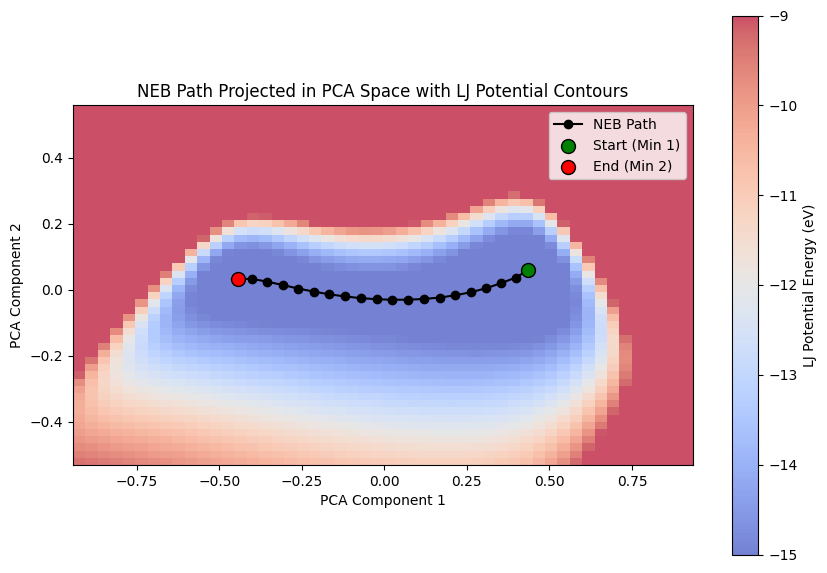

In [10]:
# Plot the contour map of the potential
plt.figure(figsize=(10, 7))
plt.imshow(
    lj_energies,
    cmap="coolwarm",
    alpha=0.7,
    vmin=-15,
    vmax=-9,
    extent=(x_min, x_max, y_min, y_max),
    origin="lower"  # Ensures that the first row of the array is at the bottom.
)

plt.colorbar(label="LJ Potential Energy (eV)")

# Overlay the NEB path (PCA-transformed)
plt.plot(pca_x, pca_y, marker='o', linestyle='-', color="black", label="NEB Path")

# Annotate start and end points
plt.scatter(pca_x[0], pca_y[0], color="green", s=100, label="Start (Min 1)", edgecolors="black", zorder=3)
plt.scatter(pca_x[-1], pca_y[-1], color="red", s=100, label="End (Min 2)", edgecolors="black", zorder=3)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("NEB Path Projected in PCA Space with LJ Potential Contours")
plt.legend()
plt.show()


In [11]:
with open("results/8_29_ELJ7_BAX80_MaxNEB200_Epochs=50_bestFmax_subset_history.pkl", "rb") as f:
    subset_history = np.array(pickle.load(f))
    
    
with open("results/8_29_ELJ7_BAX80_MaxNEB200_Epochs=50_bestFmax_acquired_data.pkl", "rb") as f:
    acquired_data = np.array(pickle.load(f))
    
with open("results/8_29_ELJ7_BAX80_MaxNEB200_Epochs=50_bestFmax_fmax_history.pkl", "rb") as f:
    fmax_history = np.array(pickle.load(f))
    
with open("results/8_29_ELJ7_BAX80_MaxNEB200_Epochs=50_bestFmax_energy_barrier_history_data.pkl", "rb") as f:
    energy_barrier_history = np.array(pickle.load(f))
    
with open("results/8_29_ELJ7_BAX80_MaxNEB200_Epochs=50_bestFmax_mae_Nm1_on_N.pkl", "rb") as f:
    mae_Nm1_on_N = np.array(pickle.load(f))
    


In [12]:
with open("results/7_27_ELJ7_RandSamp80_NEB25_NumInterp20_LinearDev=0_03_Epochs=50_subset_history.pkl", "rb") as f:
    subset_history_random = np.array(pickle.load(f))
    

In [13]:
def recursive_to_numpy(item):
    """
    Recursively convert all torch.Tensor objects in a nested structure
    (lists, tuples, etc.) to numpy arrays.
    """
    if isinstance(item, torch.Tensor):
        # Ensure that if the tensor is on GPU it is first moved to CPU.
        return item.cpu().numpy()
    elif isinstance(item, list):
        return [recursive_to_numpy(sub_item) for sub_item in item]
    elif isinstance(item, tuple):
        return tuple(recursive_to_numpy(sub_item) for sub_item in item)
    else:
        return item

# Convert the entire nested structure to numpy arrays
#subset_history_numpy = np.array(recursive_to_numpy(subset_history))
#subset_history_numpy = subset_history_numpy[:, :, :7*3]

n_baxitr = subset_history.shape[0]
n_img = subset_history.shape[1]

subset_history_numpy = np.array(subset_history).reshape(n_baxitr, n_img, 7*3)
print(subset_history_numpy.shape)

acquired_data_list = acquired_data.reshape(n_baxitr, 7*3)

n_rand_irt = subset_history_random.shape[0]
subset_history_random = np.array(subset_history_random).reshape(n_rand_irt, n_img, 7*3)

(80, 20, 21)


In [14]:
acquired_data.shape

(80, 7, 3)

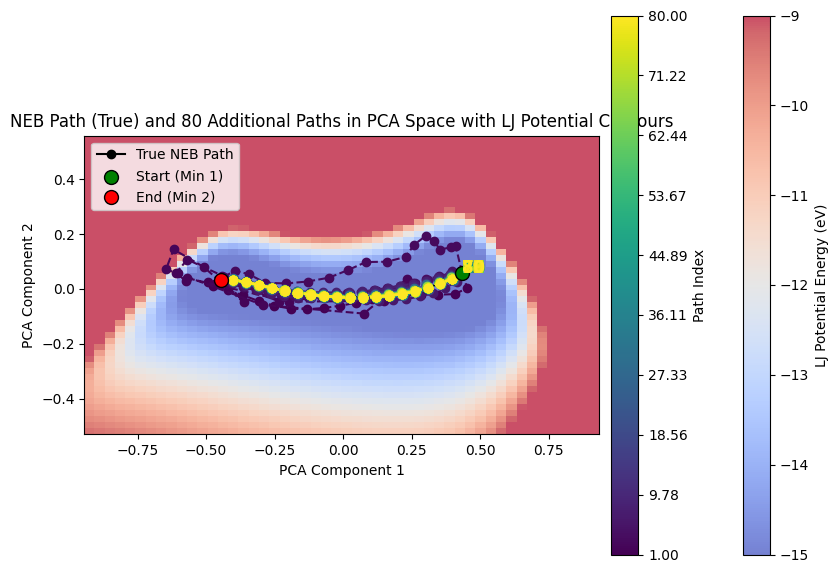

In [15]:
# Assume subset_history_numpy, lj_energies, x_min, x_max, y_min, y_max, pca_x, pca_y, and pca are defined.

# Create a colormap for the paths
num_paths = subset_history_numpy.shape[0]
colors = cm.viridis(np.linspace(0, 1, num_paths))  # Smooth gradient for the paths

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 7))

# Plot the LJ energy contour map (background)
im = ax.imshow(
    lj_energies,
    cmap="coolwarm",
    alpha=0.7,
    vmin=-15,
    vmax=-9,
    extent=(x_min, x_max, y_min, y_max),
    origin="lower"
)
# Add the LJ energy colorbar
fig.colorbar(im, ax=ax, label="LJ Potential Energy (eV)")

# Plot the true NEB path in black with markers
ax.plot(pca_x, pca_y, marker='o', linestyle='-', color="black", label="True NEB Path")
ax.scatter(pca_x[0], pca_y[0], color="green", s=100, label="Start (Min 1)", edgecolors="black", zorder=3)
ax.scatter(pca_x[-1], pca_y[-1], color="red", s=100, label="End (Min 2)", edgecolors="black", zorder=3)

# Plot the additional paths using the smooth gradient colormap
for i, (path, color) in enumerate(zip(subset_history_numpy, colors), start=1):
    path_pca = pca.transform(path)  # Transform the path to PCA space
    ax.plot(path_pca[:, 0], path_pca[:, 1], marker='o', linestyle='--', color=color)
    ax.text(path_pca[0, 0], path_pca[0, 1], f"{i}", fontsize=12,
            fontweight='bold', color=color, zorder=4)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title(f"NEB Path (True) and {num_paths} Additional Paths in PCA Space with LJ Potential Contours")
ax.legend(loc='upper left')

# Create a ScalarMappable for the paths colorbar
norm = mcolors.Normalize(vmin=1, vmax=num_paths)
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])  # Necessary for the colorbar to function properly

# Add the colorbar for the path indices on the side
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Path Index')
cbar.set_ticks(np.linspace(1, num_paths, 10))  # Adjust tick locations as needed

plt.show()


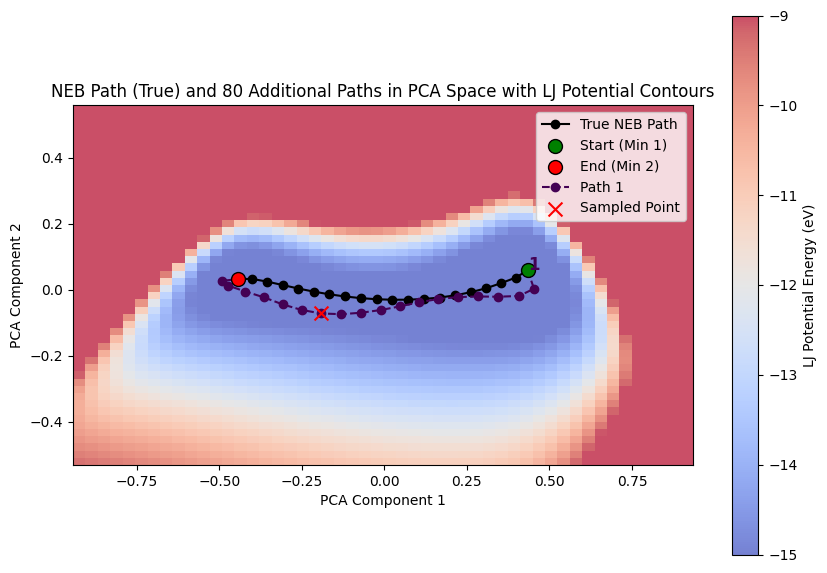

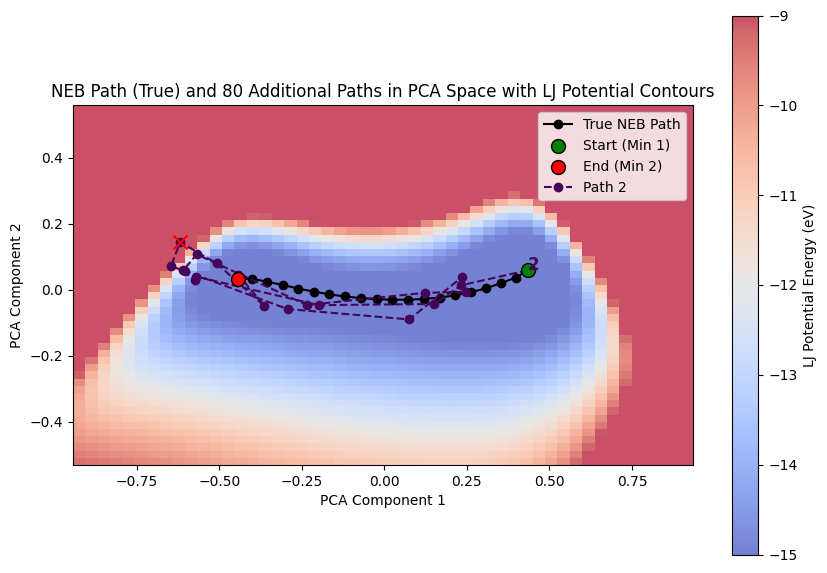

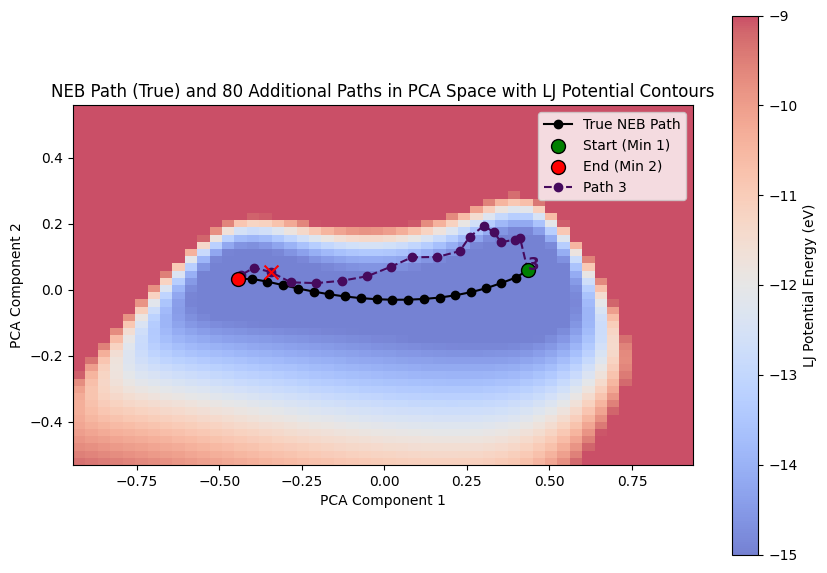

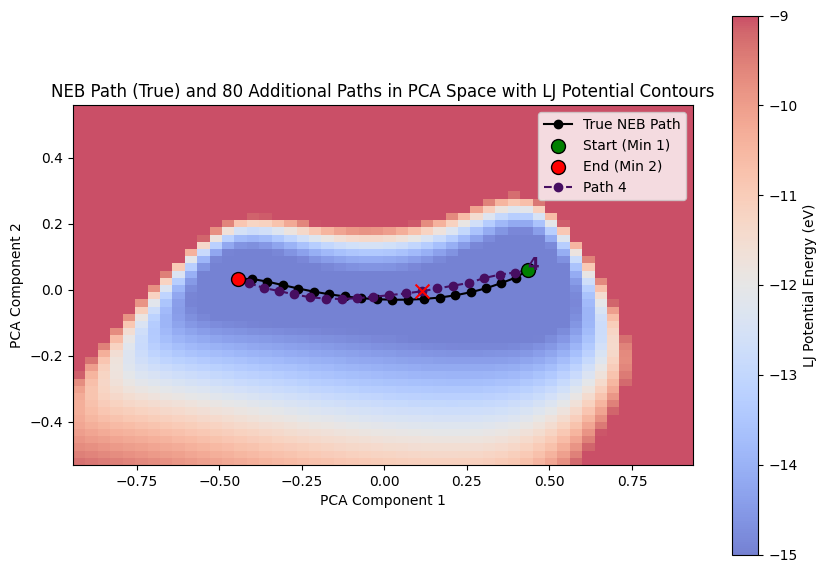

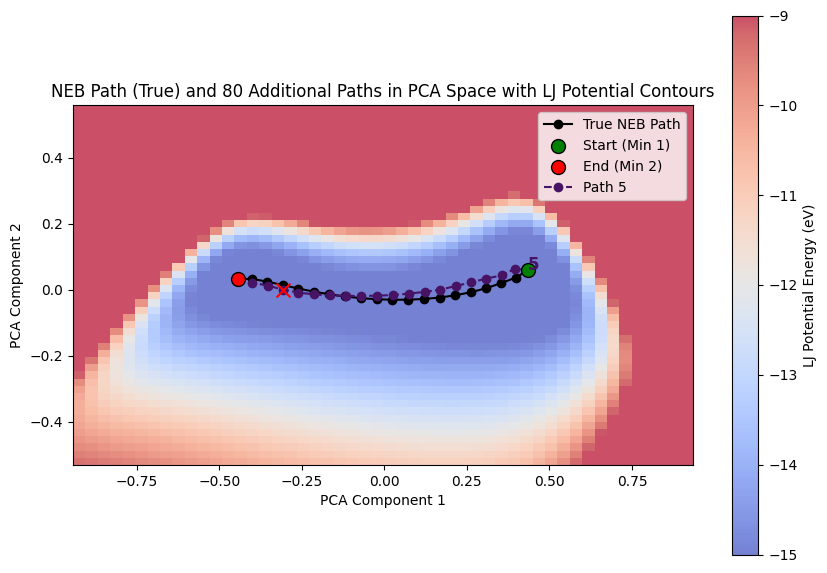

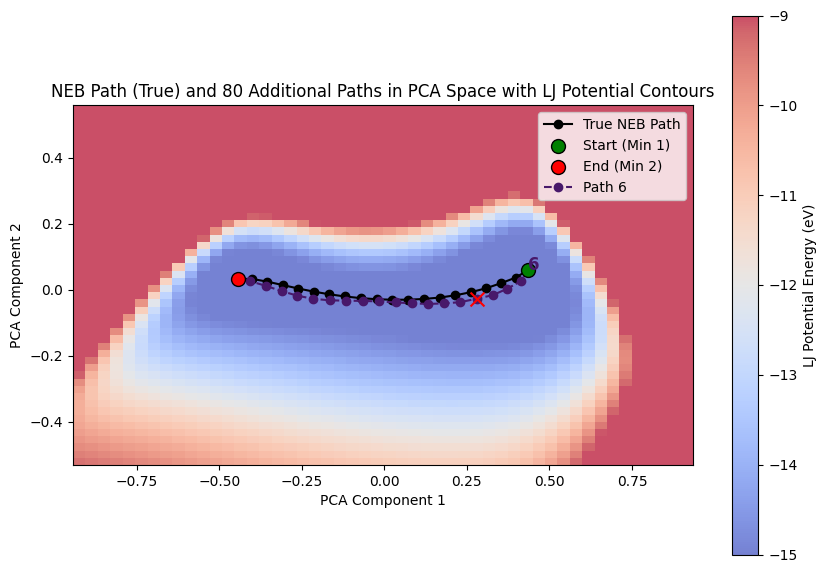

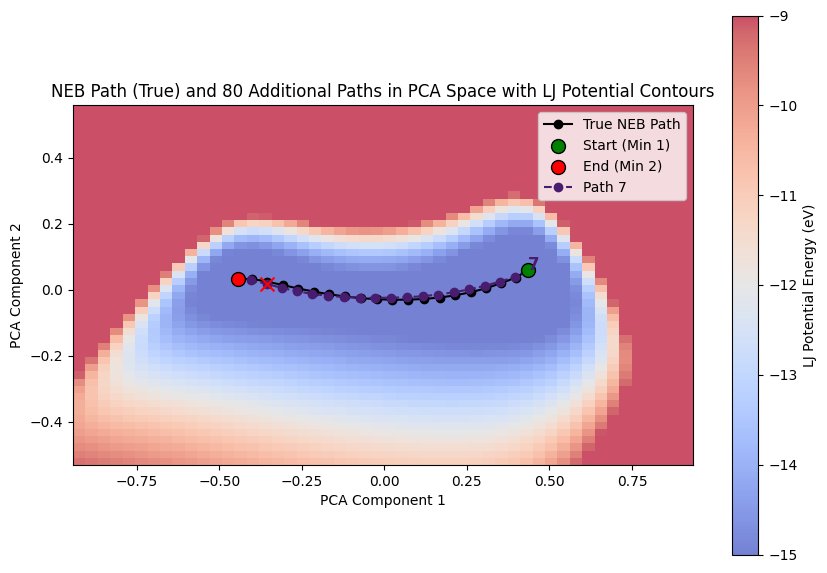

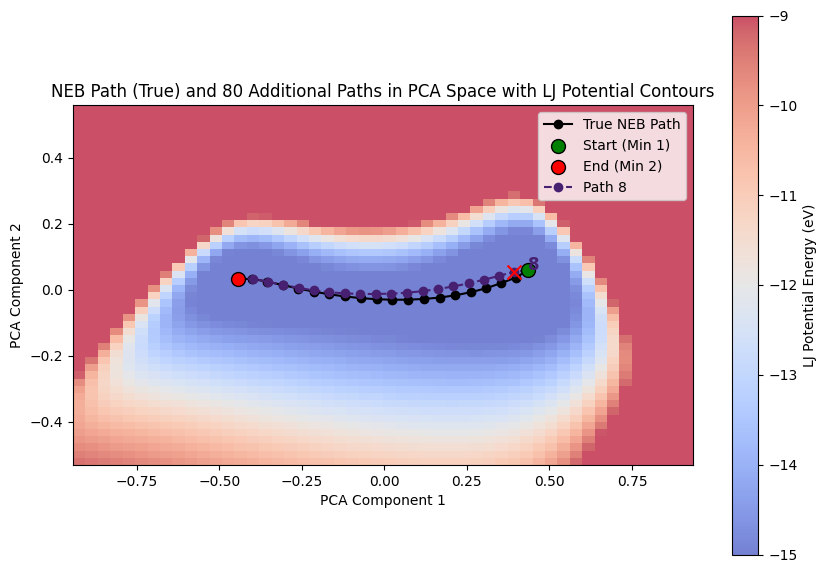

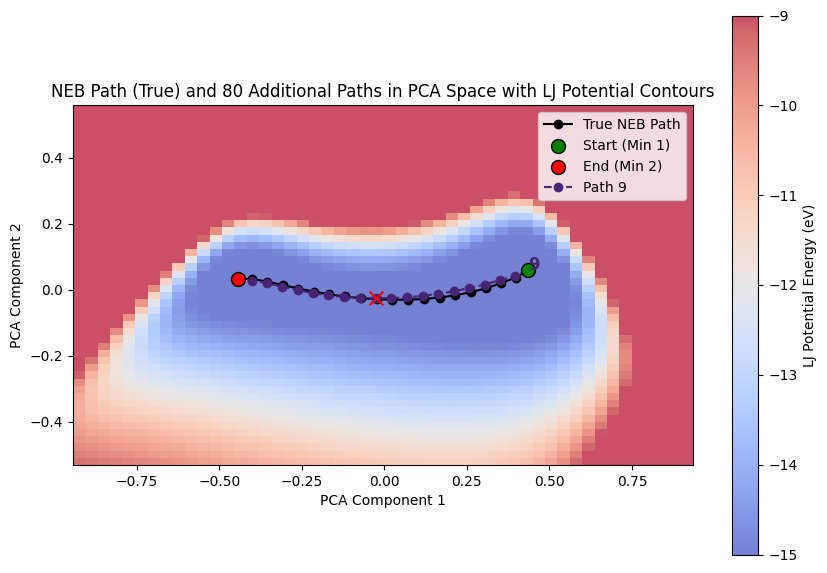

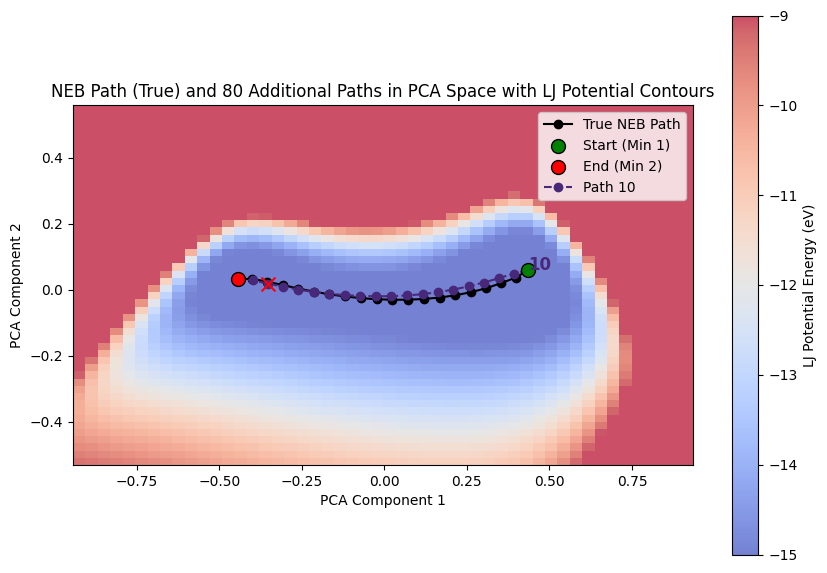

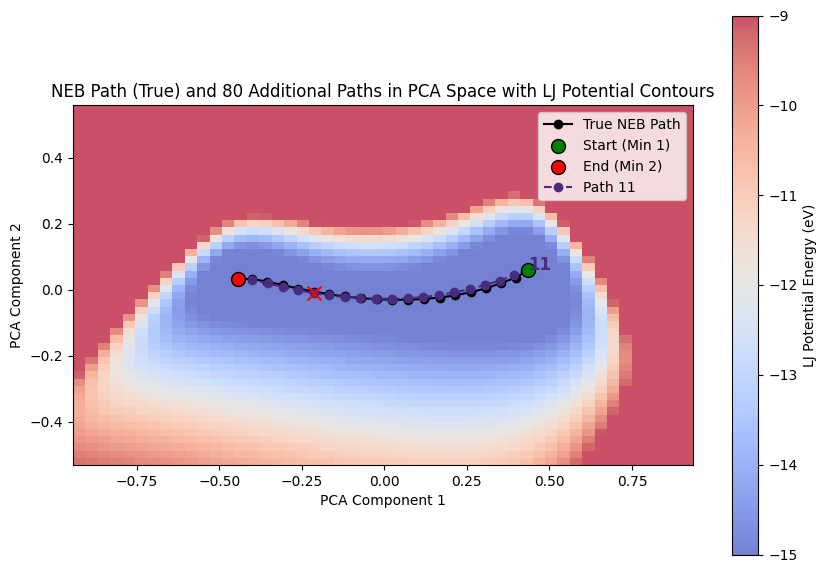

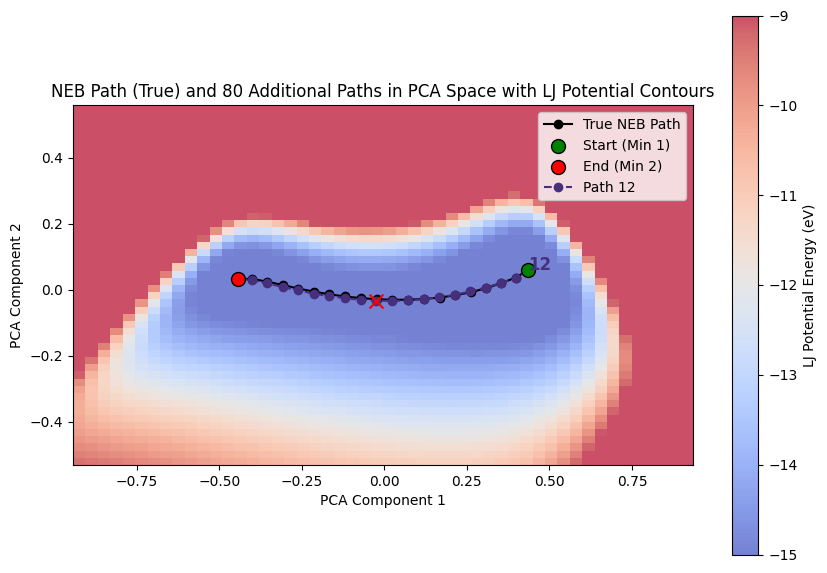

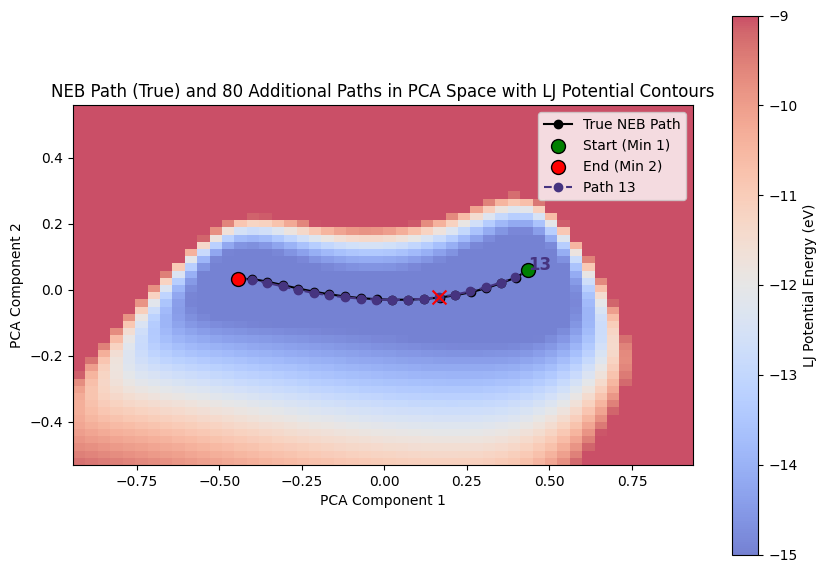

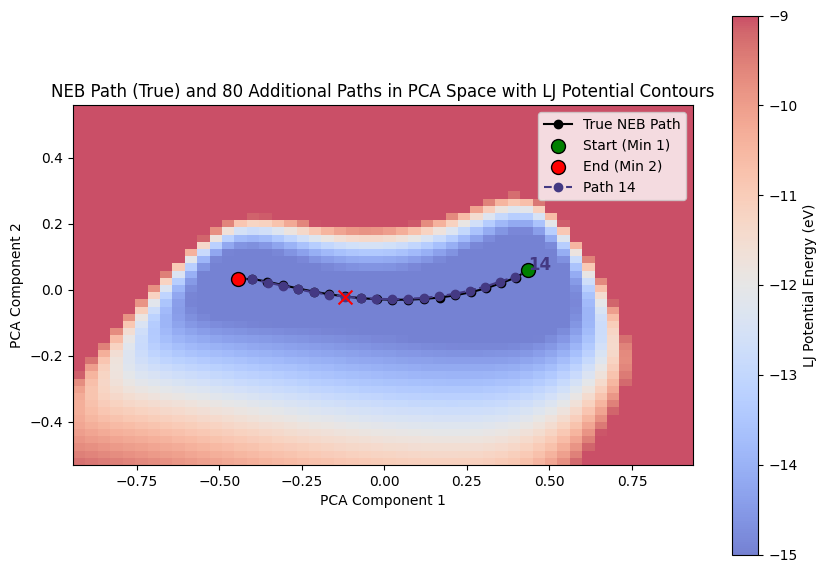

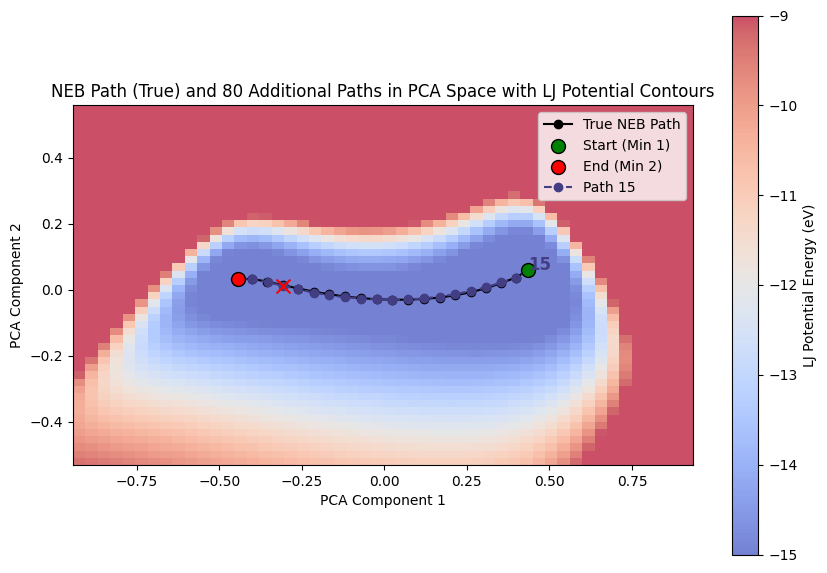

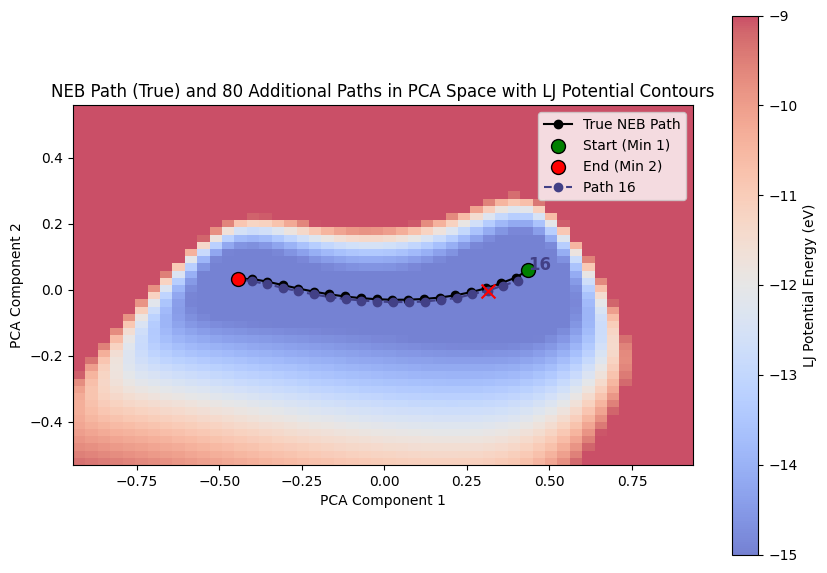

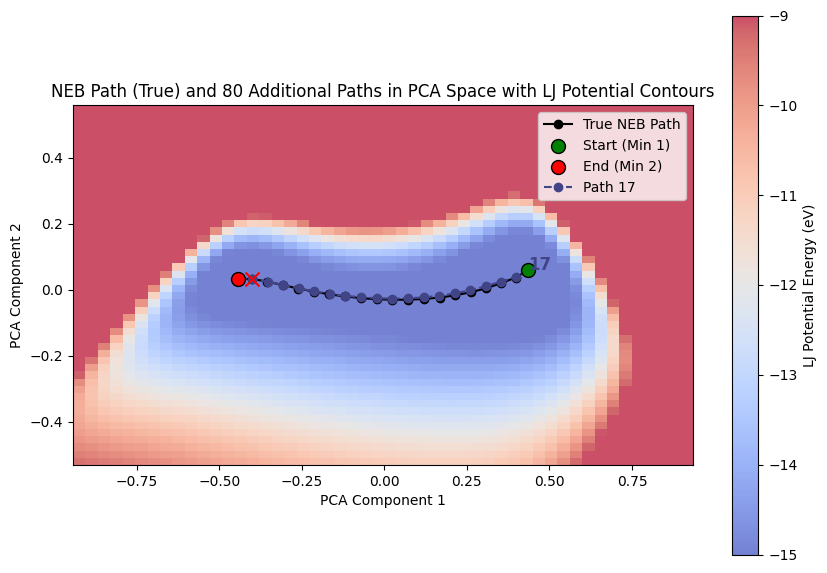

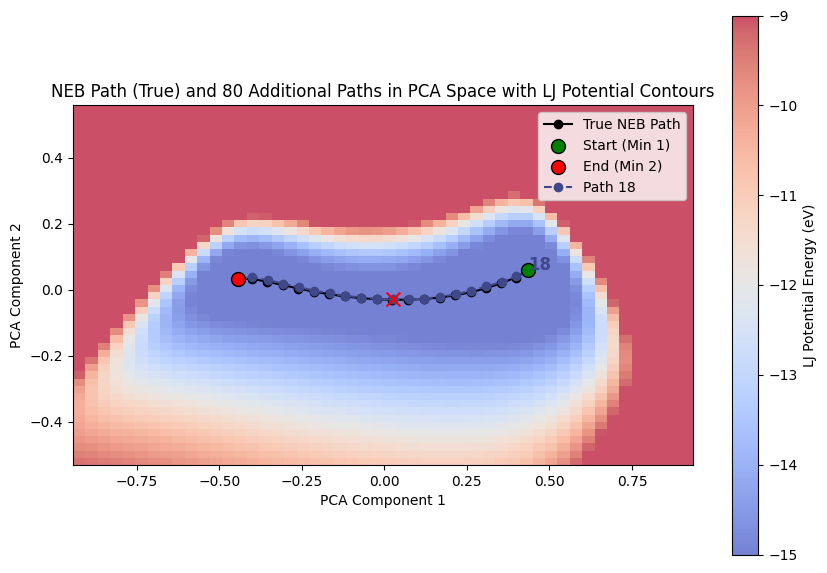

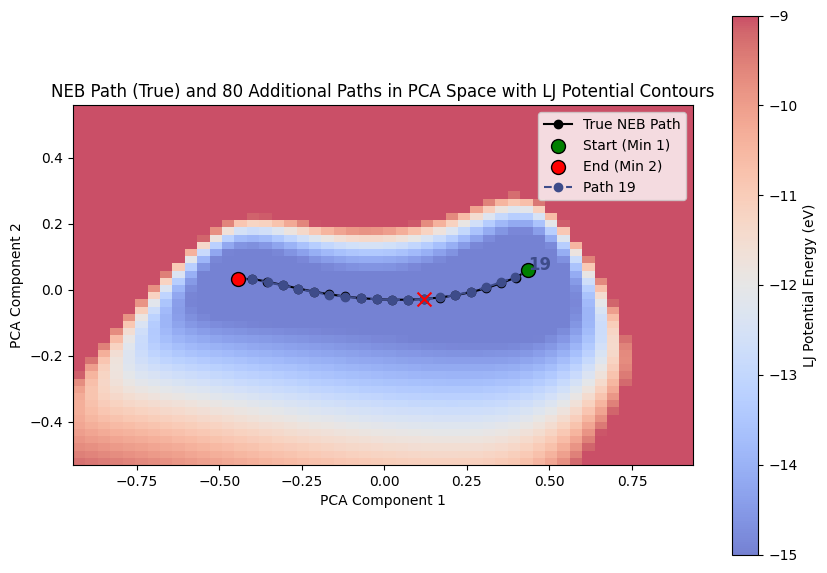

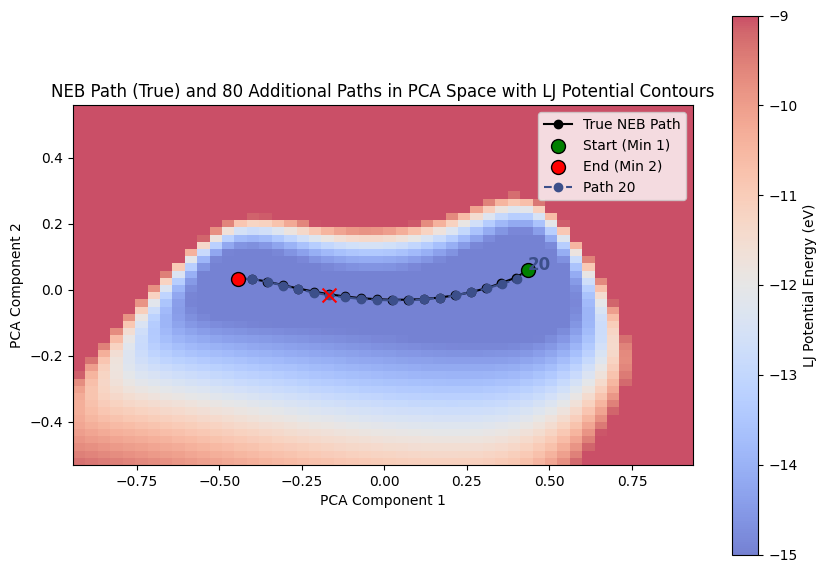

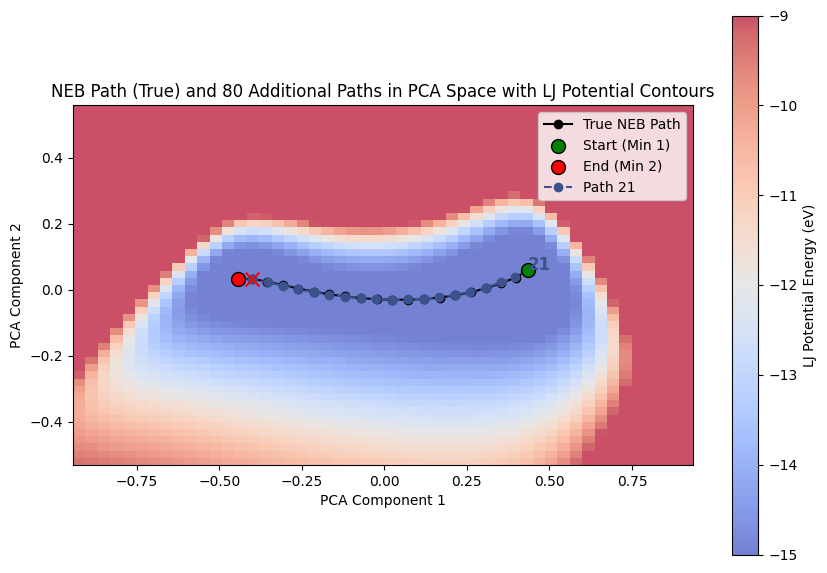

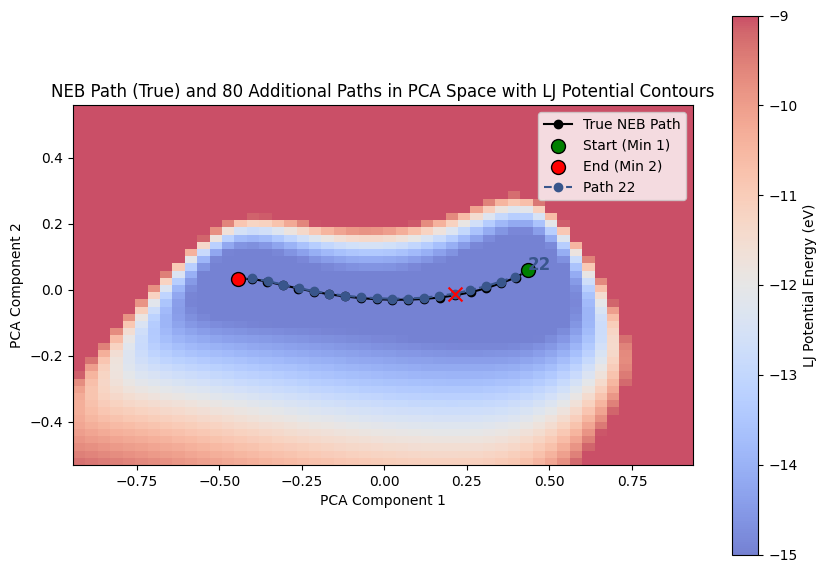

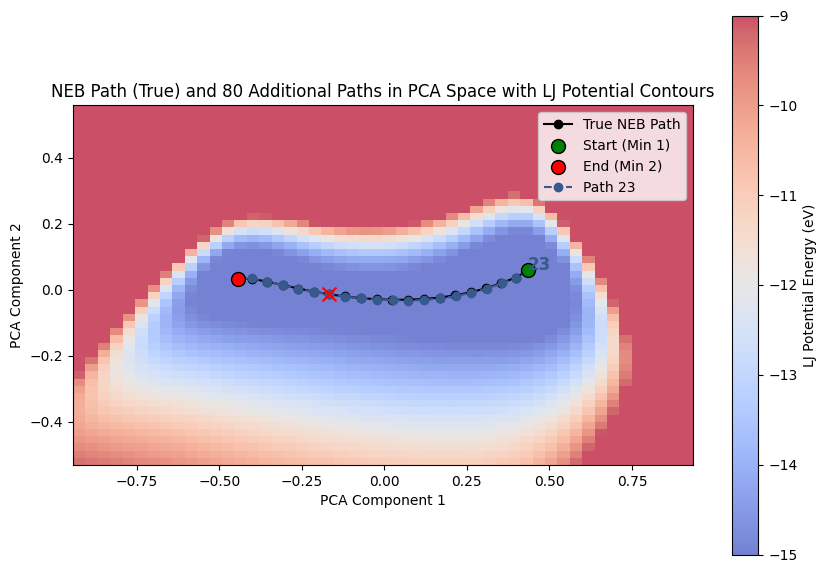

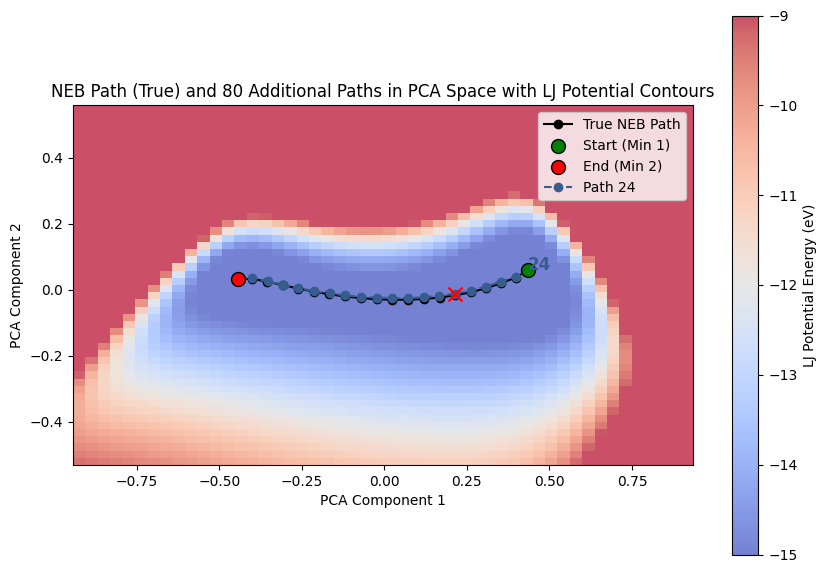

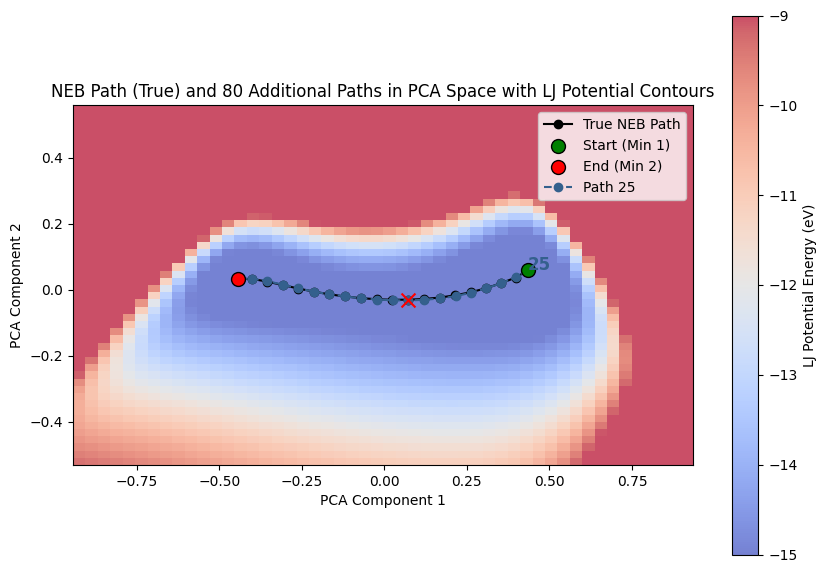

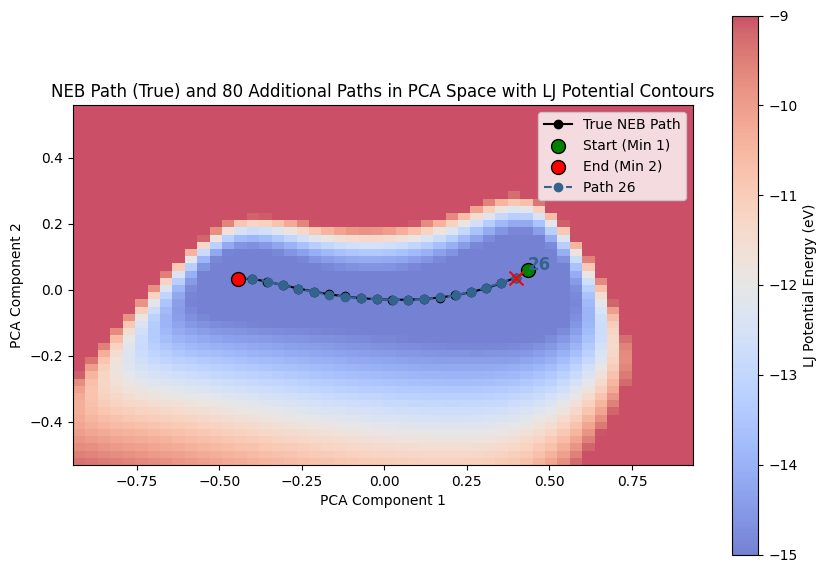

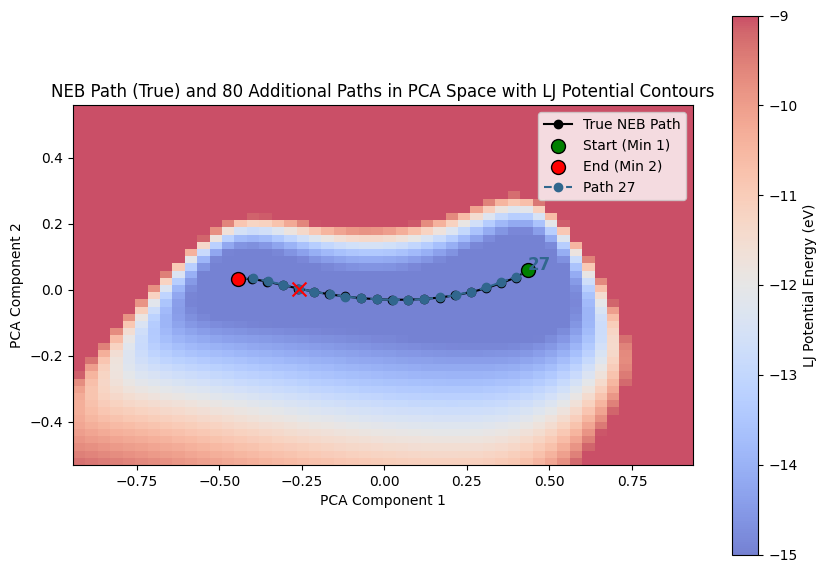

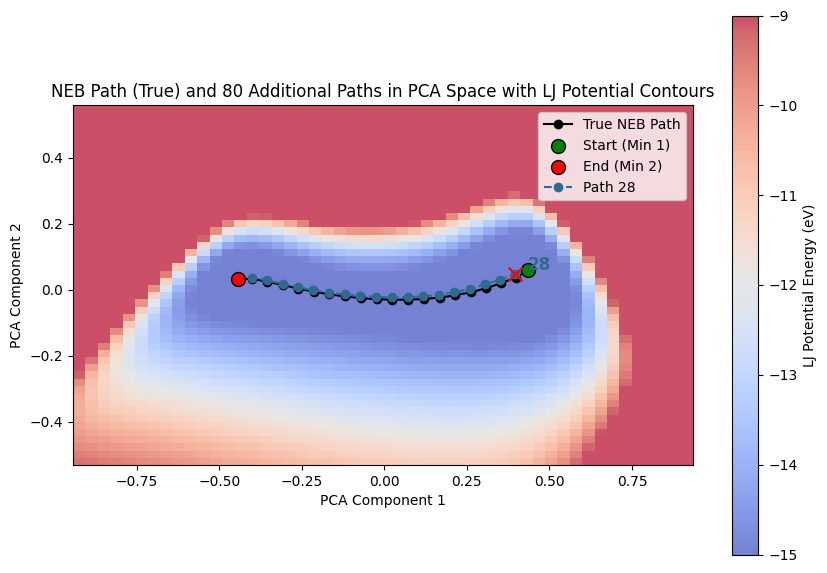

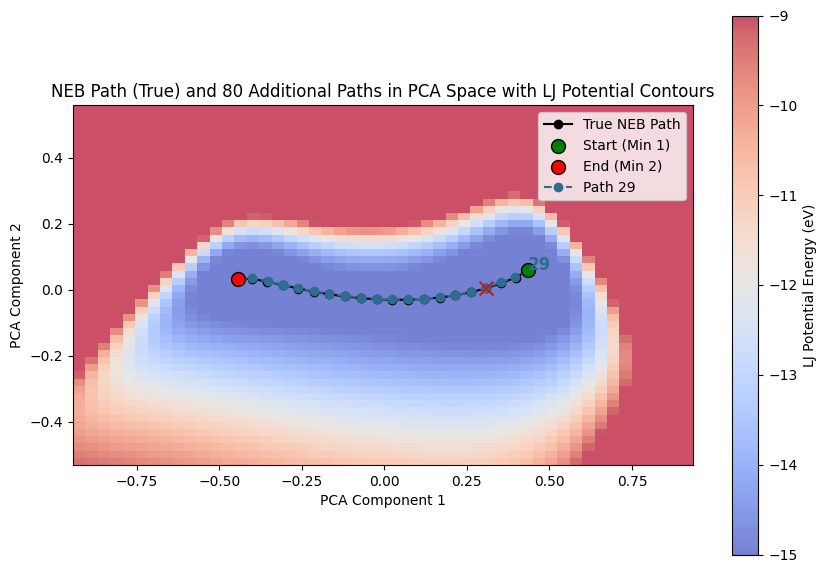

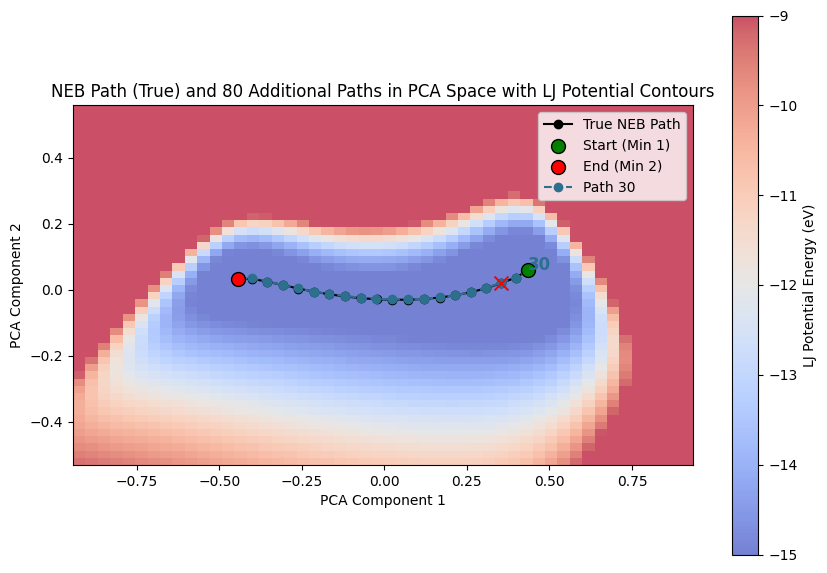

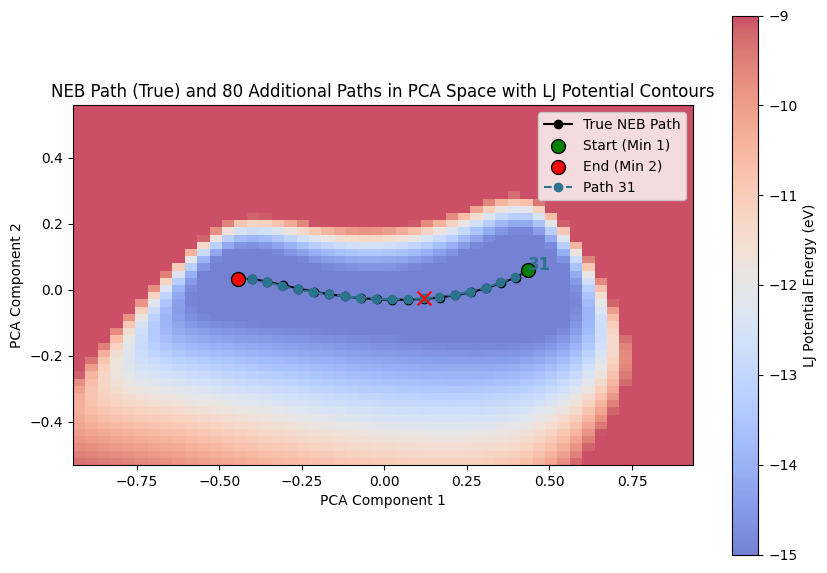

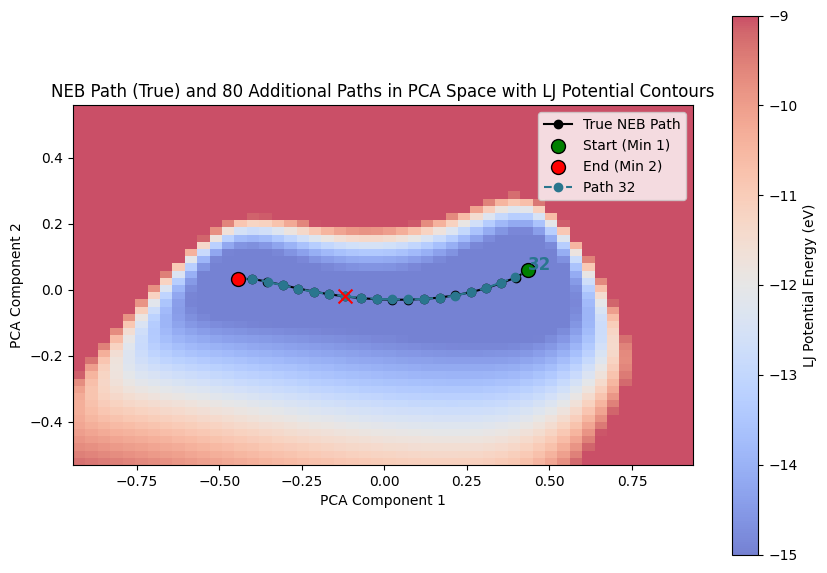

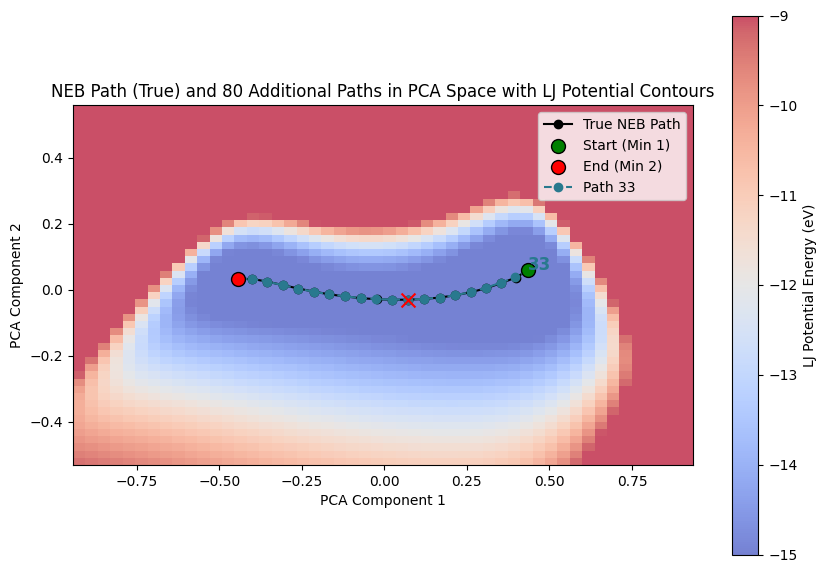

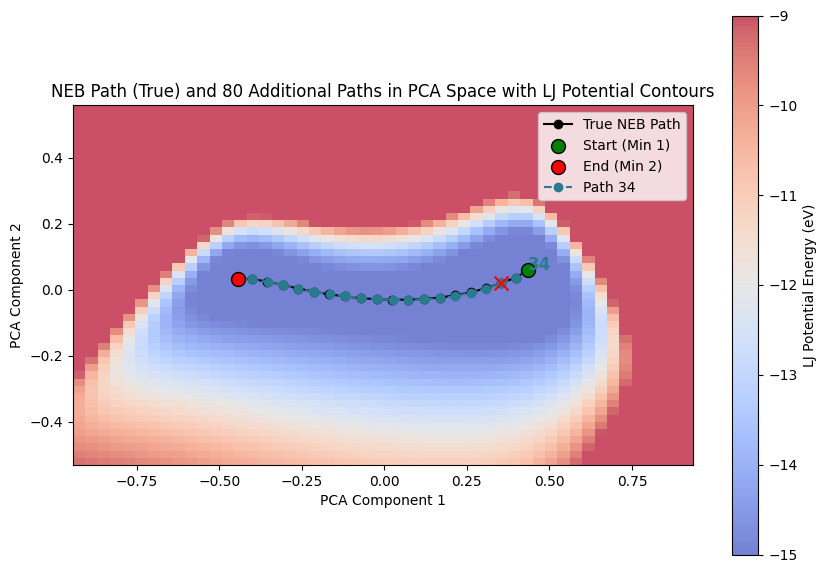

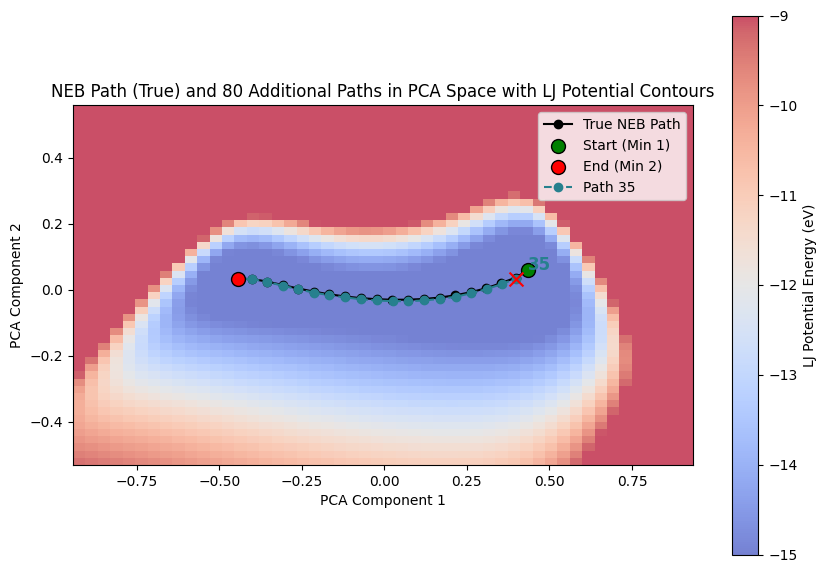

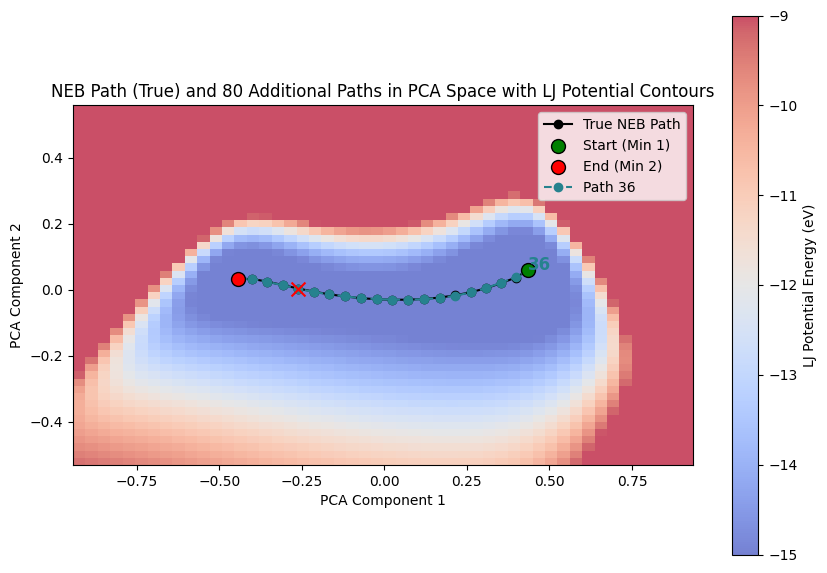

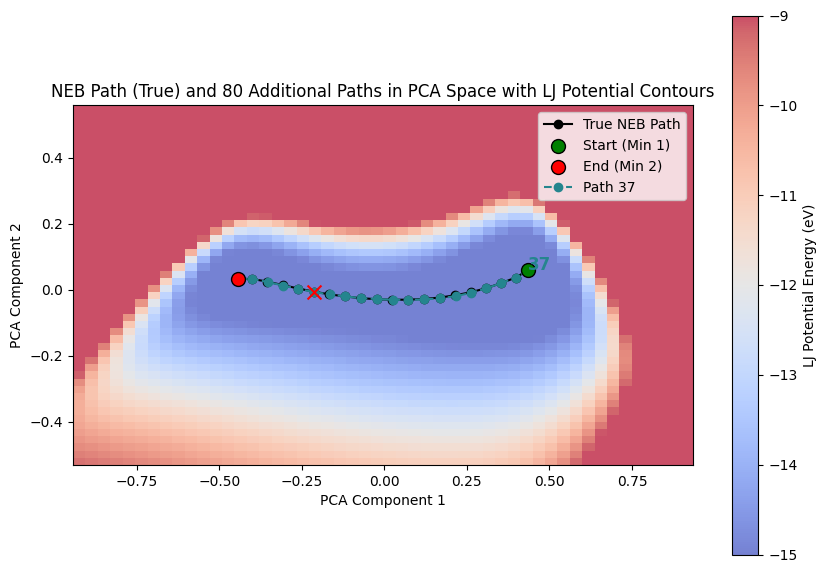

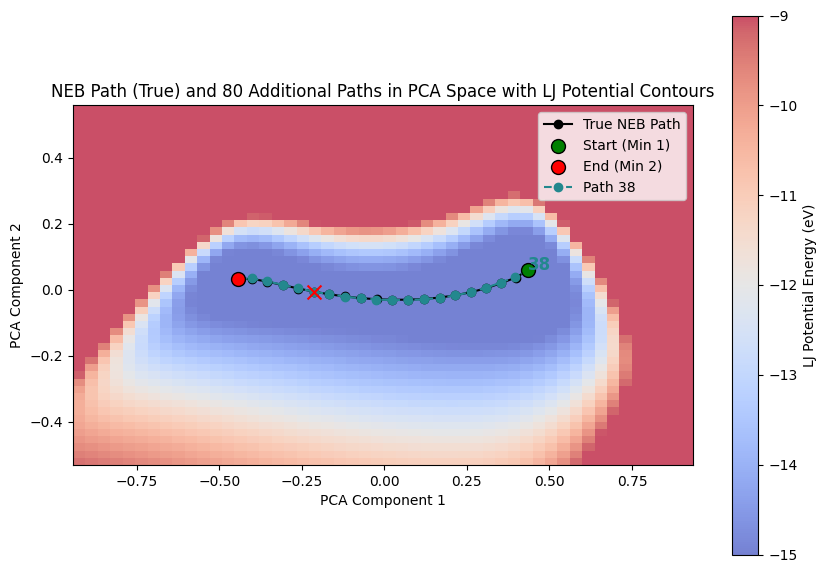

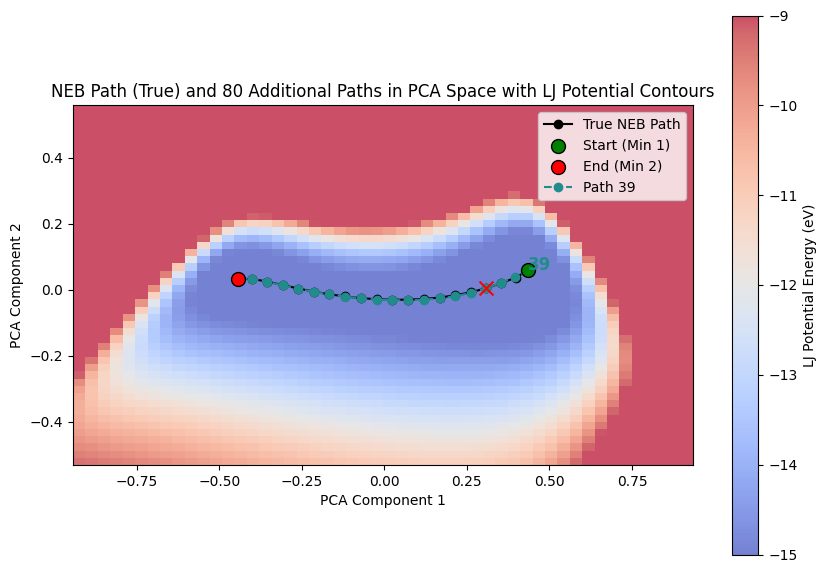

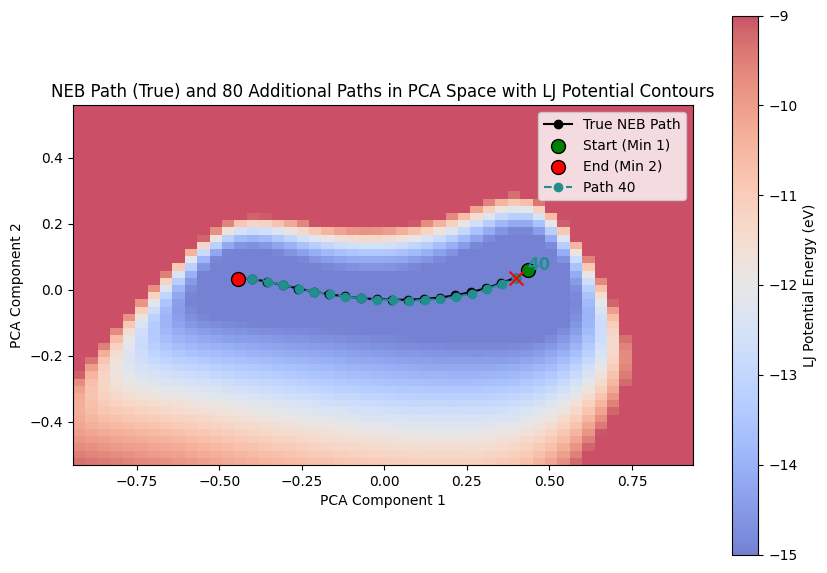

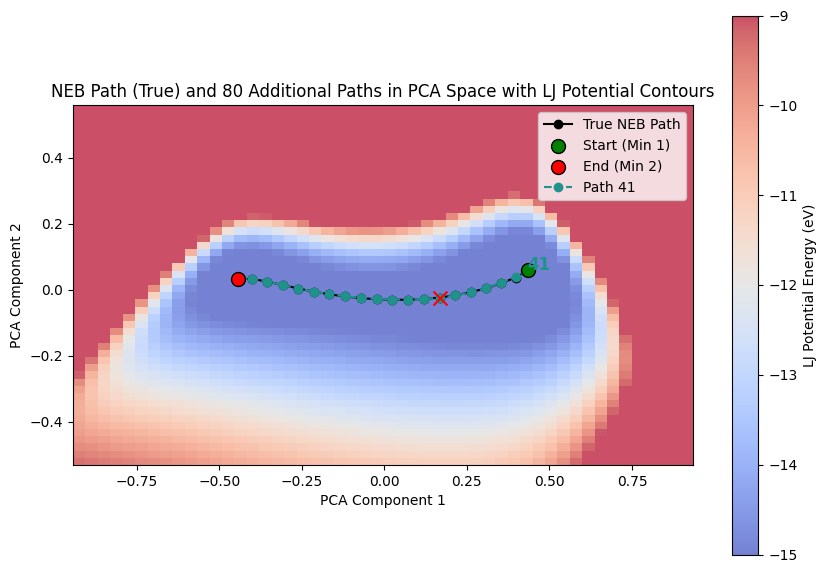

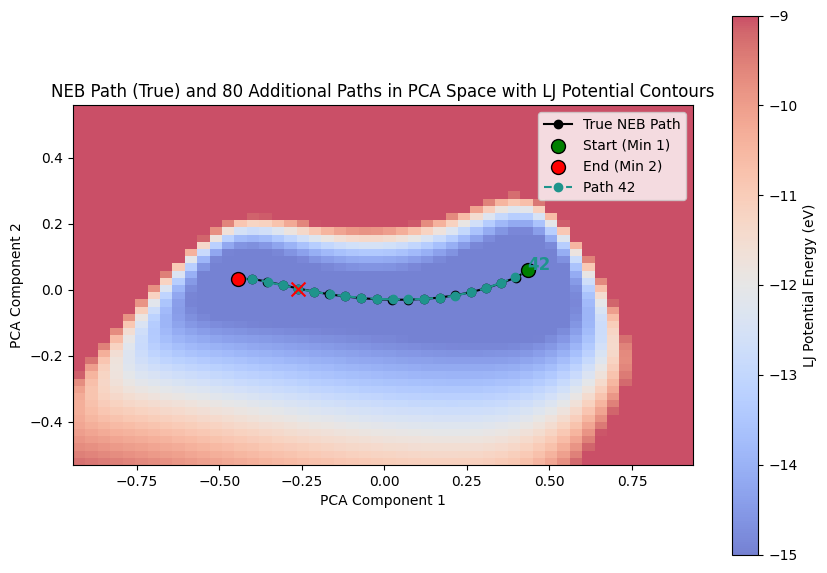

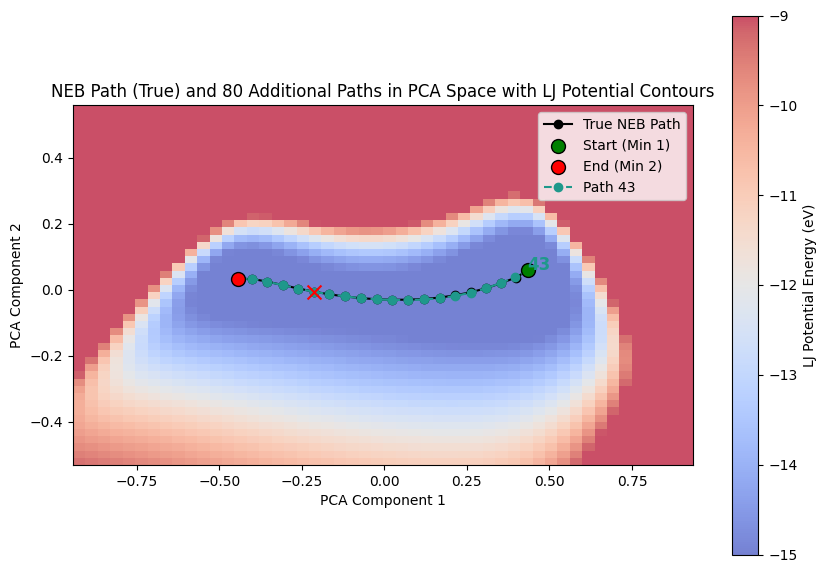

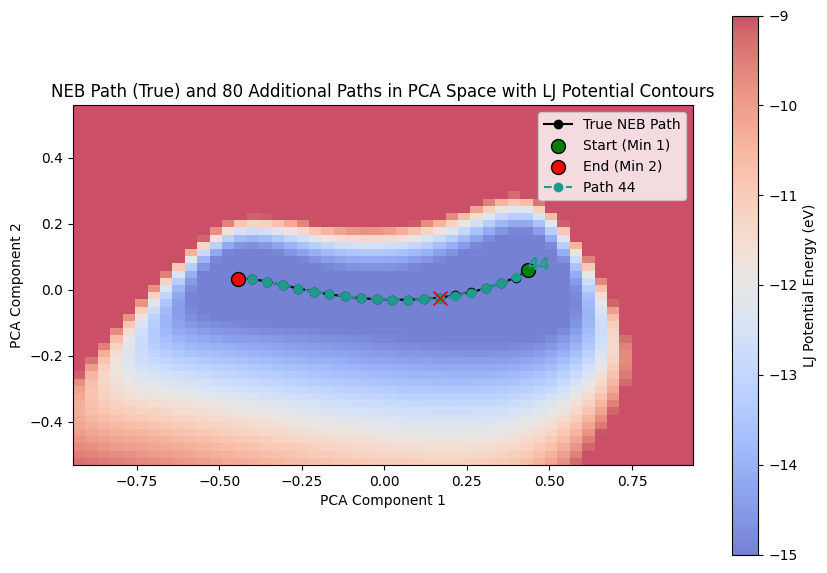

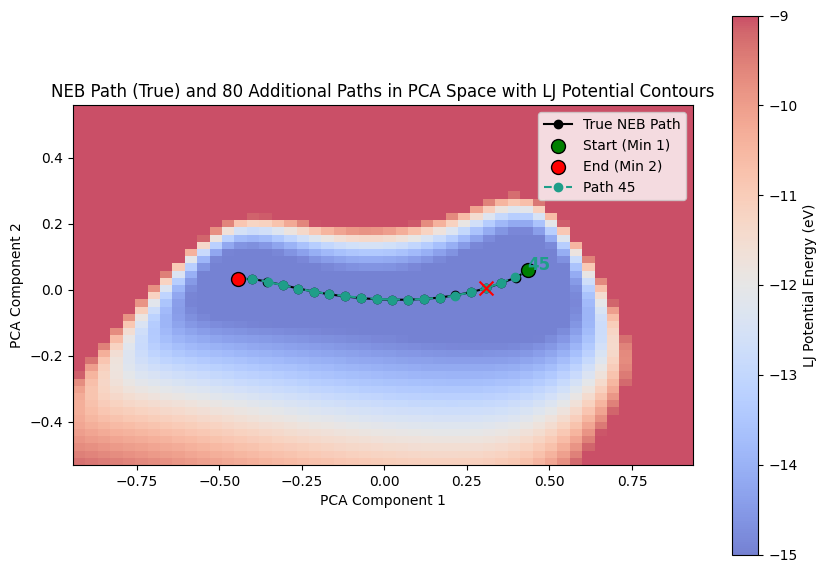

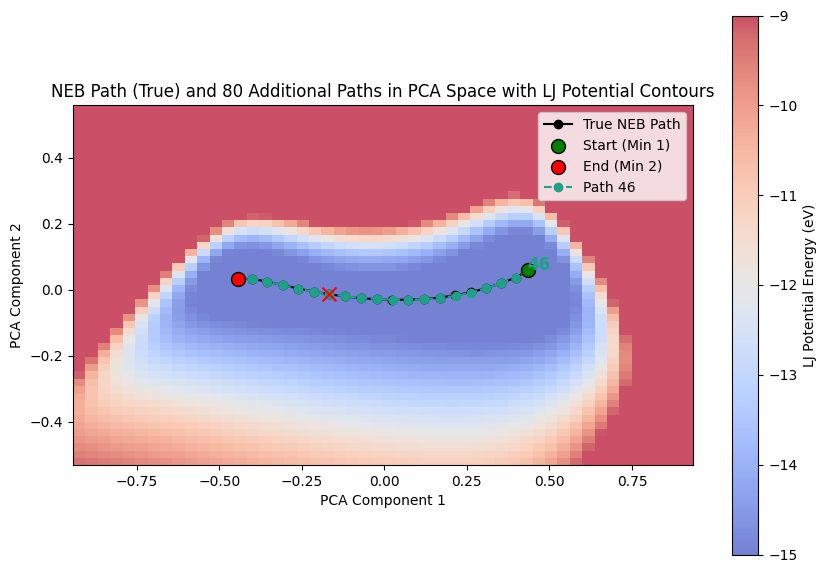

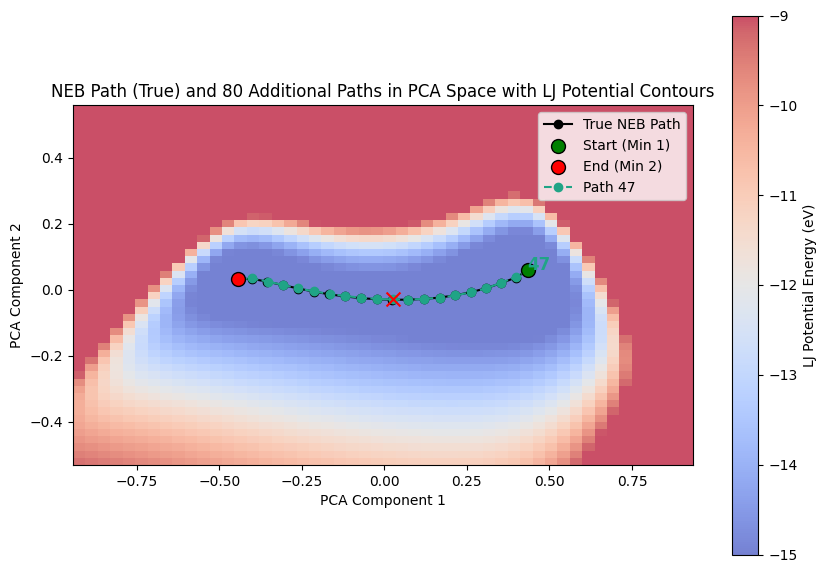

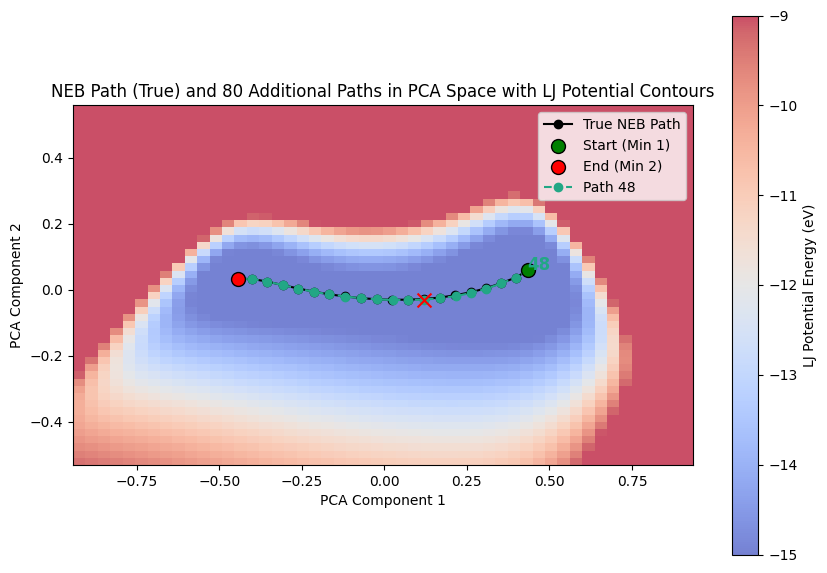

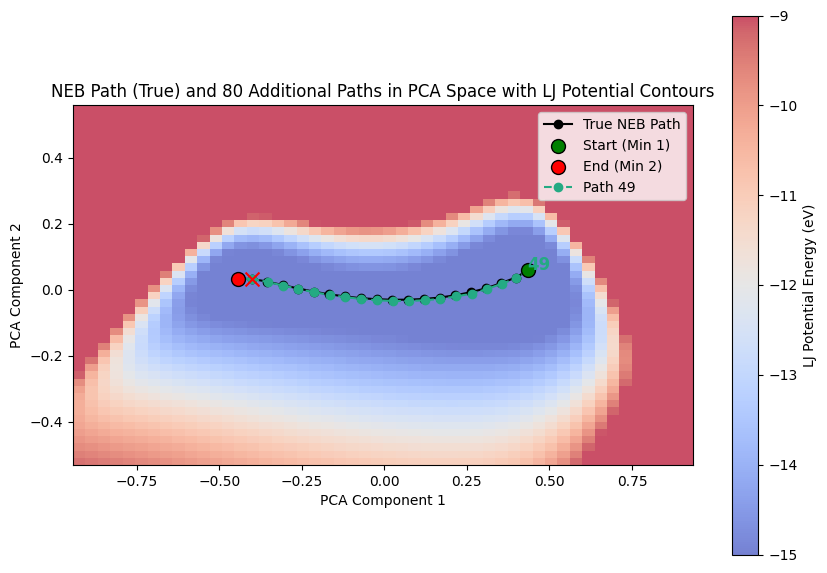

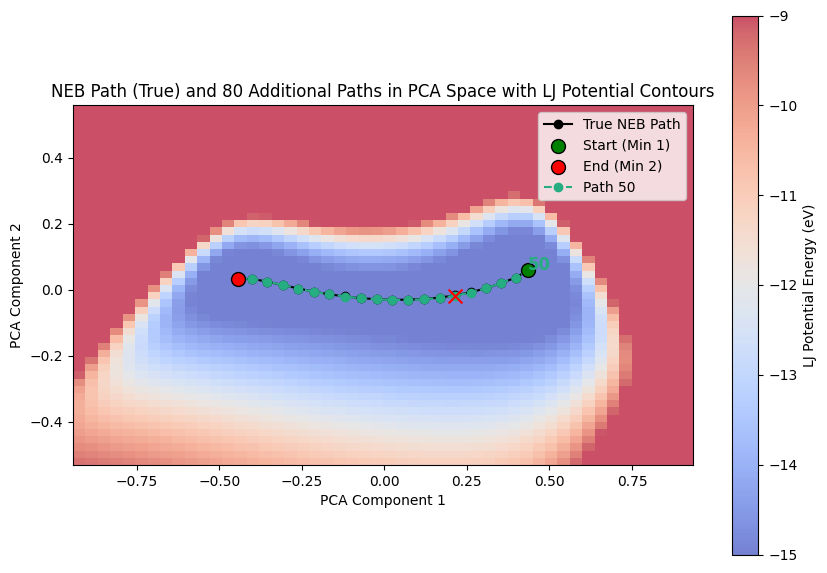

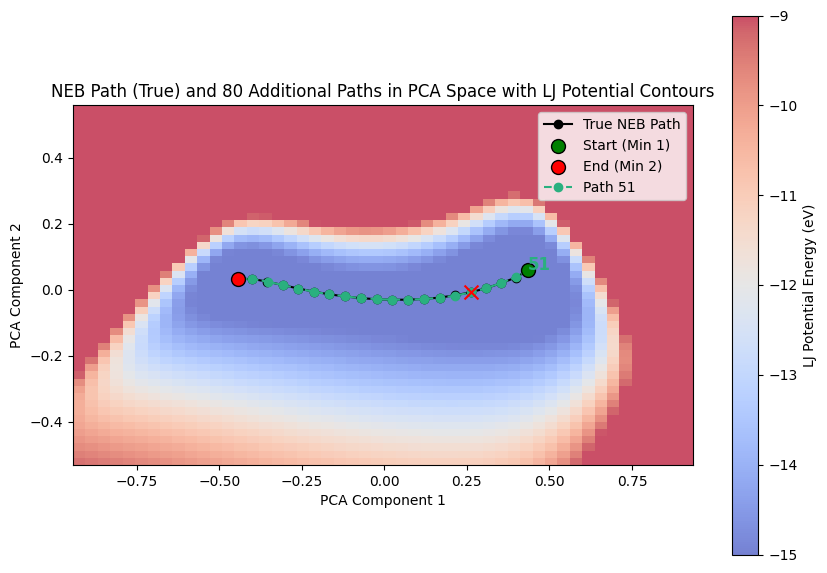

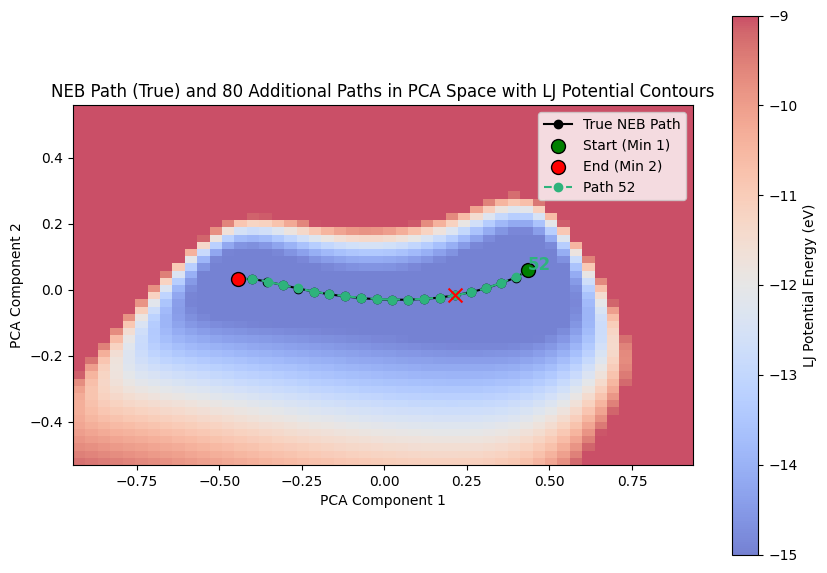

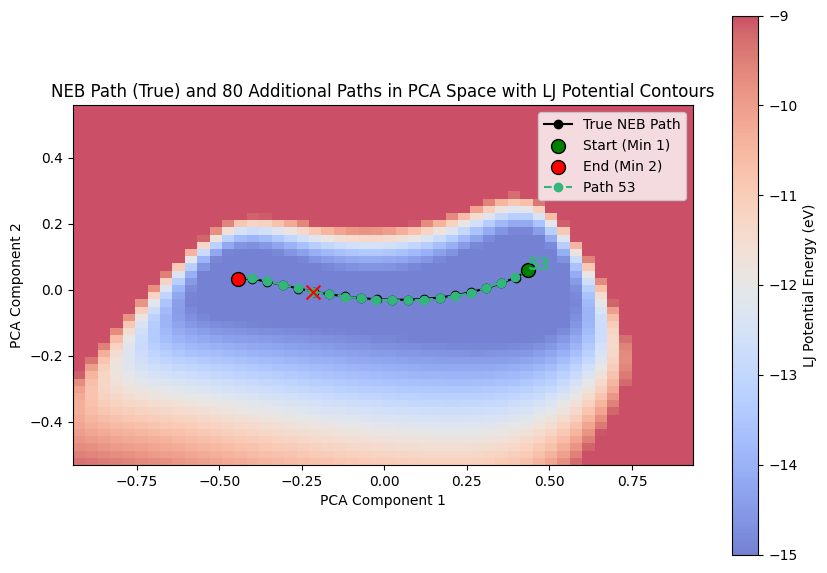

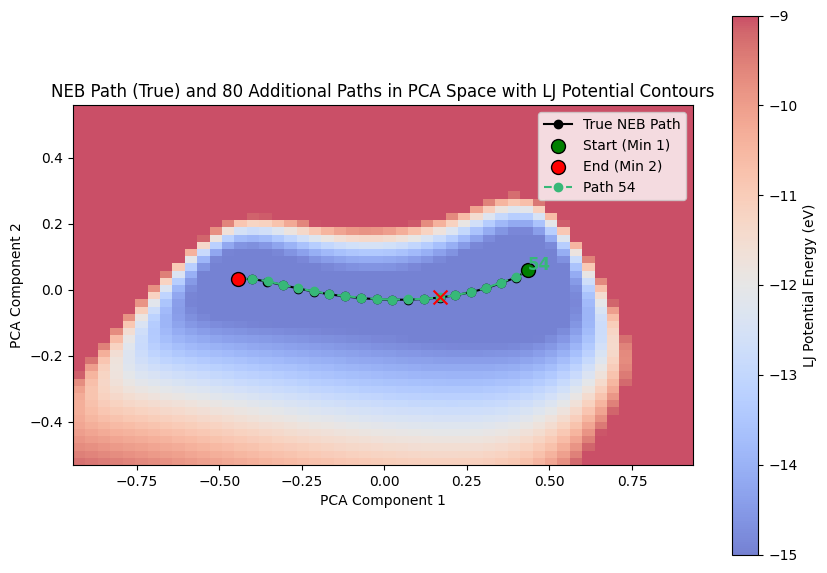

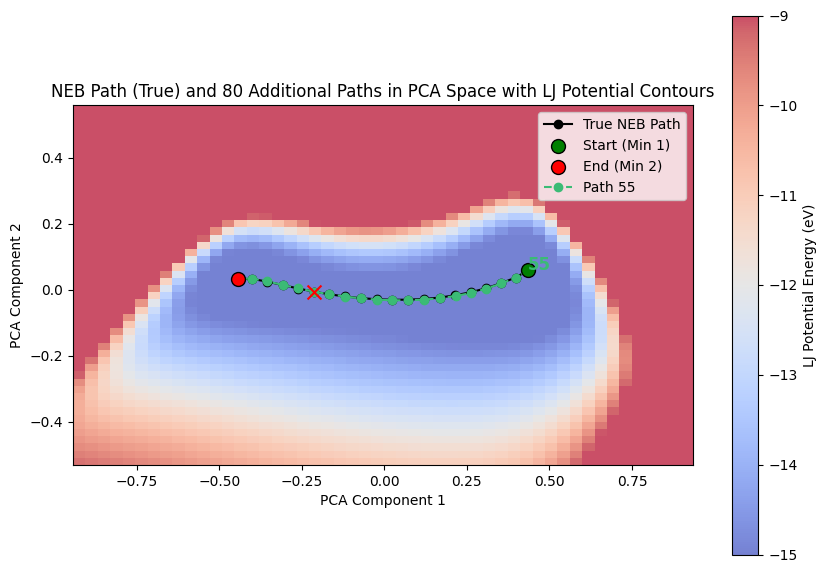

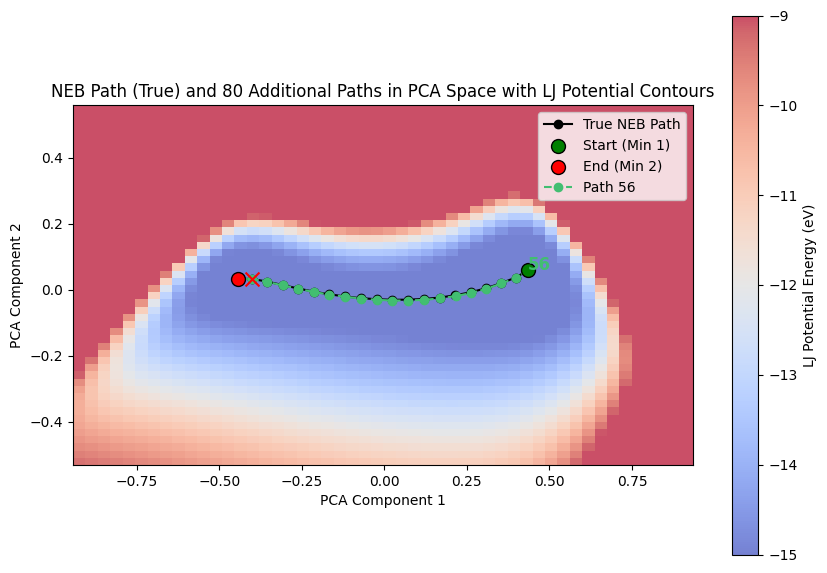

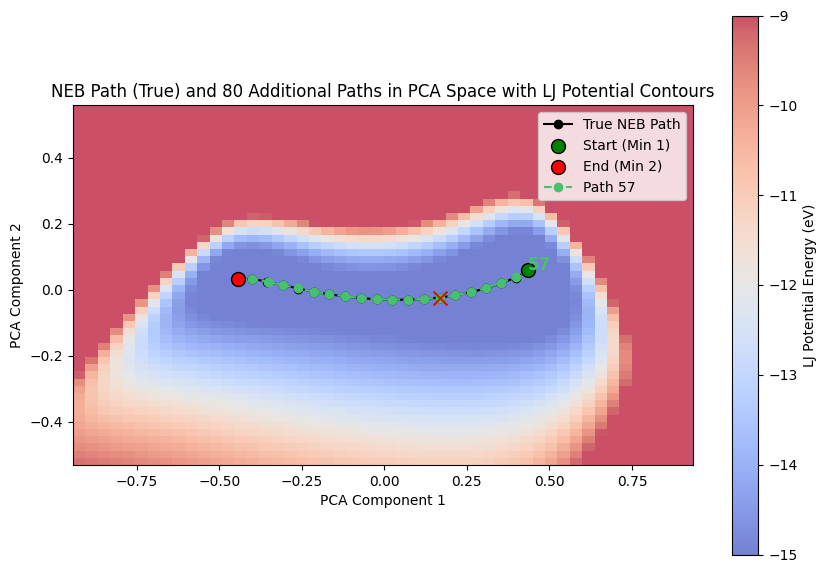

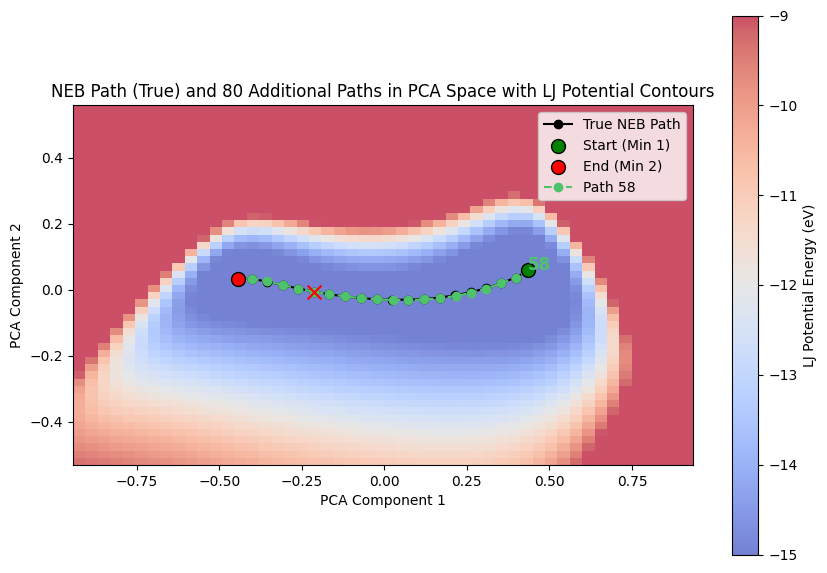

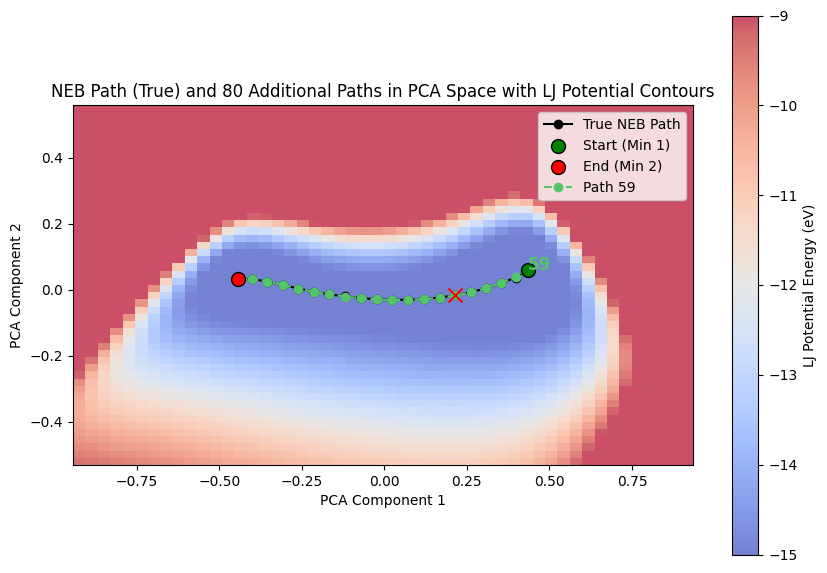

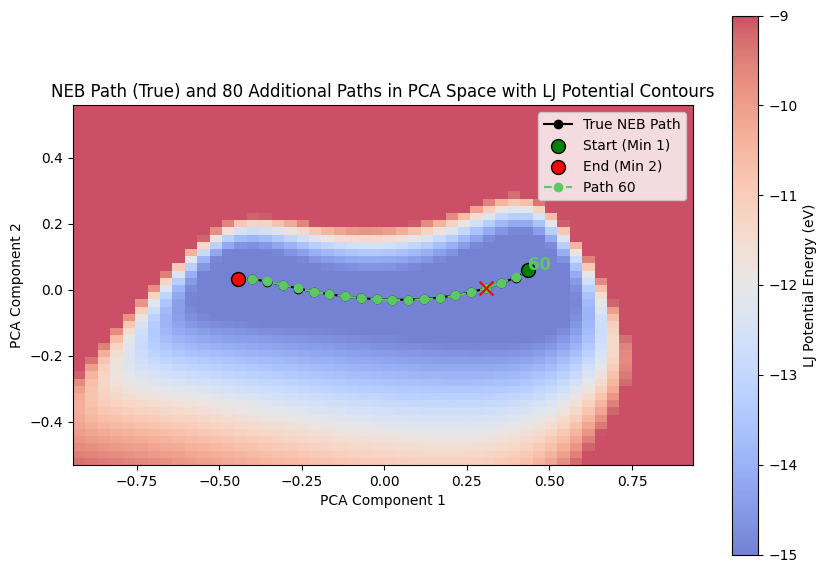

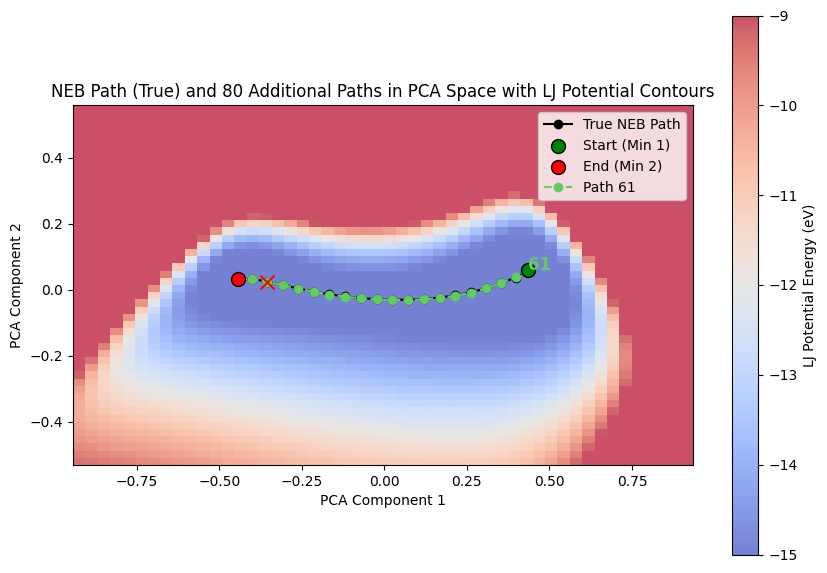

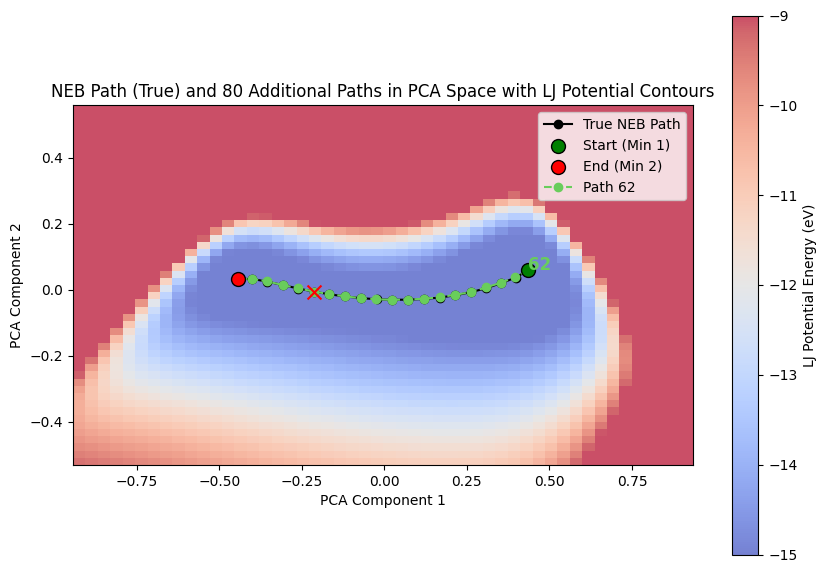

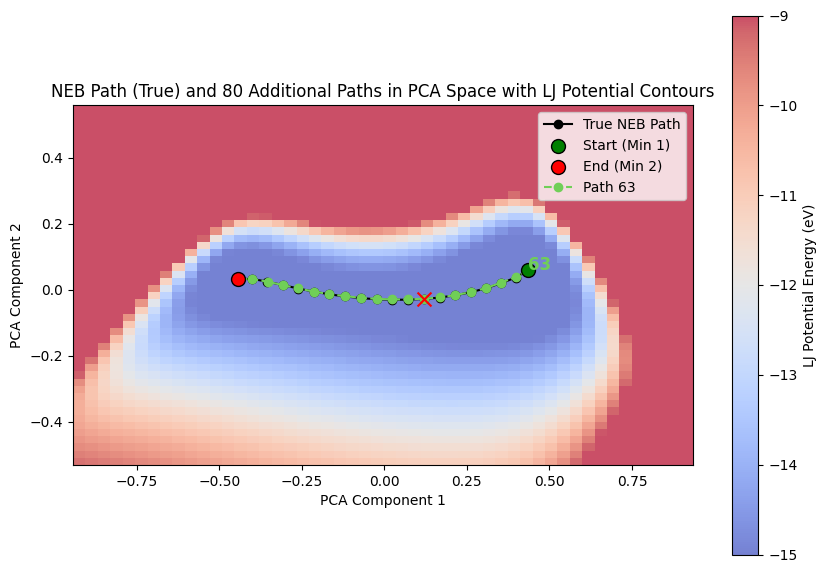

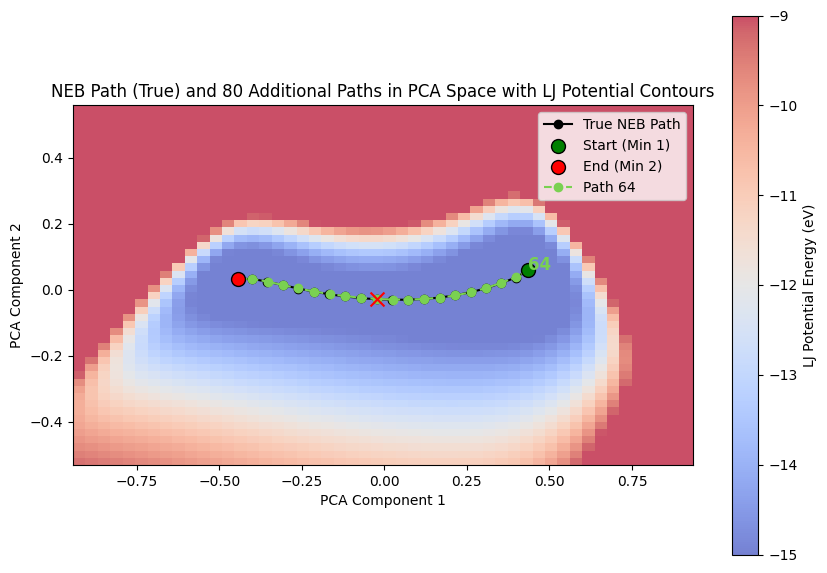

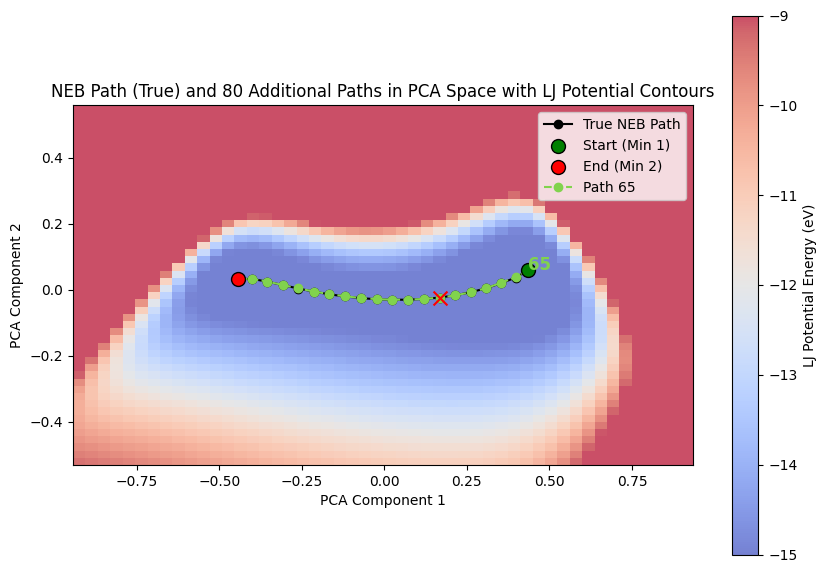

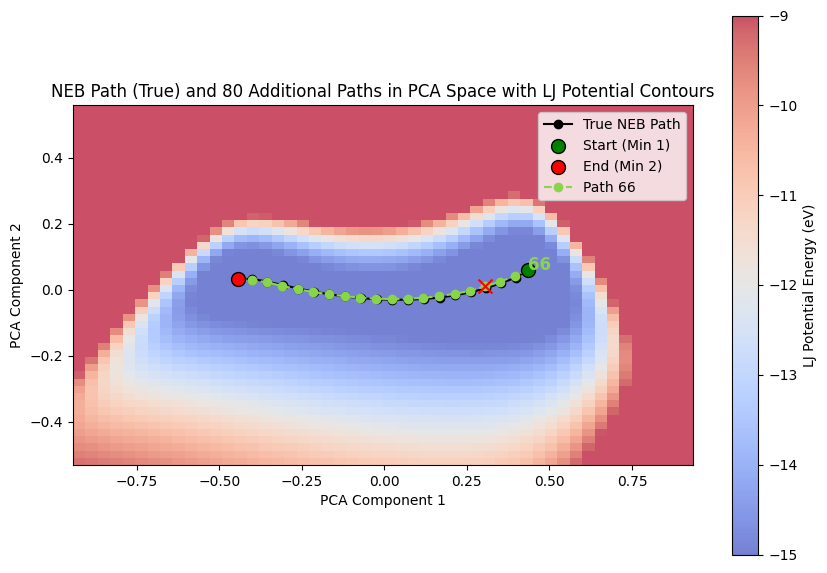

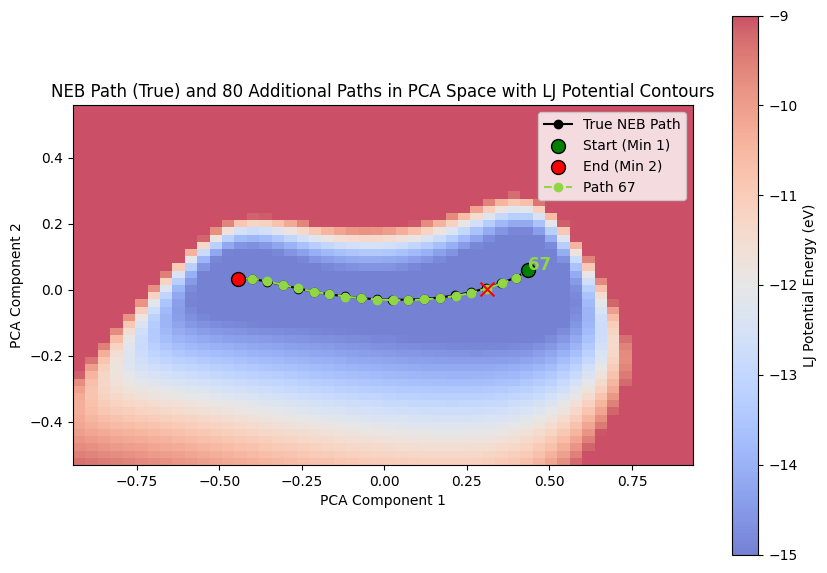

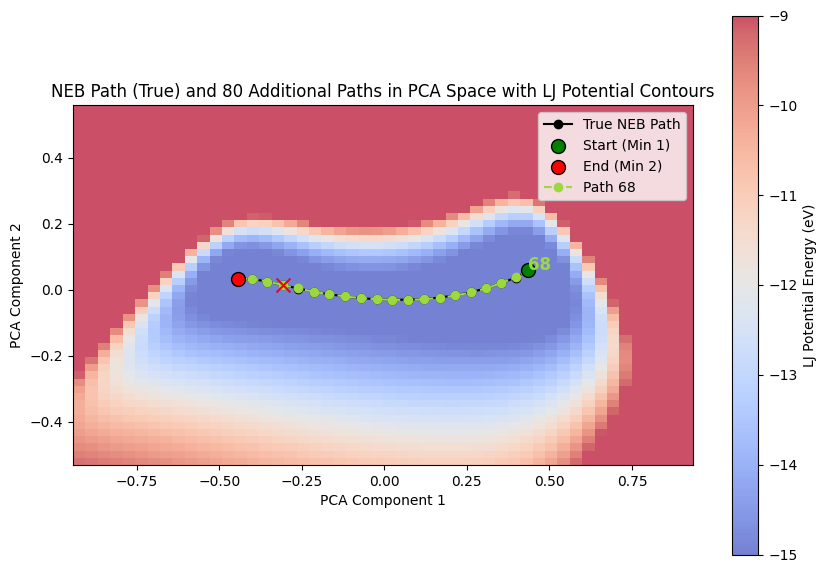

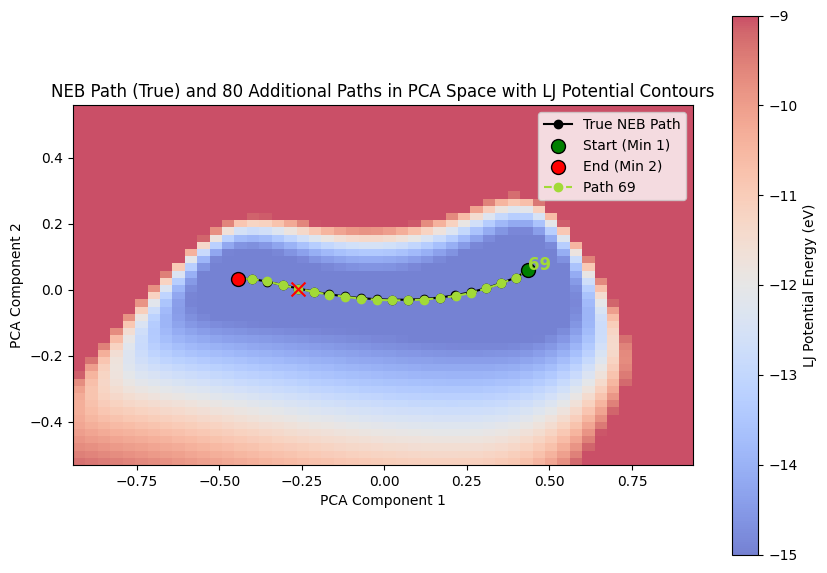

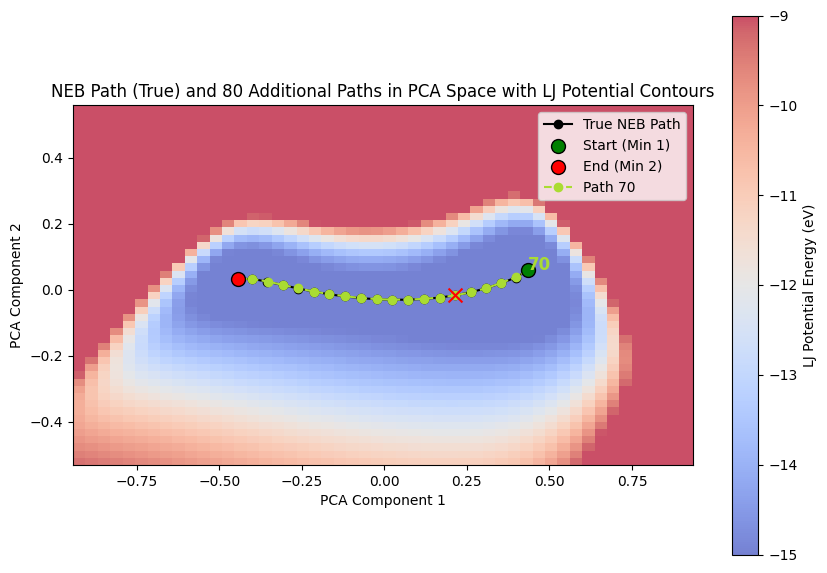

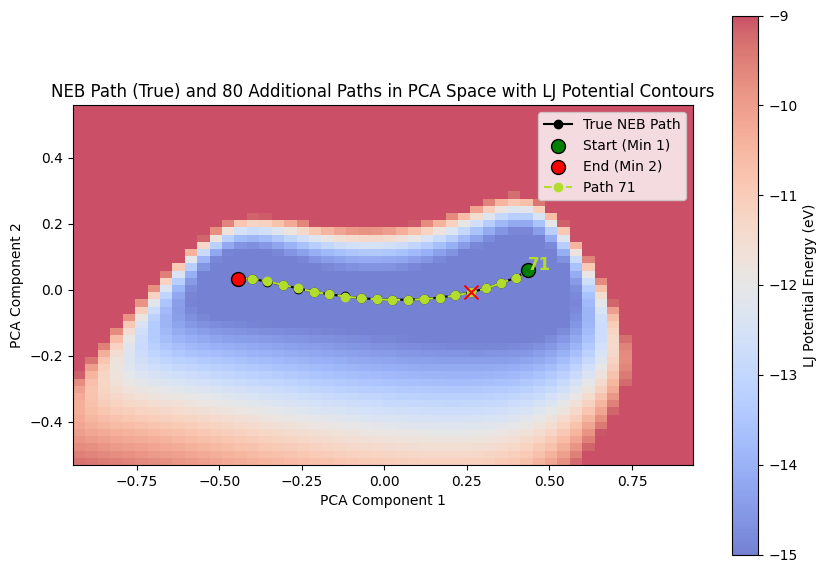

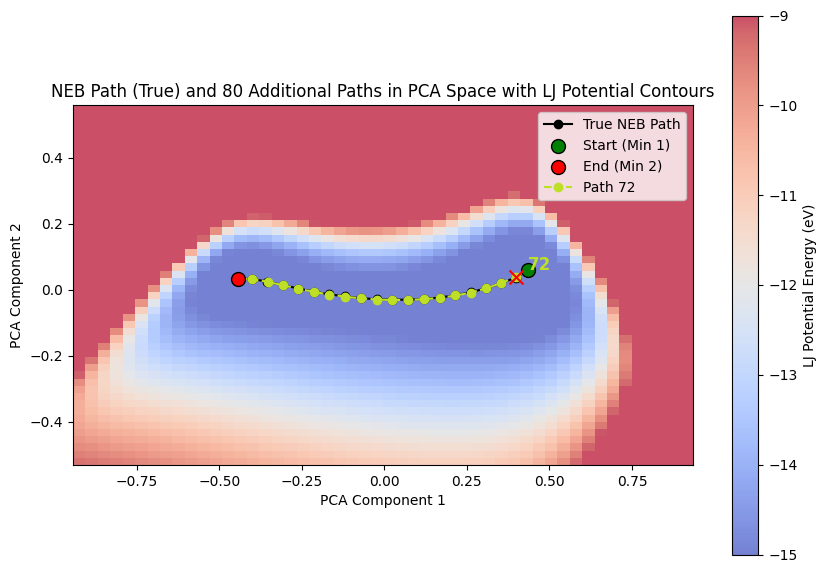

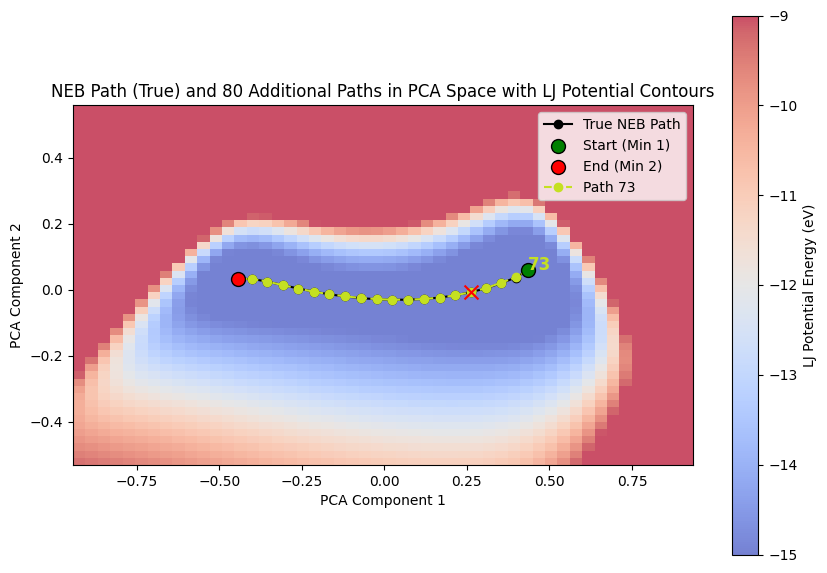

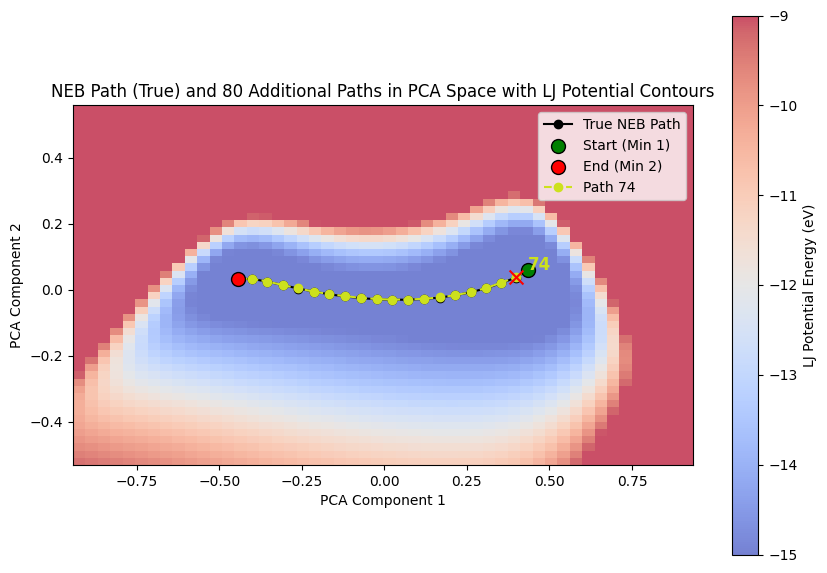

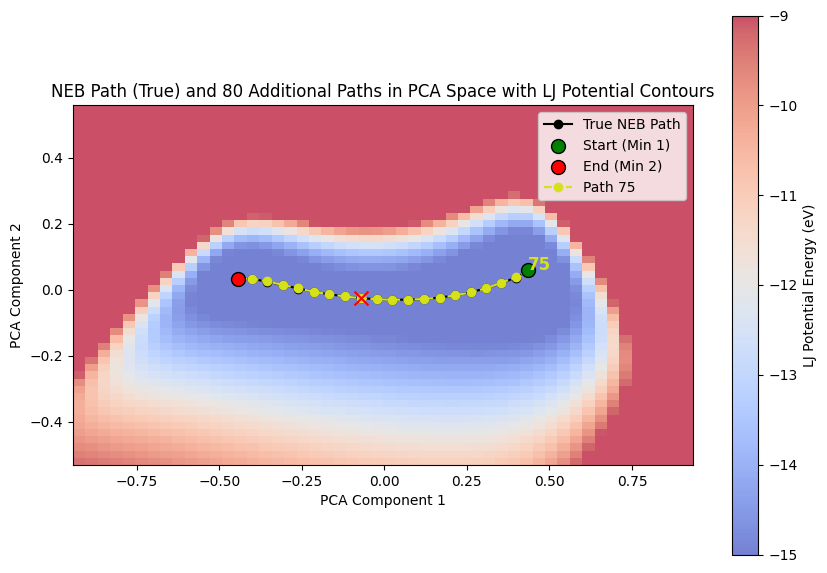

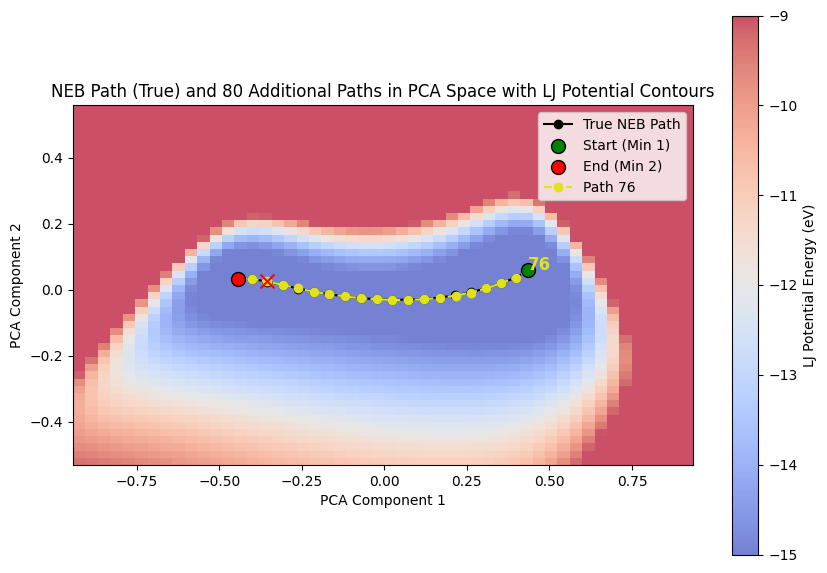

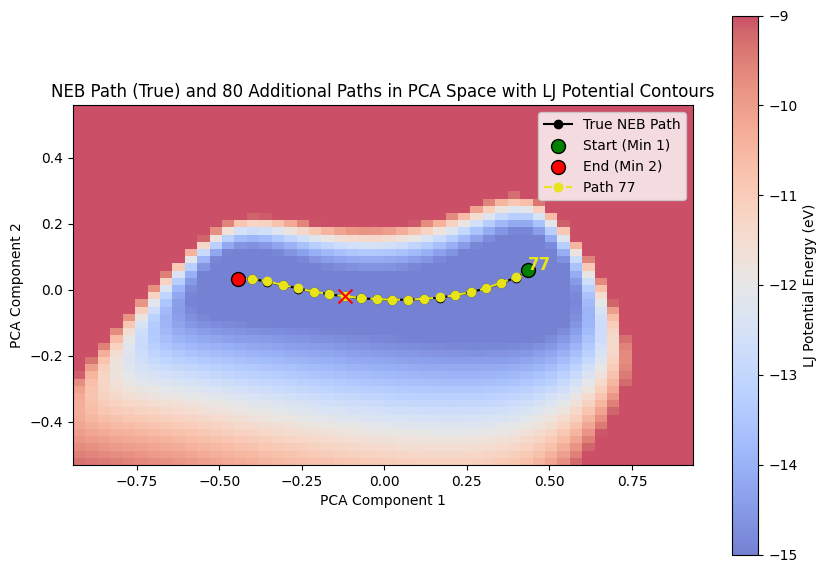

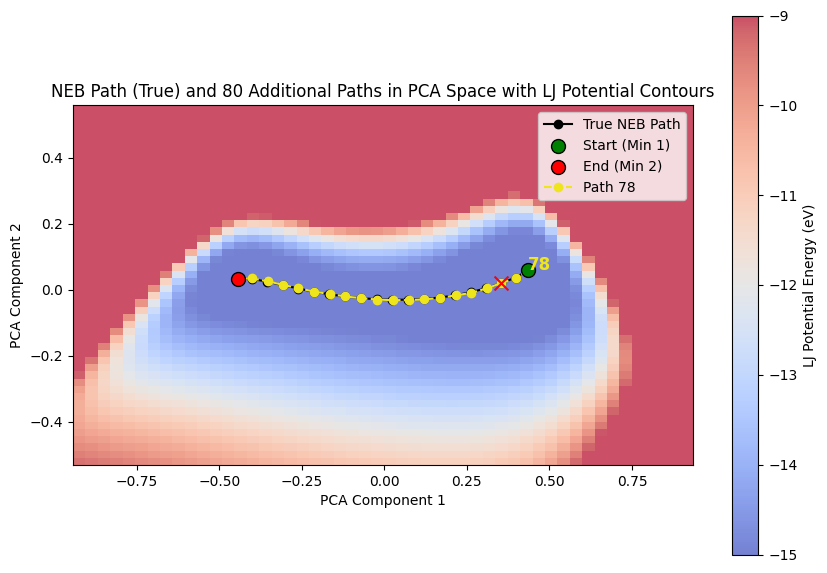

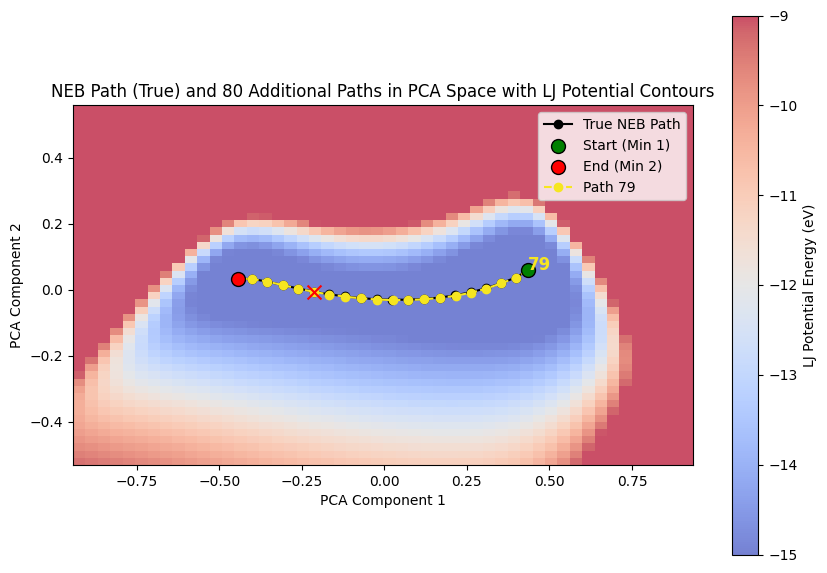

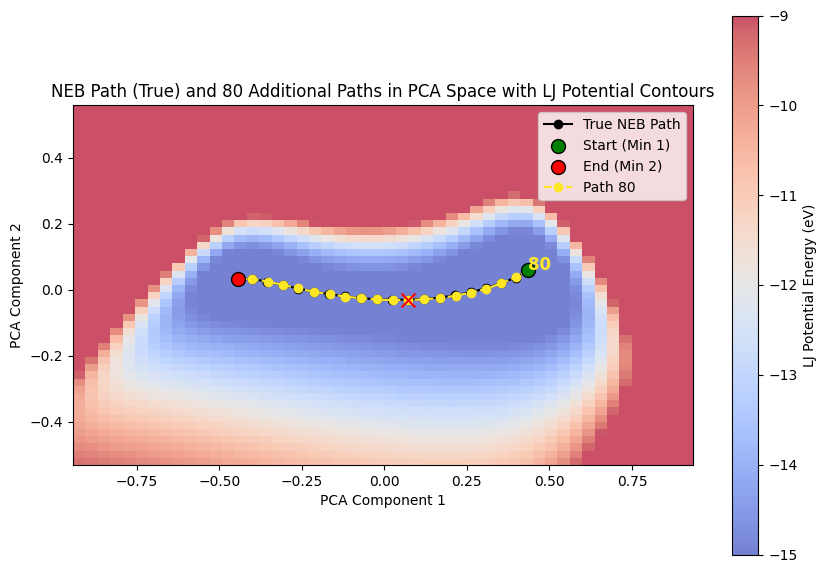

In [16]:
# Create a colormap from a predefined colormap
num_paths = subset_history_numpy.shape[0]
colors = cm.viridis(np.linspace(0, 1, num_paths))  # Smooth gradient from one colormap

# Plot the additional paths using a smooth gradient colormap
for i, (path, color) in enumerate(zip(subset_history_numpy, colors), start=1):
    plt.figure(figsize=(10, 7))
    
    # Plot the LJ energy contour map (background)
    plt.imshow(
        lj_energies,
        cmap="coolwarm",
        alpha=0.7,
     vmin=-15,
    vmax=-9,
        extent=(x_min, x_max, y_min, y_max),
        origin="lower"
    )
    plt.colorbar(label="LJ Potential Energy (eV)")
    
    # Plot the true NEB path in black solid line with markers
    plt.plot(pca_x, pca_y, marker='o', linestyle='-', color="black", label="True NEB Path")
    plt.scatter(pca_x[0], pca_y[0], color="green", s=100, label="Start (Min 1)", edgecolors="black", zorder=3)
    plt.scatter(pca_x[-1], pca_y[-1], color="red", s=100, label="End (Min 2)", edgecolors="black", zorder=3)
    
    # Plot the BAX path in dashed line
    path_pca = pca.transform(path)  # Transform the path to PCA space
    plt.plot(path_pca[:, 0], path_pca[:, 1], marker='o', linestyle='--', 
             label=f"Path {i}", color=color)
    plt.text(path_pca[0, 0], path_pca[0, 1], f"{i}", fontsize=12,
             fontweight='bold', color=color, zorder=4)
    
     # --- New code: Mark the sampled point with a red X ---
    # We skip the first two entries in acquired_data_list.
    # For iteration i, we use the element at index i+1.
    sampled_idx = i-1  # i=1 --> index 2, i=15 --> index 16.
    # From the first element of the tuple/list, take the first 21 numbers as the object's position.
    sampled_point = np.array(acquired_data_list[sampled_idx])
    # Transform the sampled point into PCA space.
    sampled_point_pca = pca.transform(sampled_point.reshape(1, -1))
    # Only add the legend label on the first iteration to avoid duplicates.
    label = "Sampled Point" if i == 1 else None
    plt.scatter(sampled_point_pca[0, 0], sampled_point_pca[0, 1], marker='x', color='red',
                s=100, label=label, zorder=5)
   
 
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(f"NEB Path (True) and {num_paths} Additional Paths in PCA Space with LJ Potential Contours")
    plt.legend()
    plt.show()


# Energy Barrier Analysis

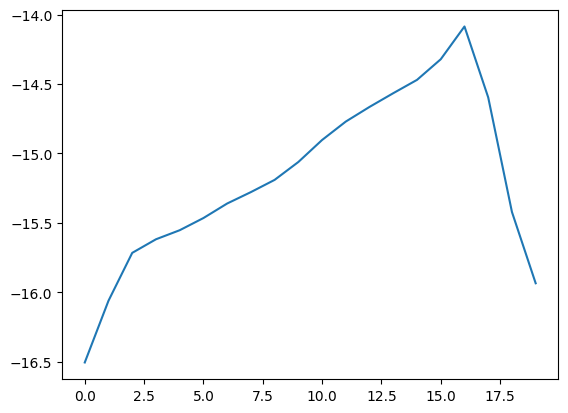

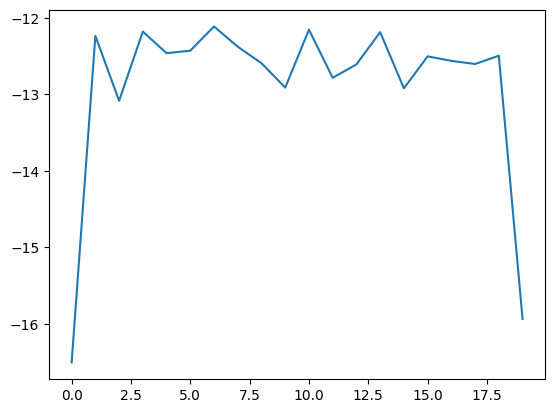

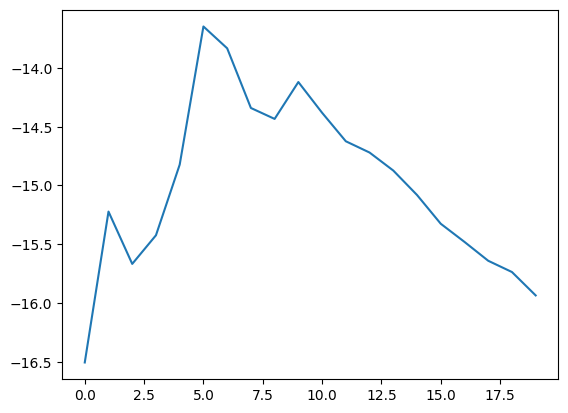

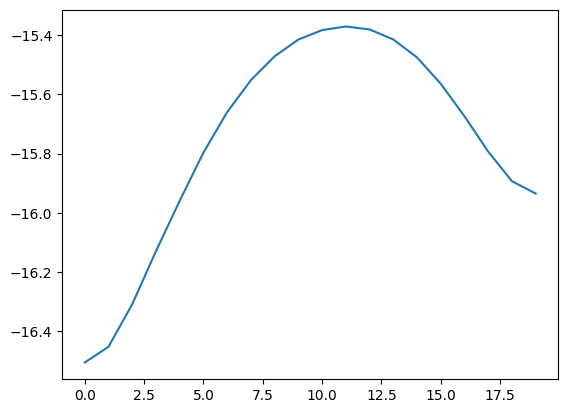

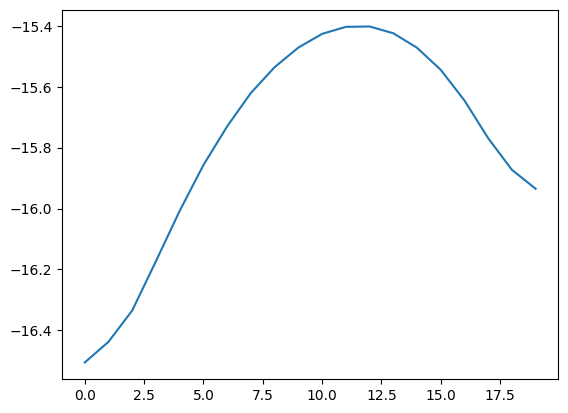

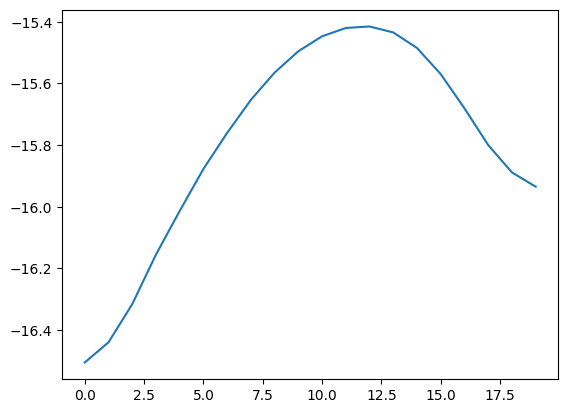

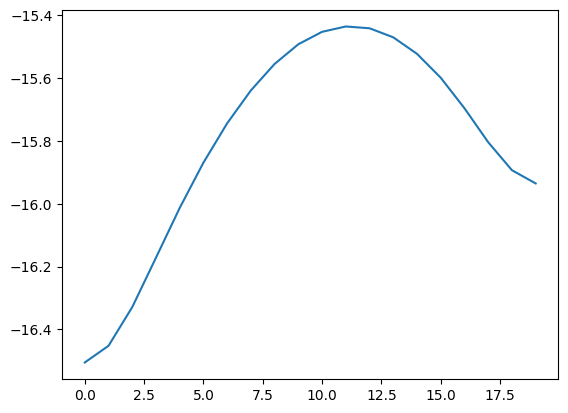

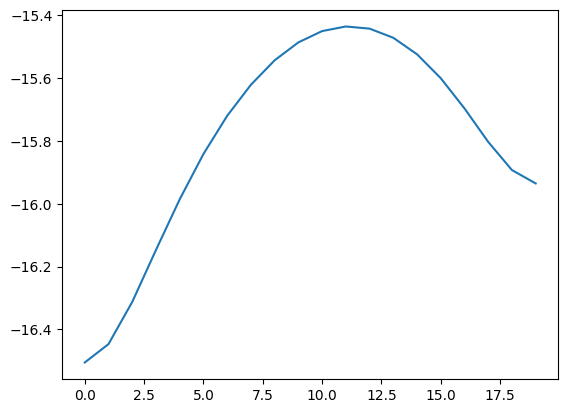

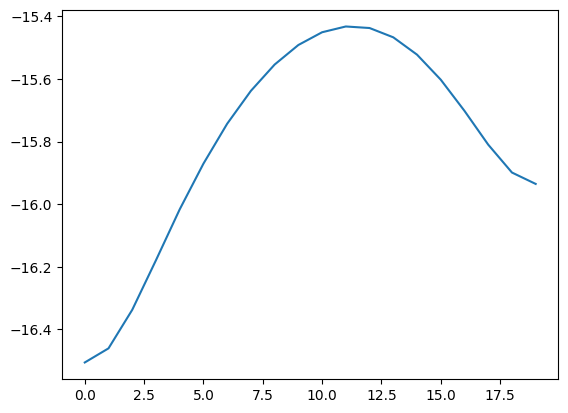

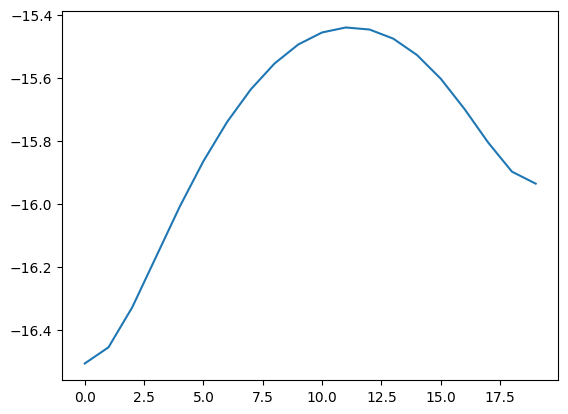

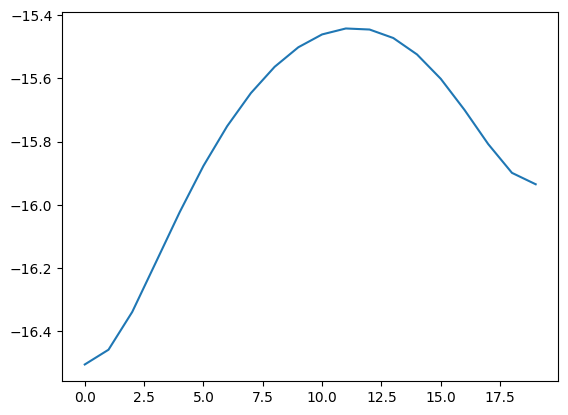

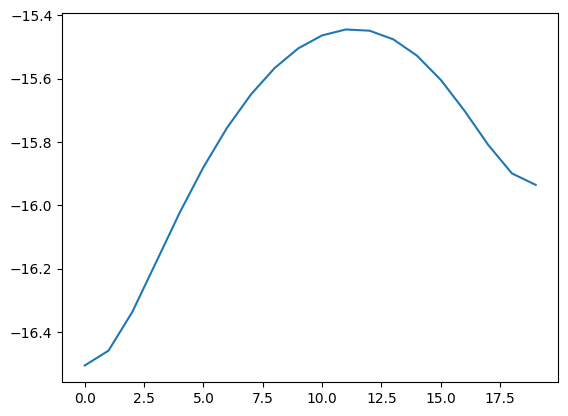

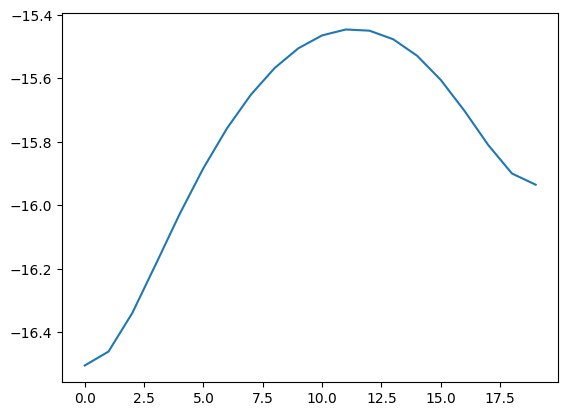

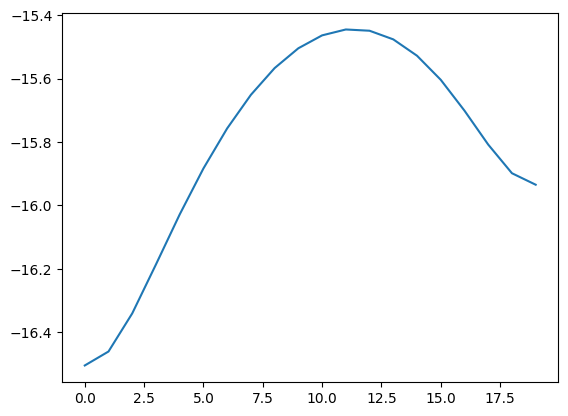

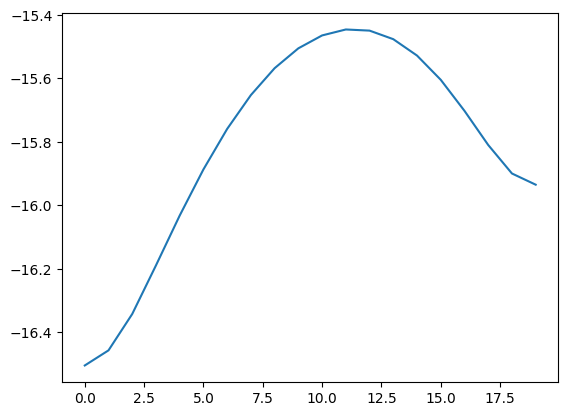

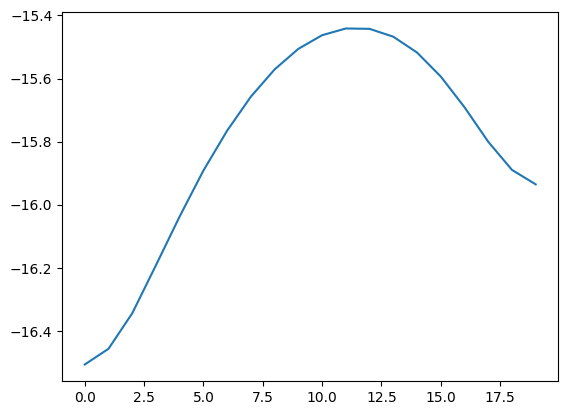

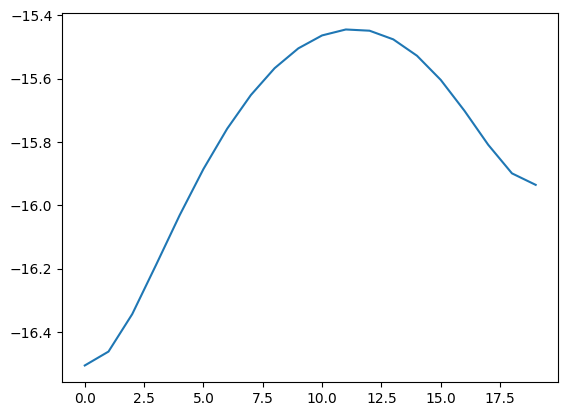

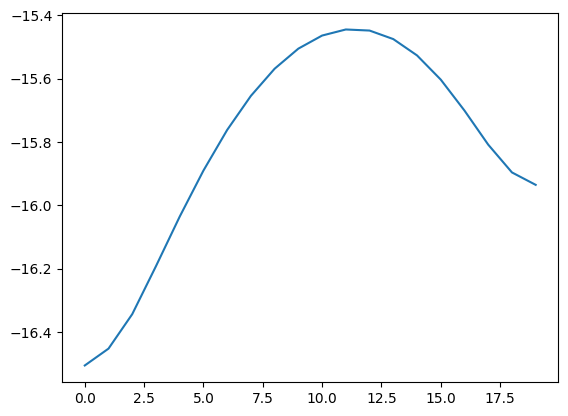

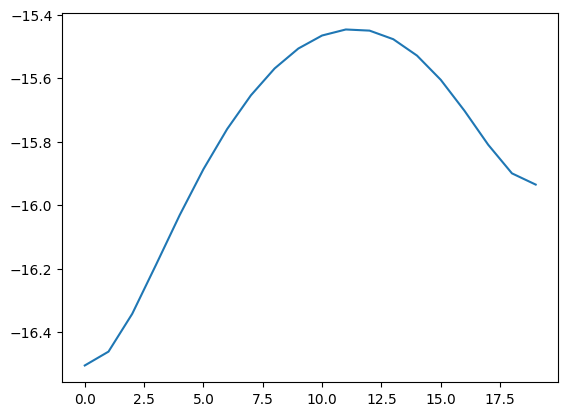

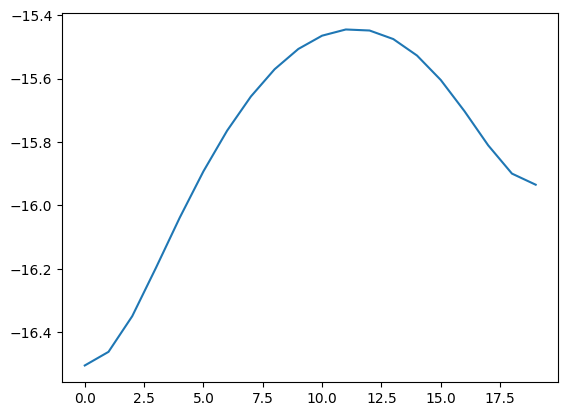

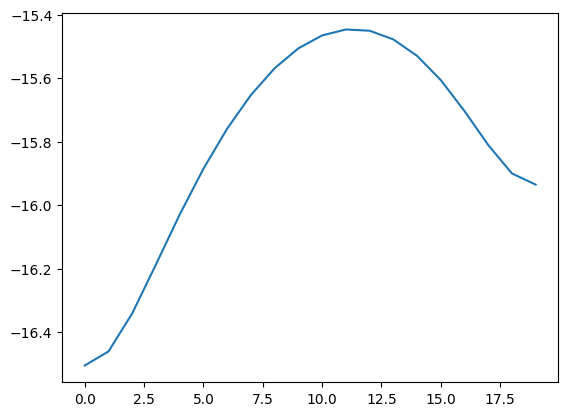

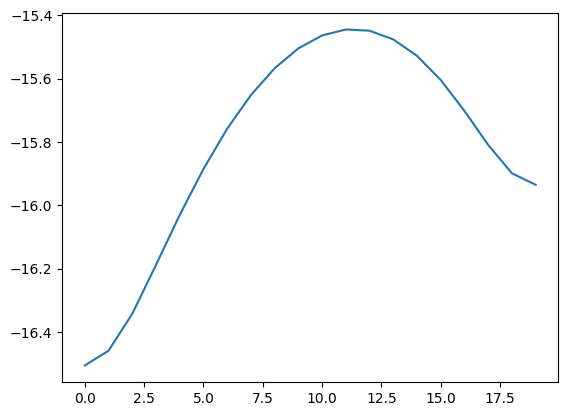

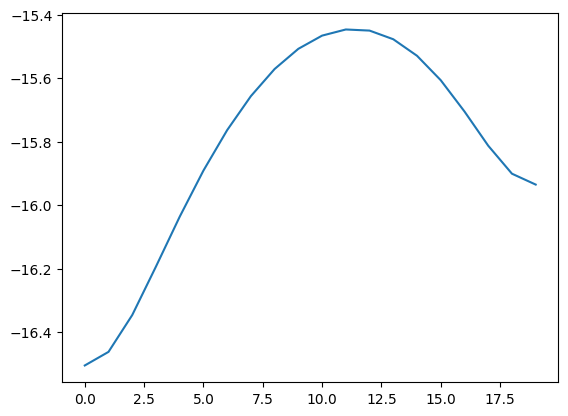

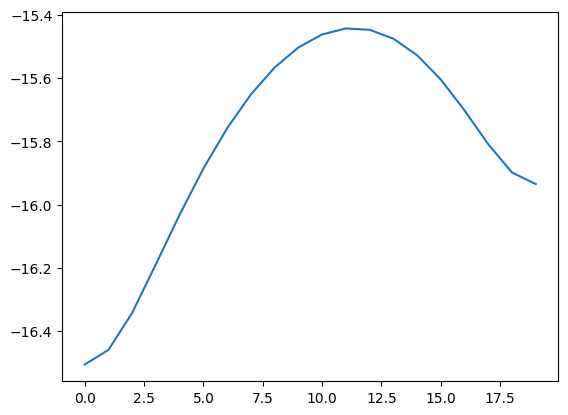

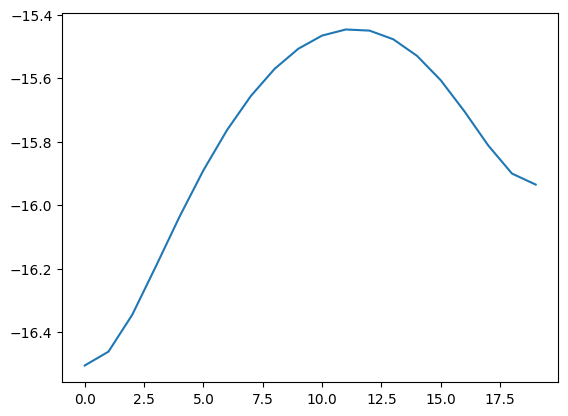

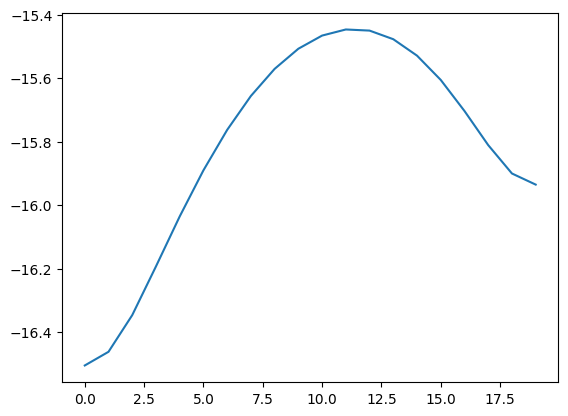

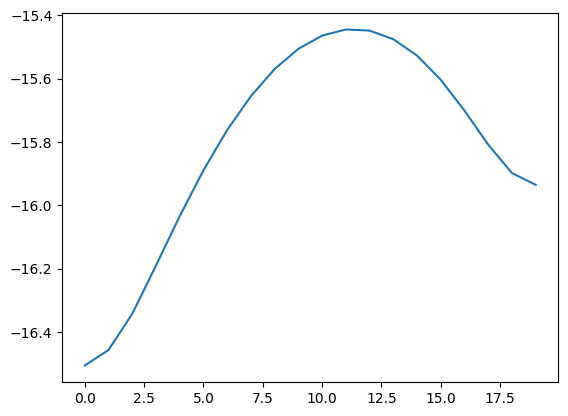

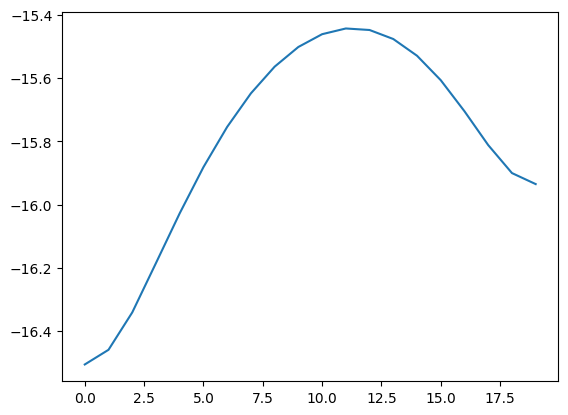

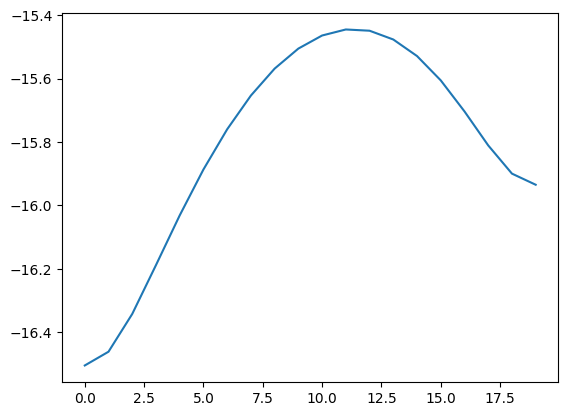

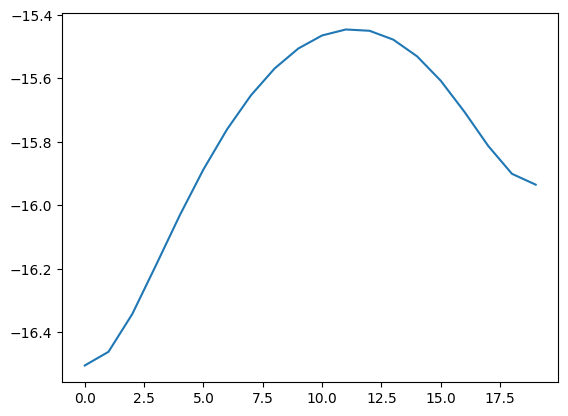

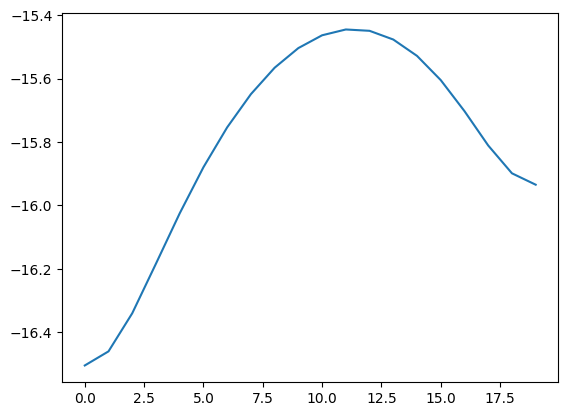

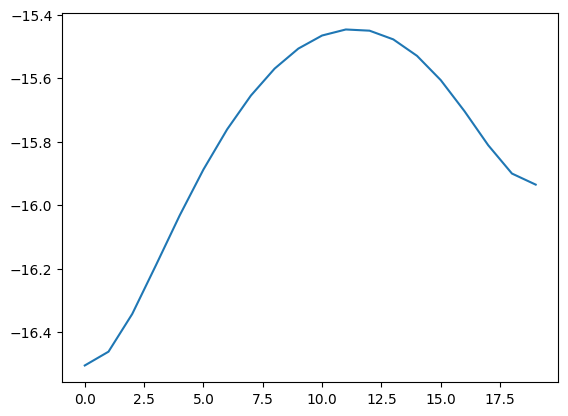

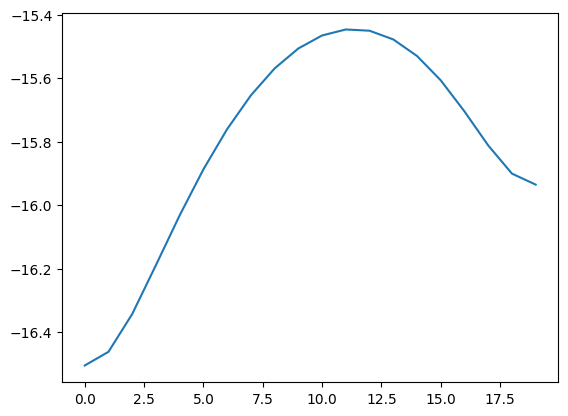

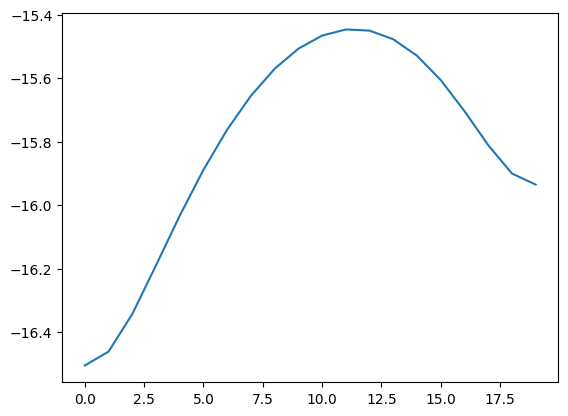

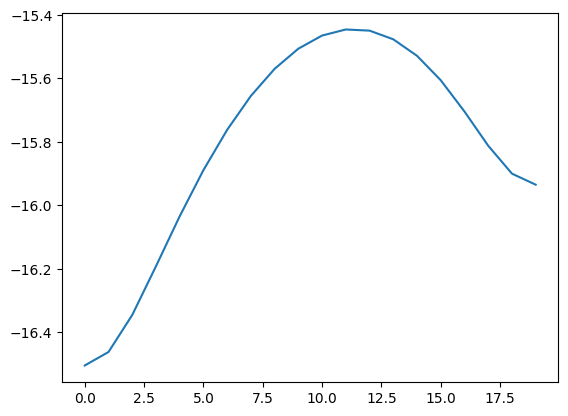

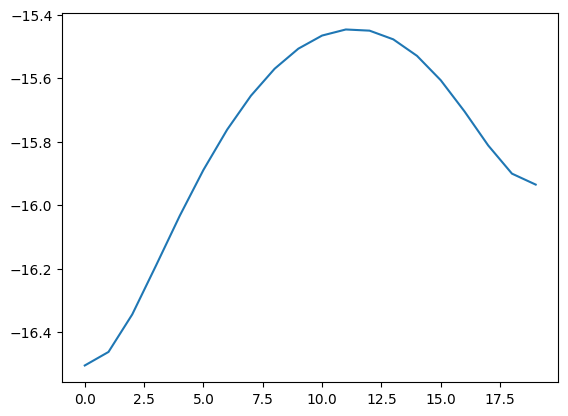

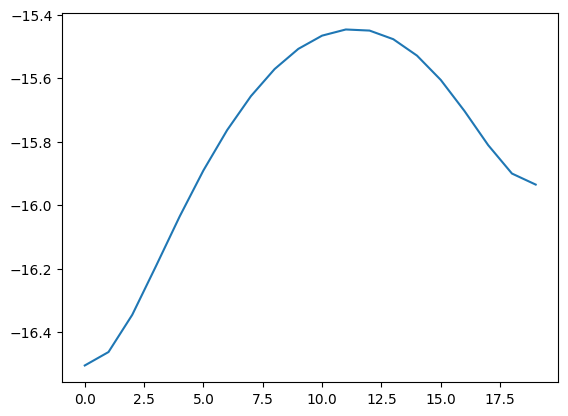

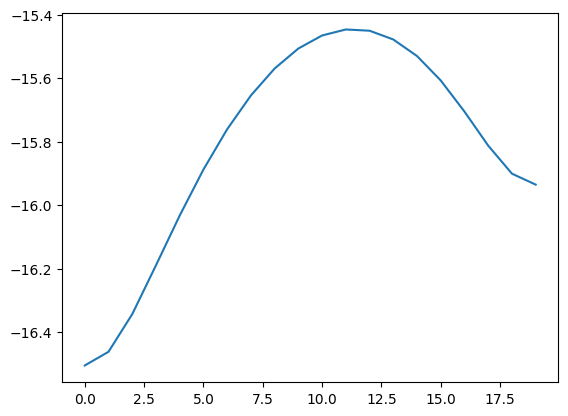

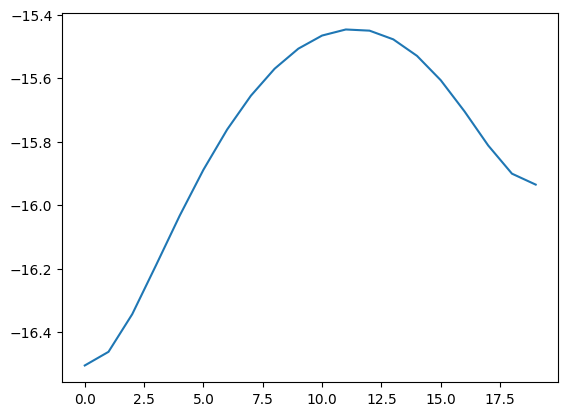

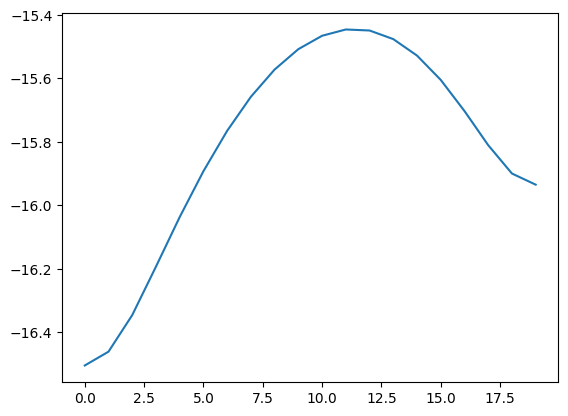

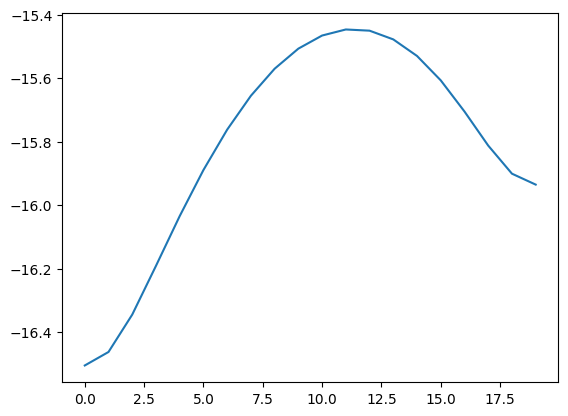

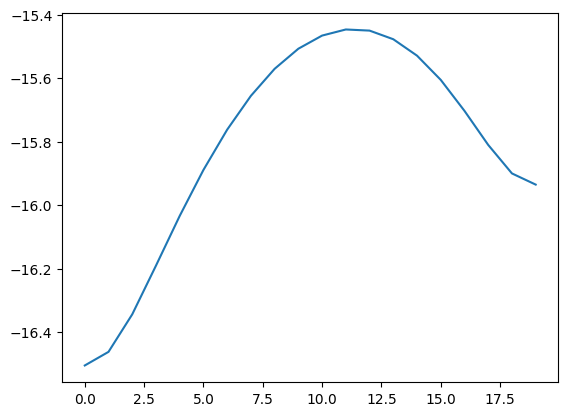

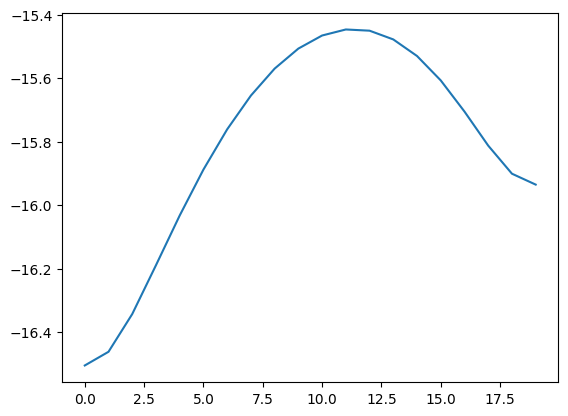

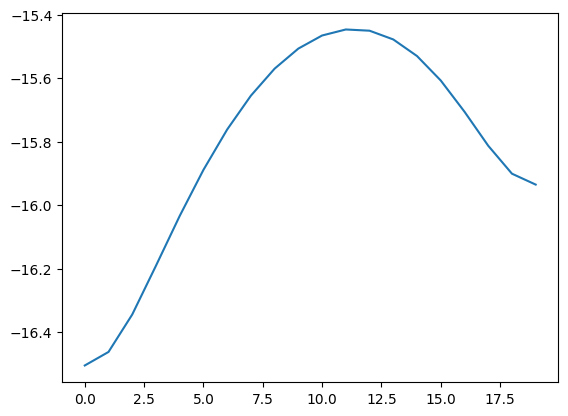

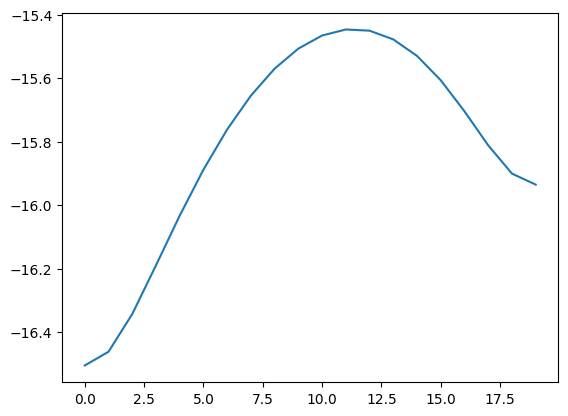

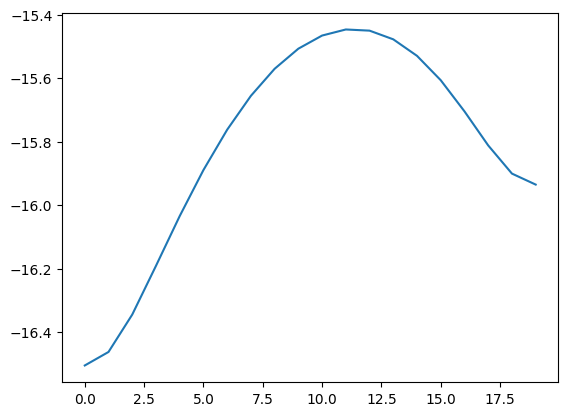

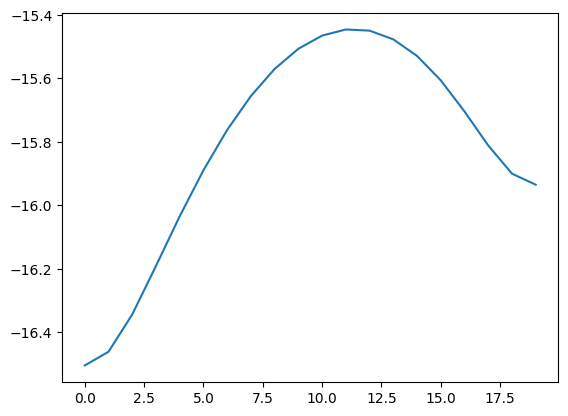

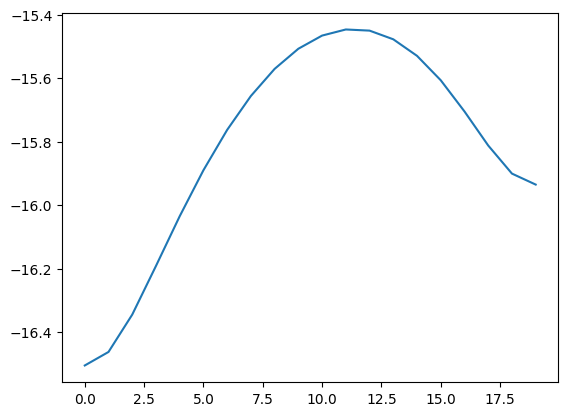

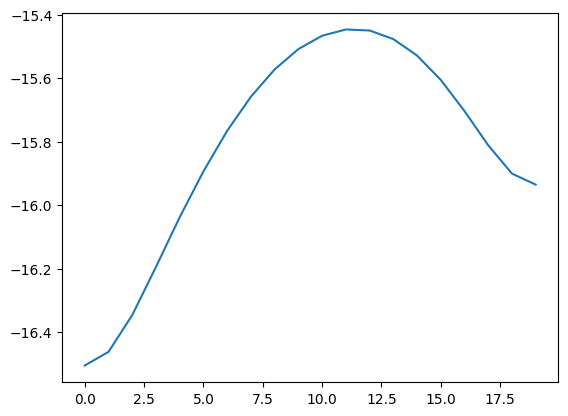

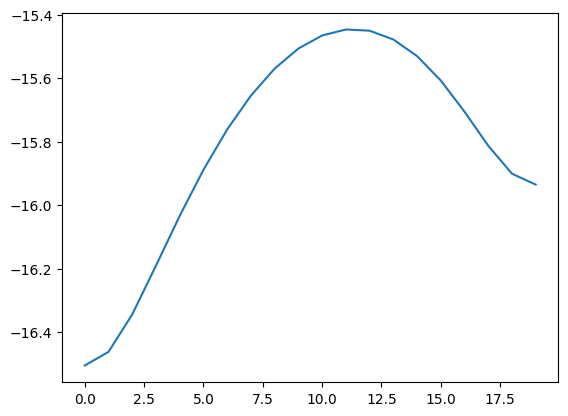

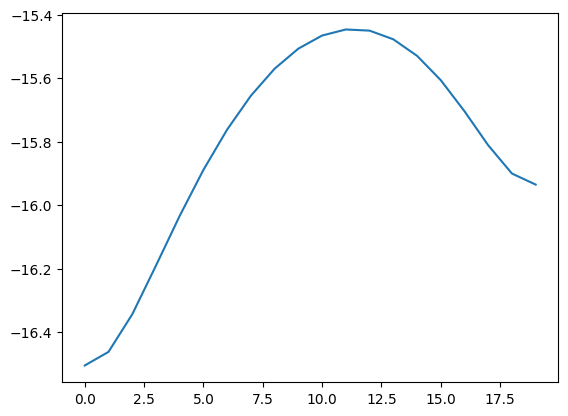

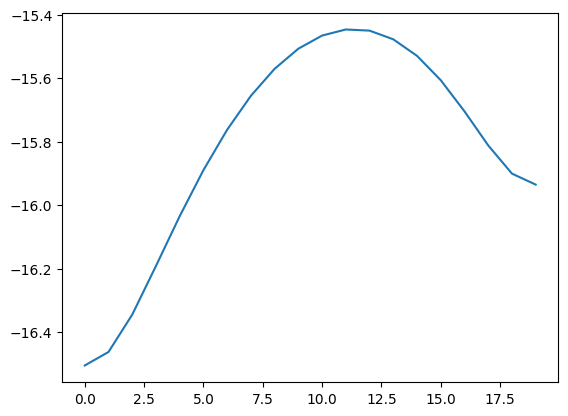

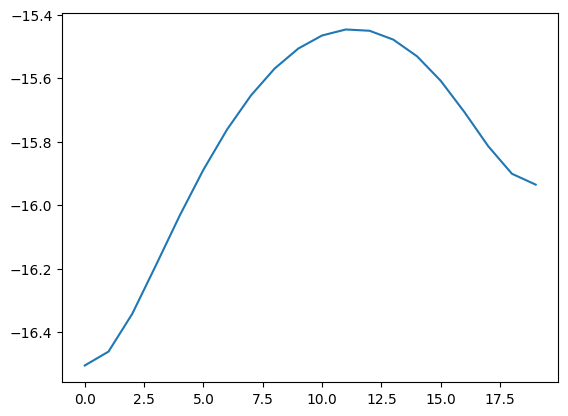

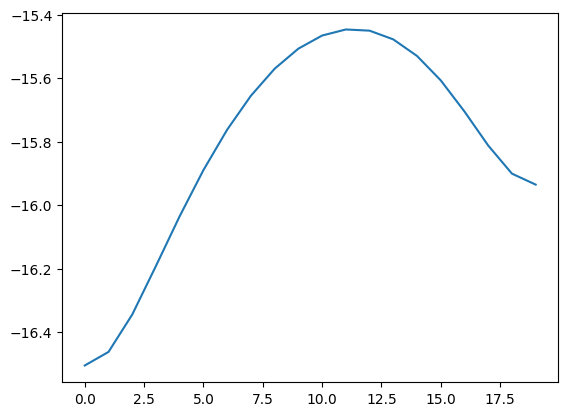

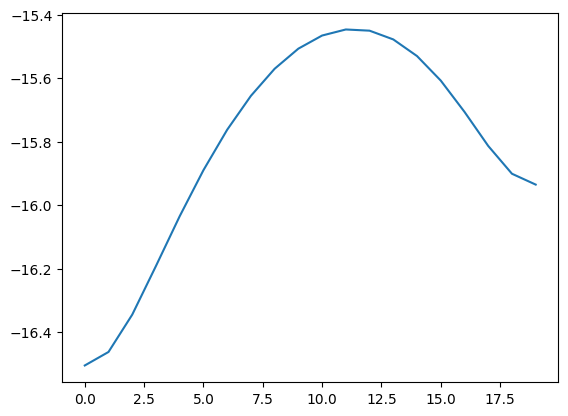

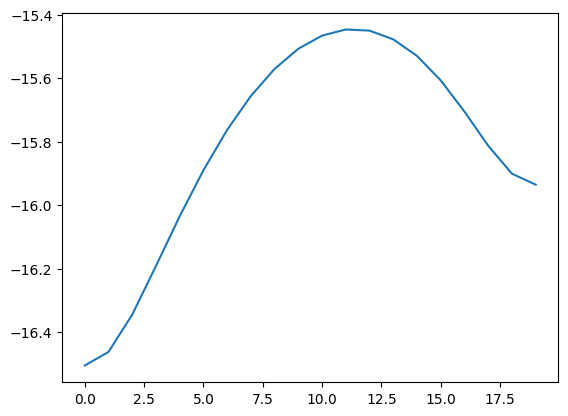

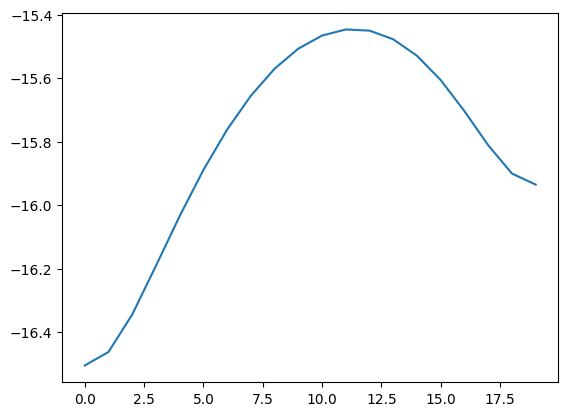

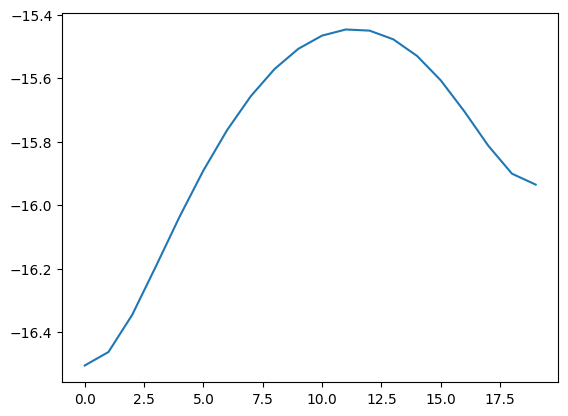

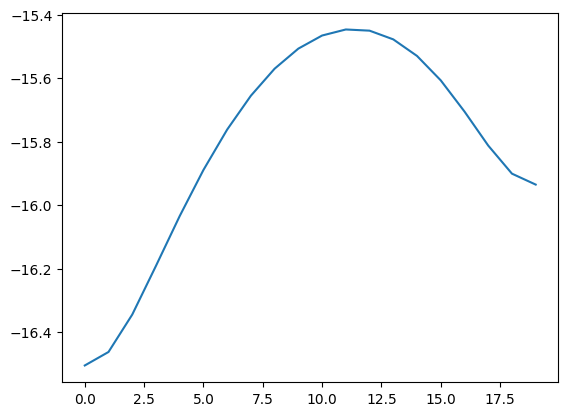

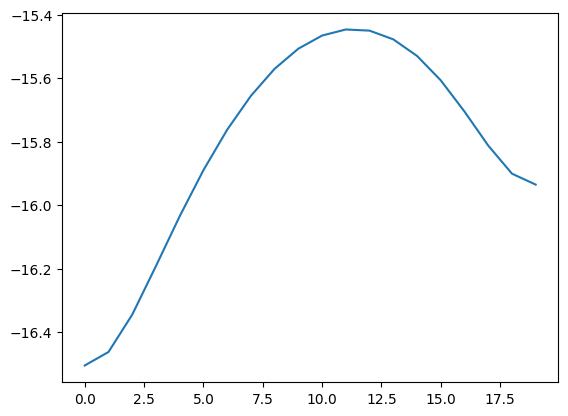

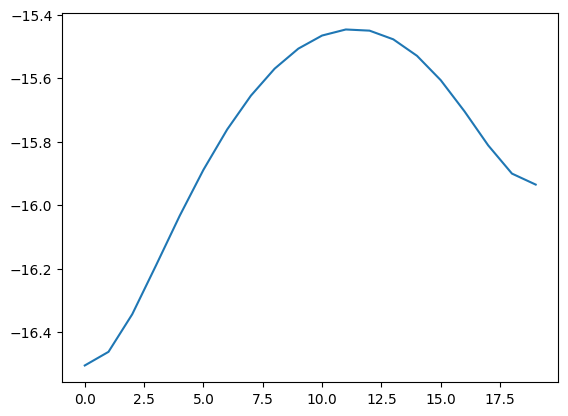

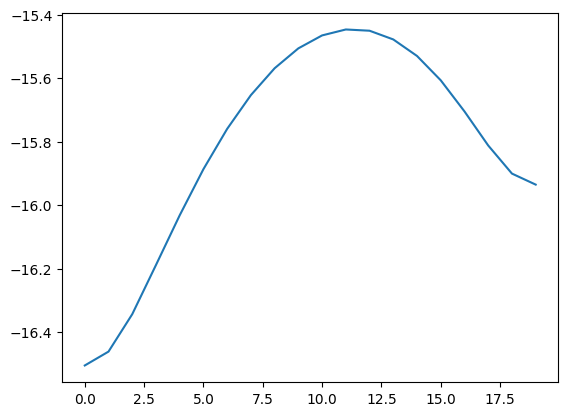

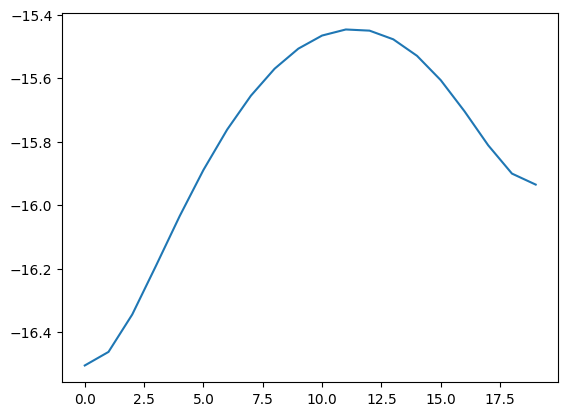

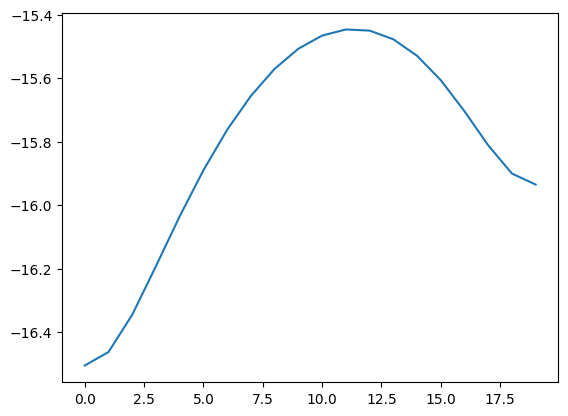

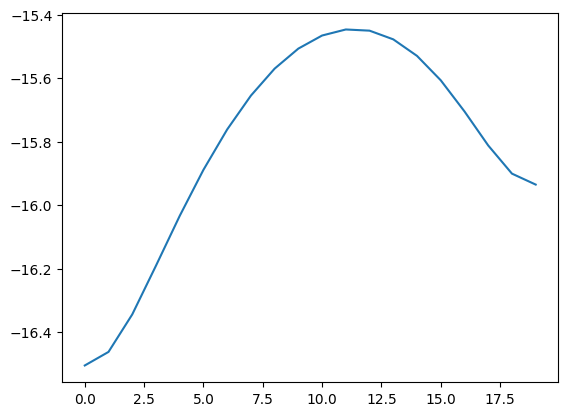

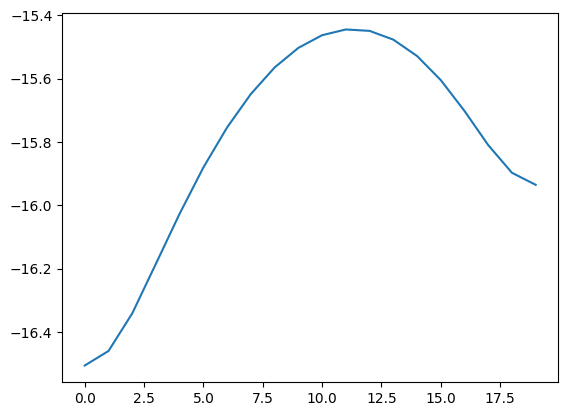

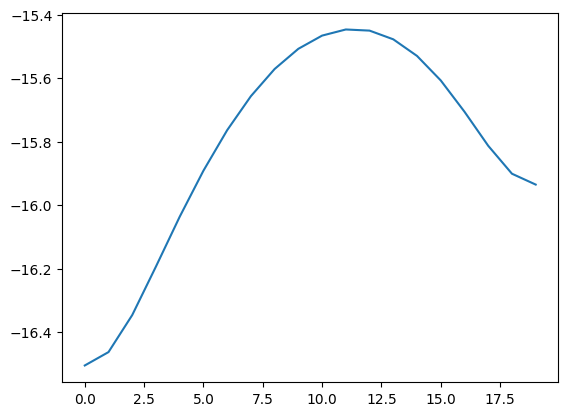

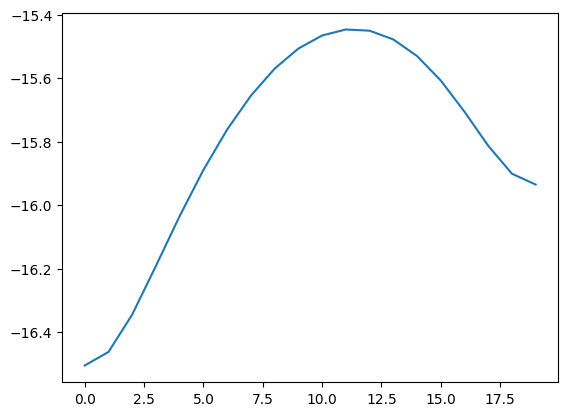

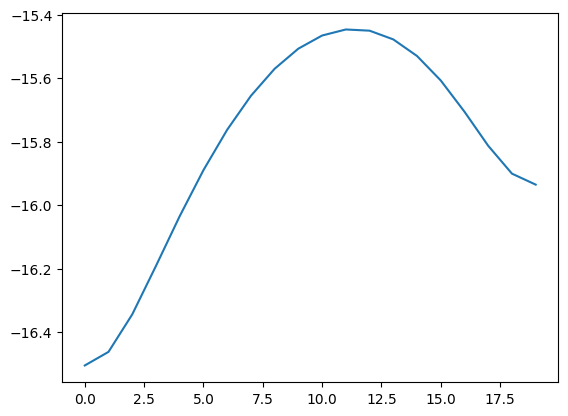

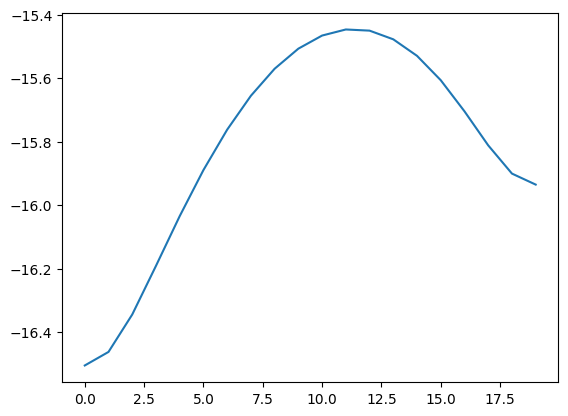

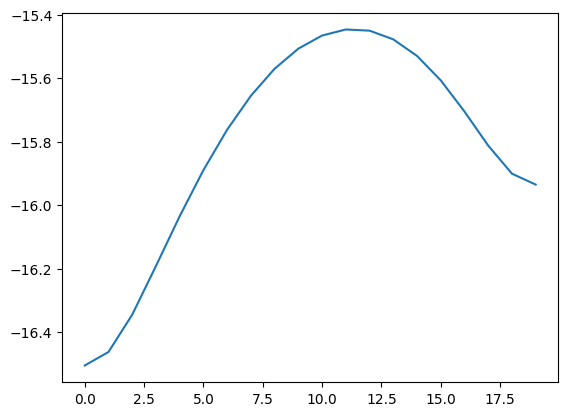

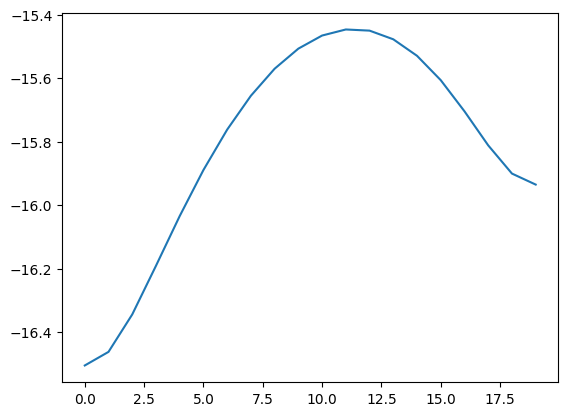

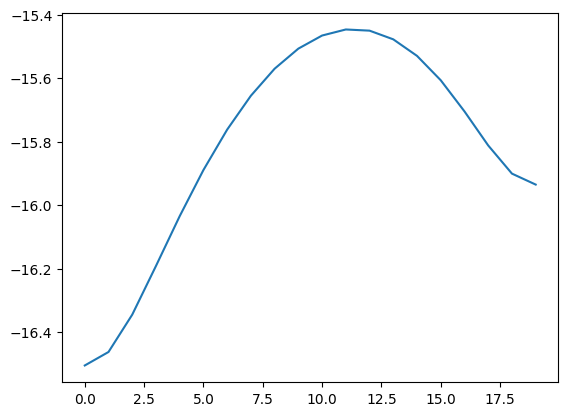

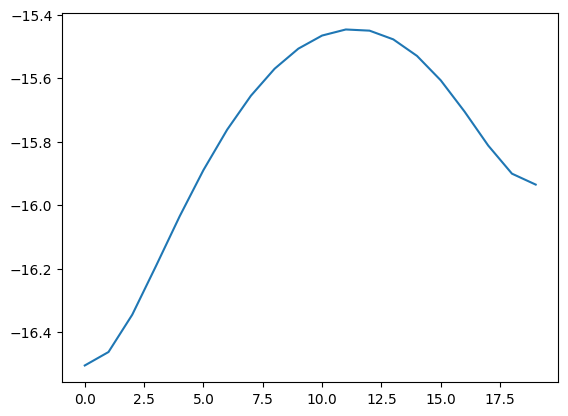

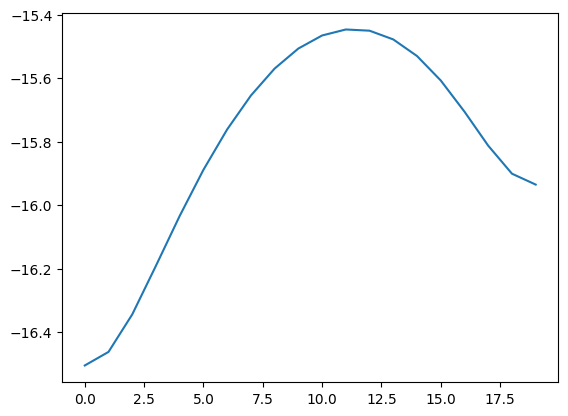

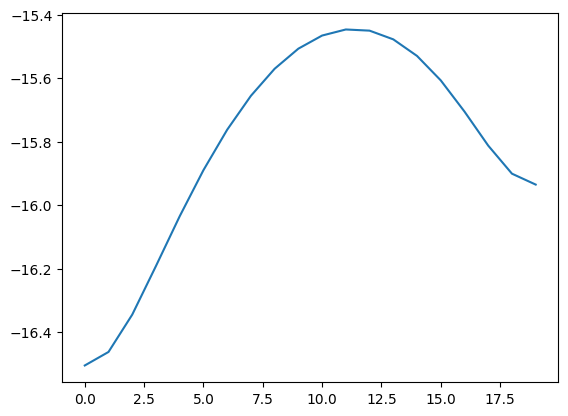

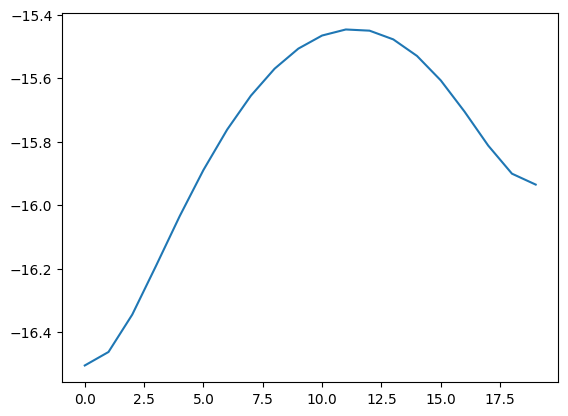

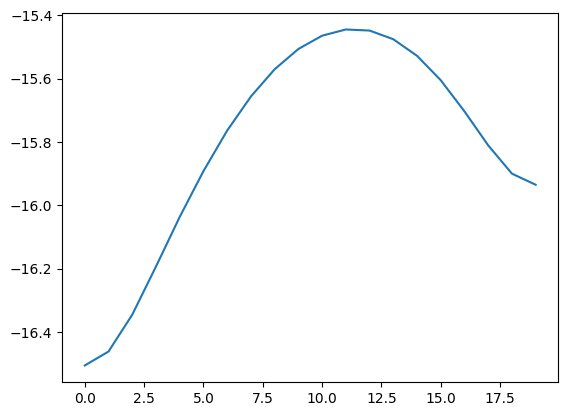

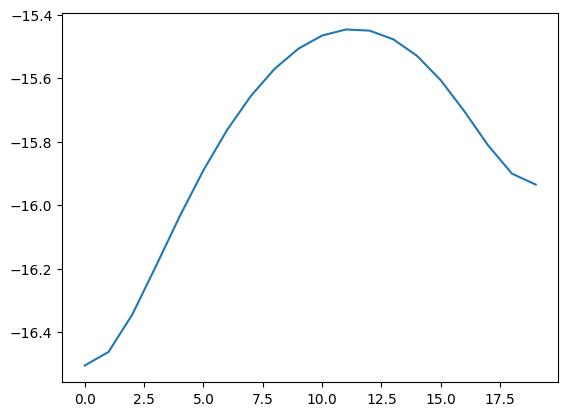

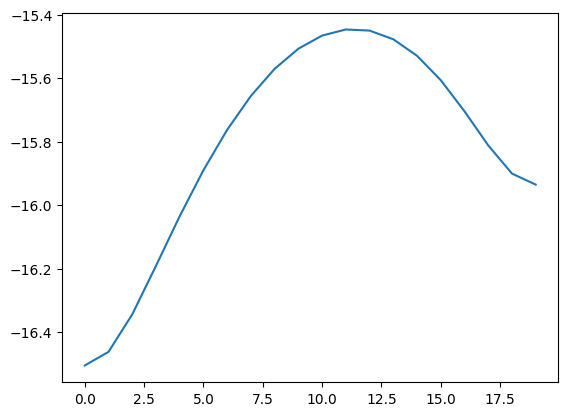

In [17]:
max_E = []
for i in range(len(subset_history_numpy)):
    path_energy = np.array([compute_lj_energy(pos) for pos in subset_history_numpy[i]])
    plt.plot(path_energy)
    plt.show()
    max_E.append(np.max(path_energy))

initial_energy = compute_lj_energy(initial_ase.get_positions())
energy_barrier = max_E - initial_energy

path_energy_neb = np.array([compute_lj_energy(pos) for pos in neb_positions])
maxE_neb = np.max(path_energy_neb)

energy_barrier_neb = maxE_neb - initial_energy

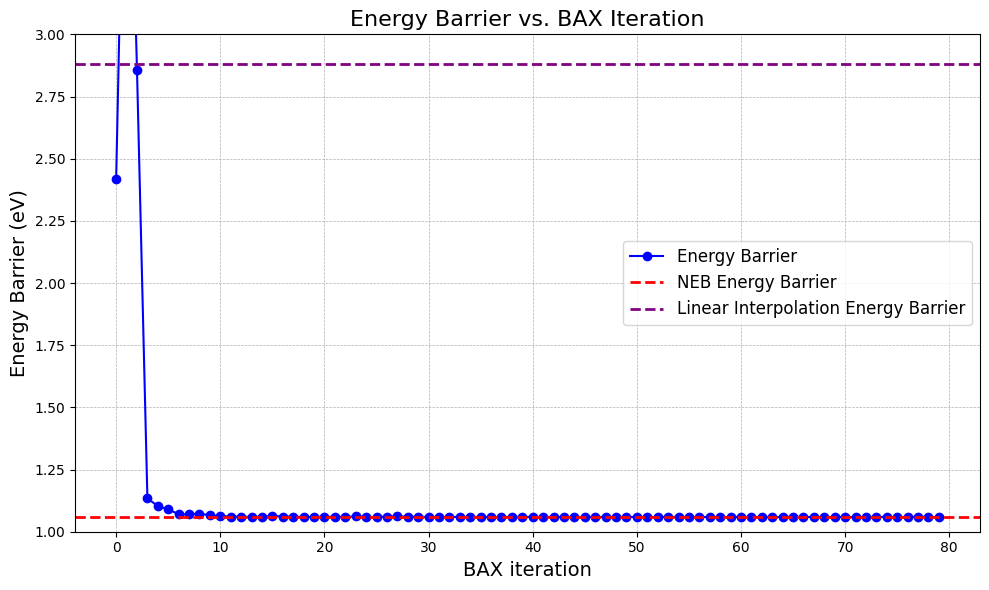

In [18]:
# Compute energy barrier data for the BAX iterations
max_E = []
for i in range(len(subset_history_numpy)):
    path_energy = np.array([compute_lj_energy(pos) for pos in subset_history_numpy[i]])
    #plt.plot(path_energy)
    #plt.show()
    max_E.append(np.max(path_energy))

initial_energy = compute_lj_energy(initial_ase.get_positions())
energy_barrier = np.array(max_E) - initial_energy

# Compute the NEB energy barrier
path_energy_neb = np.array([compute_lj_energy(pos) for pos in neb_positions])
maxE_neb = np.max(path_energy_neb)
energy_barrier_neb = maxE_neb - initial_energy

# Compute energy barrier for a linear interpolation between the start and end points
start_pos = initial_ase.get_positions()
end_pos = final_ase.get_positions()
n_interp = 50  # number of interpolation points; adjust as needed
alphas = np.linspace(0, 1, n_interp)
linear_positions = [start_pos + alpha * (end_pos - start_pos) for alpha in alphas]
linear_energy = np.array([compute_lj_energy(pos) for pos in linear_positions])
maxE_linear = np.max(linear_energy)
energy_barrier_linear = maxE_linear - initial_energy

# Plotting the energy barriers
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(10, 6))
# Plot the energy barrier data from the BAX iterations
plt.plot(energy_barrier, marker='o', linestyle='-', color='blue', label='Energy Barrier')
plt.ylim(1.04, 1.08)
plt.ylim(1, 3)
#plt.yscale('log')
# Add a horizontal red dashed line for the NEB energy barrier
plt.axhline(energy_barrier_neb, color='red', linestyle='--', linewidth=2, label='NEB Energy Barrier')

# Add a horizontal purple dashed line for the linear interpolation energy barrier
plt.axhline(energy_barrier_linear, color='purple', linestyle='--', linewidth=2, label='Linear Interpolation Energy Barrier')


plt.xlabel("BAX iteration", fontsize=14)
plt.ylabel("Energy Barrier (eV)", fontsize=14)
plt.title("Energy Barrier vs. BAX Iteration", fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)

# Disable scientific notation on the y-axis
ax = plt.gca()
ax.get_yaxis().set_major_formatter(ScalarFormatter(useOffset=False))

plt.tight_layout()
plt.show()


In [19]:
min(energy_barrier), energy_barrier_neb, np.argmin(energy_barrier)

(1.059307332879012, 1.0592937540536624, 78)

In [20]:
energy_barrier

array([2.41929335, 4.39494973, 2.85760154, 1.13427817, 1.10314054,
       1.09015111, 1.07029668, 1.07029118, 1.07325264, 1.06558418,
       1.06337014, 1.06105361, 1.05996277, 1.06013416, 1.05996367,
       1.0638796 , 1.06097923, 1.06093092, 1.05939339, 1.06007825,
       1.05962051, 1.06037234, 1.05932334, 1.06209837, 1.05931437,
       1.05947135, 1.0608425 , 1.06233489, 1.06029509, 1.05979003,
       1.06004819, 1.05955953, 1.05947023, 1.05947054, 1.0599341 ,
       1.05942403, 1.05936777, 1.05954473, 1.05948378, 1.05982764,
       1.05948495, 1.05945681, 1.05948422, 1.05941458, 1.05954548,
       1.05937752, 1.06002317, 1.05933853, 1.05963686, 1.05942473,
       1.0593296 , 1.0594039 , 1.05957901, 1.05954023, 1.05942742,
       1.05962375, 1.05934172, 1.05941768, 1.05938061, 1.05939203,
       1.05937272, 1.05952202, 1.05940477, 1.05936679, 1.05936119,
       1.06070601, 1.05933018, 1.05938666, 1.05954129, 1.05942023,
       1.05935061, 1.05934688, 1.05934896, 1.05939727, 1.05937

# Real v. Predicted Energy Barrier

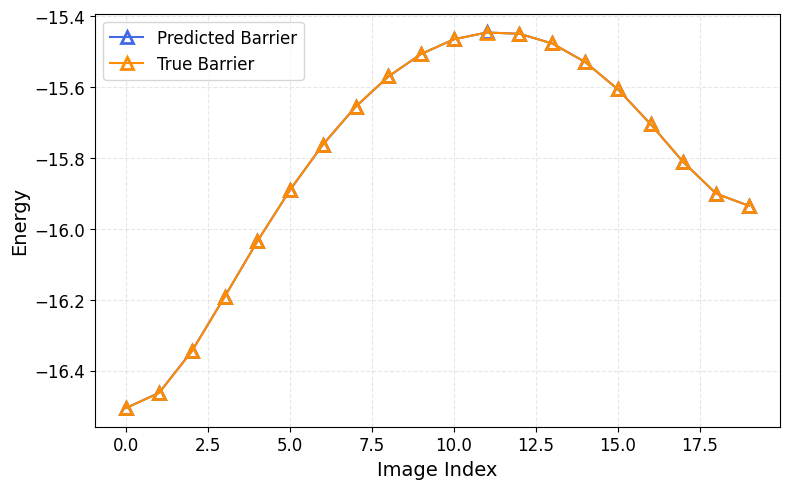

In [21]:
best_index = np.argmin(energy_barrier)

# Compute predicted path energies
path_energy = np.array([compute_lj_energy(pos) for pos in subset_history_numpy[best_index]])

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(path_energy, '^-', label='Predicted Barrier', color='royalblue',
         markerfacecolor='none', markeredgewidth=2, markersize=8)
plt.plot(energies, '^-', label='True Barrier', color='darkorange',
         markerfacecolor='none', markeredgewidth=2, markersize=8)

plt.xlabel("Image Index", fontsize=14)
plt.ylabel("Energy", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


# Classical NEB v. BAX NEB

      Step     Time          Energy          fmax
FIRE:    0 18:24:05      -15.002005        9.127576
FIRE:    1 18:24:05      -15.406114        2.433229
FIRE:    2 18:24:06      -15.425460        1.701338
FIRE:    3 18:24:06      -15.437039        0.815503
FIRE:    4 18:24:06      -15.431111        1.252813
FIRE:    5 18:24:06      -15.434361        1.065878
FIRE:    6 18:24:06      -15.439041        0.734421
FIRE:    7 18:24:07      -15.442669        0.400627
FIRE:    8 18:24:07      -15.443642        0.371648
FIRE:    9 18:24:07      -15.442445        0.669091
FIRE:   10 18:24:07      -15.442581        0.653378
FIRE:   11 18:24:07      -15.442838        0.622376
FIRE:   12 18:24:08      -15.443186        0.576954
FIRE:   13 18:24:08      -15.443585        0.518500
FIRE:   14 18:24:08      -15.443988        0.449033
FIRE:   15 18:24:08      -15.444351        0.374886
FIRE:   16 18:24:08      -15.444640        0.312046
FIRE:   17 18:24:08      -15.444848        0.270107
FIRE:   18 18:

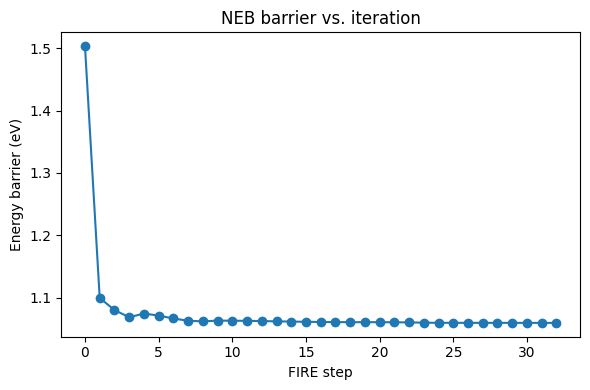

In [22]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from ase.neb import NEB
from ase.optimize import FIRE

# … your existing setup …
ase0 = copy.deepcopy(test[0])
ase0.set_calculator(copy.deepcopy(ase_calculator))
aseN = copy.deepcopy(test[5])
aseN.set_calculator(copy.deepcopy(ase_calculator))

n_images = 20
images = [ase0]
for i in range(1, n_images-1):
    img = ase0.copy()
    img.set_calculator(copy.deepcopy(ase_calculator))
    images.append(img)
images.append(aseN)

neb = NEB(images, climb=False, remove_rotation_and_translation=True, method='string')
neb.interpolate(method='linear')
optimizer = FIRE(neb)

# prepare a list to store barrier vs step
barriers = []

def record_barrier():
    energies = [img.get_potential_energy() for img in images]
    barrier = max(energies) - min(energies)
    barriers.append(barrier)

# attach the recorder to run at every step
optimizer.attach(record_barrier, interval=1)

# run NEB
optimizer.run(fmax=0.05, steps=500)

# now plot
plt.figure(figsize=(6,4))
plt.plot(barriers, marker='o', linestyle='-')
plt.xlabel('FIRE step')
plt.ylabel('Energy barrier (eV)')
plt.title('NEB barrier vs. iteration')
plt.tight_layout()
plt.show()


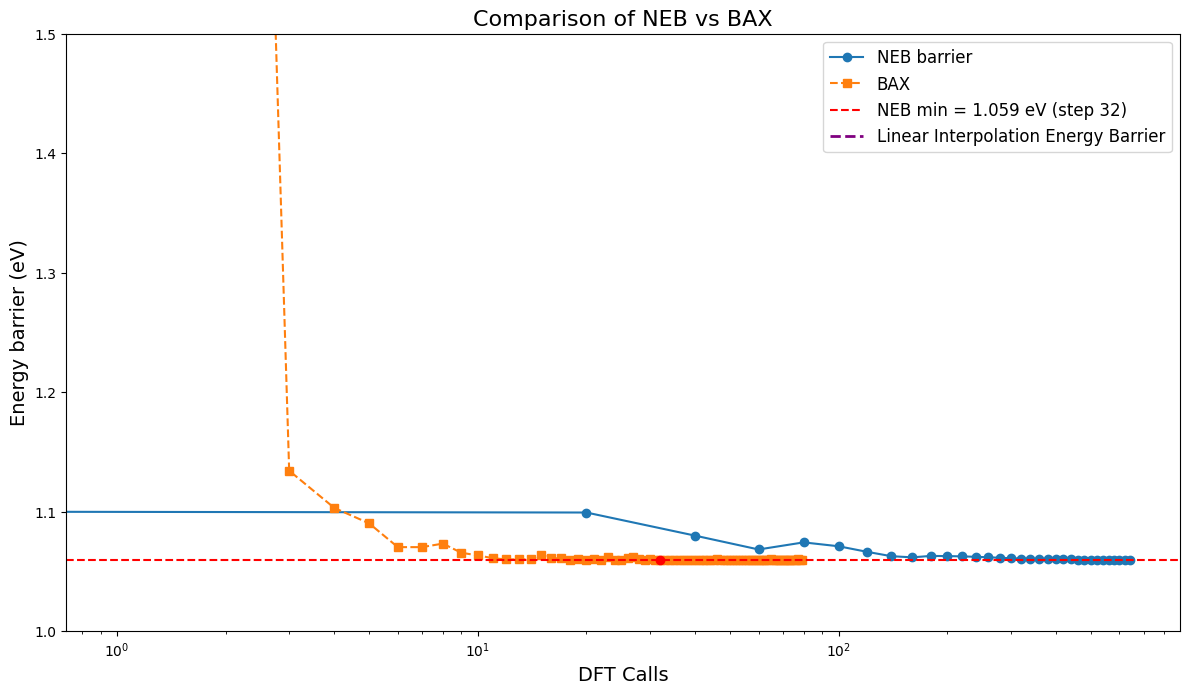

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# assume `barriers` and `energy_barrier` are your two lists

# NEB data
x_neb = np.arange(len(barriers))*20            # steps 0,1,2,...
y_neb = np.array(barriers)

# other process, scaled x by 30
x_other = np.arange(len(energy_barrier))   # steps 0→0, 1→30, 2→60, ...
y_other = np.array(energy_barrier)

# find NEB minimum
min_val  = y_neb.min()
min_step = y_neb.argmin()

plt.figure(figsize=(12, 7))

# plot NEB barrier
plt.plot(x_neb, y_neb, marker='o', linestyle='-', label='NEB barrier')

# plot other energy barrier
plt.plot(x_other, y_other, marker='s', linestyle='--', label='BAX')

# red dashed min line (for NEB)
plt.axhline(min_val, color='red', linestyle='--',
            label=f'NEB min = {min_val:.3f} eV (step {min_step})')
plt.axhline(energy_barrier_linear, color='purple', linestyle='--', linewidth=2, label='Linear Interpolation Energy Barrier')

plt.scatter(min_step, min_val, color='red', zorder=5)

plt.xlabel('DFT Calls', fontsize=14)
plt.ylabel('Energy barrier (eV)', fontsize=14)
plt.title('Comparison of NEB vs BAX', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
#plt.yscale('log')
plt.xscale('log')
plt.ylim(1, 1.5)
plt.show()


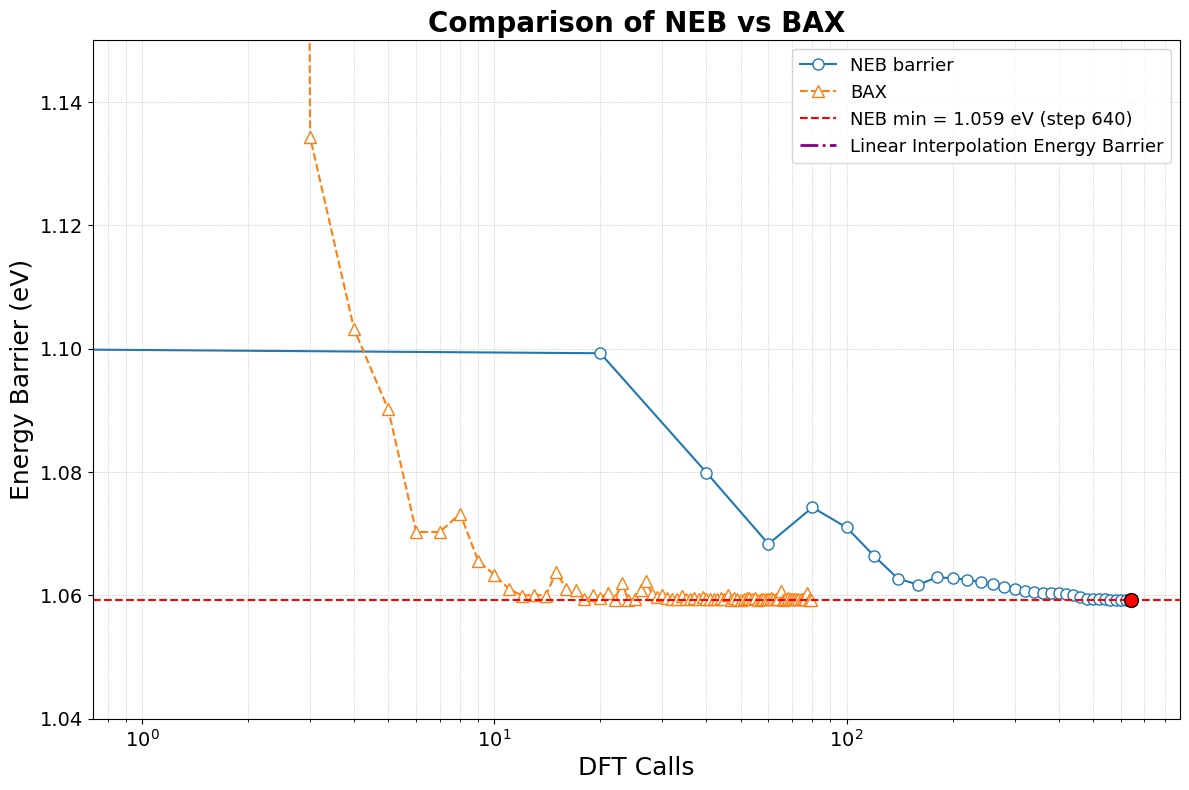

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# assume `barriers`, `energy_barrier`, and `energy_barrier_linear` are defined

# NEB data
x_neb = np.arange(len(barriers)) * 20
y_neb = np.array(barriers)

# BAX data
x_other = np.arange(len(energy_barrier))
y_other = np.array(energy_barrier)

# NEB minimum
min_val = y_neb.min()
min_step = x_neb[y_neb.argmin()]  # get x value, not index

plt.figure(figsize=(12, 8))

# Plot NEB
plt.plot(x_neb, y_neb, marker='o', linestyle='-', color='#1f77b4',
         markersize=8, label='NEB barrier', markerfacecolor='white')

# Plot BAX
plt.plot(x_other, y_other, marker='^', linestyle='--', color='#ff7f0e',
         markersize=8, label='BAX', markerfacecolor='white')

# NEB min line
plt.axhline(min_val, color='red', linestyle='--', linewidth=1.5,
            label=f'NEB min = {min_val:.3f} eV (step {min_step})')

# Linear interpolation barrier
plt.axhline(energy_barrier_linear, color='purple', linestyle='-.',
            linewidth=2, label='Linear Interpolation Energy Barrier')

# Highlight minimum point
plt.scatter(min_step, min_val, color='red', edgecolors='black',
            zorder=5, s=100)

# Labels and title
plt.xlabel('DFT Calls', fontsize=18)
plt.ylabel('Energy Barrier (eV)', fontsize=18)
plt.title('Comparison of NEB vs BAX', fontsize=20, weight='bold')

# Axes settings
plt.xscale('log')
#plt.xlim(10, 1000)
plt.ylim(1.04, 1.15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Legend
plt.legend(fontsize=13, loc='best', frameon=True)

plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()


# Random Sample Analysis

In [25]:
max_E = []
for i in range(len(subset_history_random)):
    path_energy = np.array([compute_lj_energy(pos) for pos in subset_history_random[i]])
    #plt.plot(path_energy)
    #plt.show()
    max_E.append(np.max(path_energy))

initial_energy = compute_lj_energy(initial_ase.get_positions())
energy_barrier_random = np.array(max_E) - initial_energy

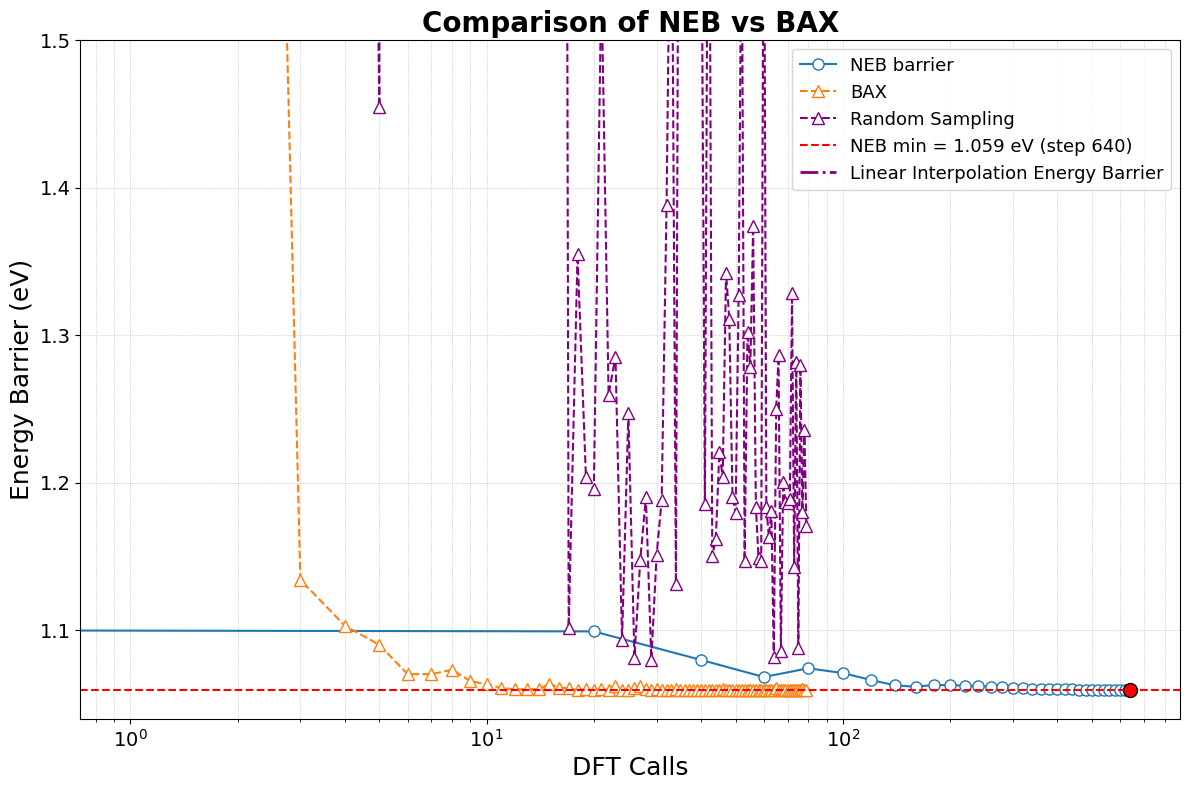

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# assume `barriers`, `energy_barrier`, and `energy_barrier_linear` are defined

# NEB data
x_neb = np.arange(len(barriers)) * 20
y_neb = np.array(barriers)

# BAX data
x_other = np.arange(len(energy_barrier))
y_other = np.array(energy_barrier)

# Random data
x_other_rand = np.arange(len(energy_barrier_random))
y_other_rand = np.array(energy_barrier_random)

# NEB minimum
min_val = y_neb.min()
min_step = x_neb[y_neb.argmin()]  # get x value, not index

plt.figure(figsize=(12, 8))

# Plot NEB
plt.plot(x_neb, y_neb, marker='o', linestyle='-', color='#1f77b4',
         markersize=8, label='NEB barrier', markerfacecolor='white')

# Plot BAX
plt.plot(x_other, y_other, marker='^', linestyle='--', color='#ff7f0e',
         markersize=8, label='BAX', markerfacecolor='white')

# Plot Rand
plt.plot(x_other_rand, y_other_rand, marker='^', linestyle='--', color='purple',
         markersize=8, label='Random Sampling', markerfacecolor='white')

# NEB min line
plt.axhline(min_val, color='red', linestyle='--', linewidth=1.5,
            label=f'NEB min = {min_val:.3f} eV (step {min_step})')

# Linear interpolation barrier
plt.axhline(energy_barrier_linear, color='purple', linestyle='-.',
            linewidth=2, label='Linear Interpolation Energy Barrier')

# Highlight minimum point
plt.scatter(min_step, min_val, color='red', edgecolors='black',
            zorder=5, s=100)

# Labels and title
plt.xlabel('DFT Calls', fontsize=18)
plt.ylabel('Energy Barrier (eV)', fontsize=18)
plt.title('Comparison of NEB vs BAX', fontsize=20, weight='bold')

# Axes settings
plt.xscale('log')
#plt.xlim(10, 1000)
plt.ylim(1.04, 1.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Legend
plt.legend(fontsize=13, loc='best', frameon=True)

plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()


# E barrier, fmax, model check performance

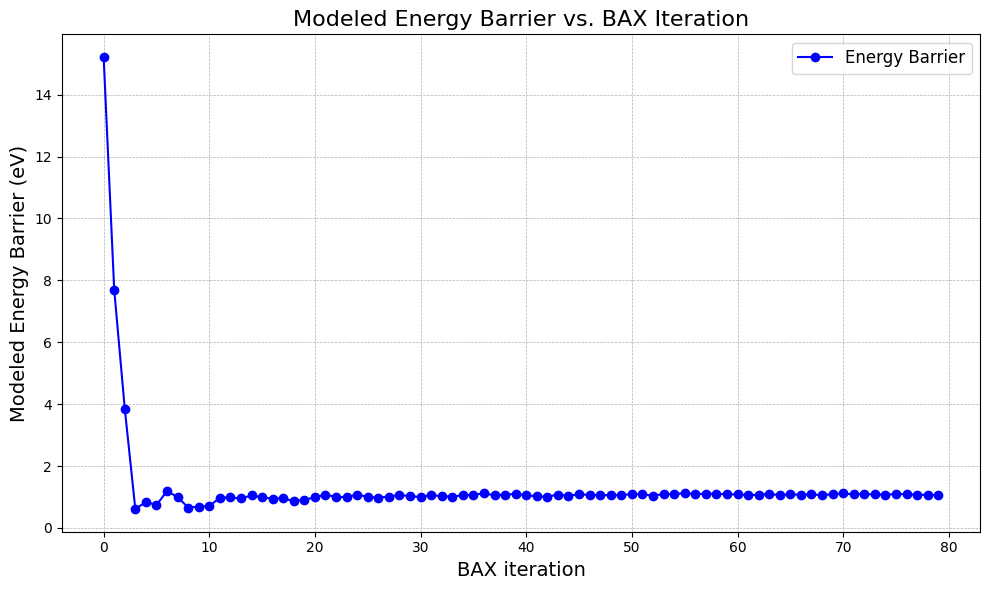

In [27]:
plt.figure(figsize=(10, 6))
# Plot the energy barrier data from the BAX iterations
plt.plot(energy_barrier_history, marker='o', linestyle='-', color='blue', label='Energy Barrier')
#plt.ylim(0.2, 0.4)
#plt.yscale('log')
plt.xlabel("BAX iteration", fontsize=14)
plt.ylabel("Modeled Energy Barrier (eV)", fontsize=14)
plt.title("Modeled Energy Barrier vs. BAX Iteration", fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)

# Disable scientific notation on the y-axis
ax = plt.gca()
ax.get_yaxis().set_major_formatter(ScalarFormatter(useOffset=False))

plt.tight_layout()
plt.show()


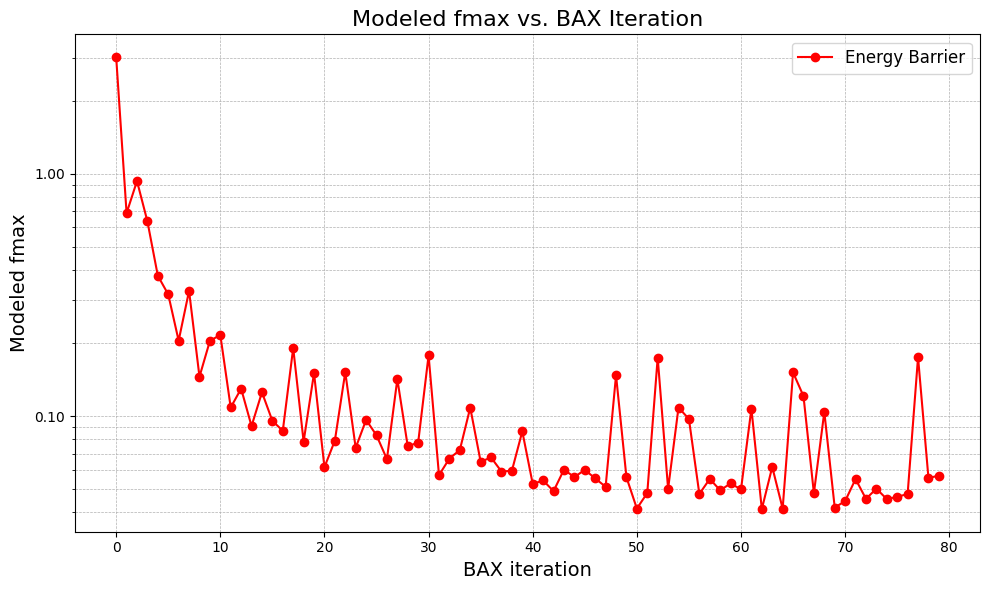

In [28]:
plt.figure(figsize=(10, 6))
# Plot the energy barrier data from the BAX iterations
plt.plot(fmax_history, marker='o', linestyle='-', color='red', label='Energy Barrier')
#plt.ylim(0, 2)
plt.yscale('log')
plt.xlabel("BAX iteration", fontsize=14)
plt.ylabel("Modeled fmax", fontsize=14)
plt.title("Modeled fmax vs. BAX Iteration", fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)

# Disable scientific notation on the y-axis
ax = plt.gca()
ax.get_yaxis().set_major_formatter(ScalarFormatter(useOffset=False))

plt.tight_layout()
plt.show()


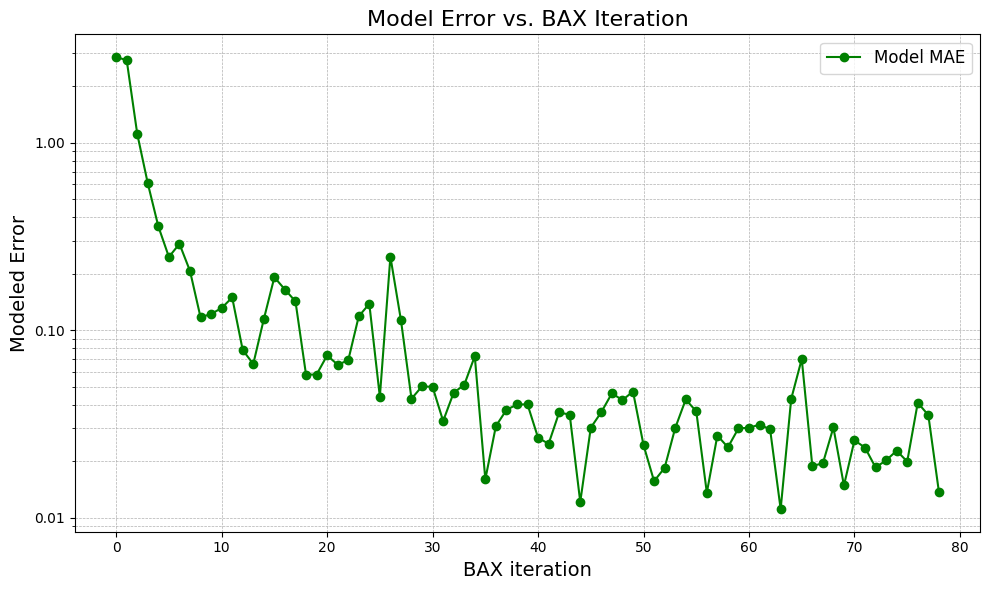

In [29]:
plt.figure(figsize=(10, 6))
# Plot the energy barrier data from the BAX iterations
plt.plot(mae_Nm1_on_N, marker='o', linestyle='-', color='green', label='Model MAE')
#plt.ylim(0.2, 0.4)
plt.yscale('log')
plt.xlabel("BAX iteration", fontsize=14)
plt.ylabel("Modeled Error", fontsize=14)
plt.title("Model Error vs. BAX Iteration", fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)

# Disable scientific notation on the y-axis
ax = plt.gca()
ax.get_yaxis().set_major_formatter(ScalarFormatter(useOffset=False))

plt.tight_layout()
plt.show()


# Robust Conv Criterion

In [30]:
thresh_mae = 0.1
thresh_fmax = 0.1
patience_num = 2

converged_indices = []

for i in range(len(mae_Nm1_on_N)):
    if mae_Nm1_on_N[i] < thresh_mae and fmax_history[i] < thresh_fmax:
        converged_indices.append(i)
        
converged_index = converged_indices[patience_num-1]
print(converged_indices)
print("Converged Index: ", converged_index )

[13, 18, 20, 21, 25, 28, 29, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 49, 50, 51, 53, 55, 56, 57, 58, 59, 60, 62, 63, 64, 67, 69, 70, 71, 72, 73, 74, 75, 76, 78]
Converged Index:  18


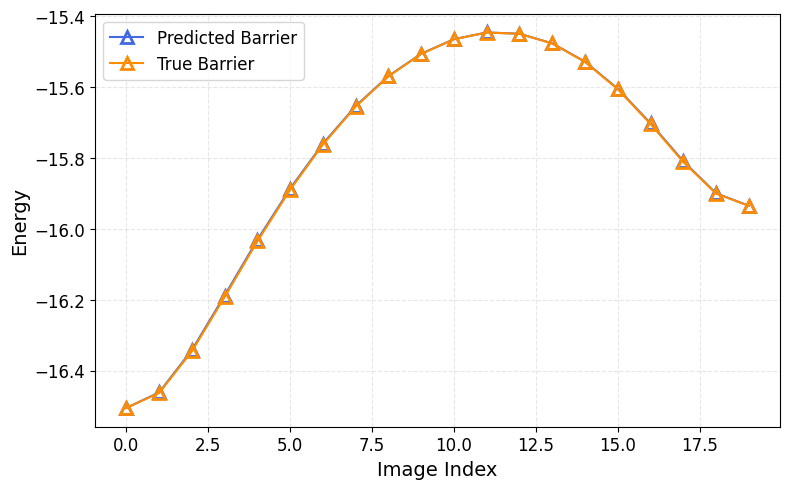

In [31]:

# Compute predicted path energies
path_energy = np.array([compute_lj_energy(pos) for pos in subset_history_numpy[converged_index]])

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(path_energy, '^-', label='Predicted Barrier', color='royalblue',
         markerfacecolor='none', markeredgewidth=2, markersize=8)
plt.plot(energies, '^-', label='True Barrier', color='darkorange',
         markerfacecolor='none', markeredgewidth=2, markersize=8)

plt.xlabel("Image Index", fontsize=14)
plt.ylabel("Energy", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


In [48]:
energy_barrier[converged_index], energy_barrier_neb, np.argmin(energy_barrier)

(1.0593933883541595, 1.0592937540536624, 78)

In [49]:
(1.0593933883541595 - 1.0592937540536624)/1.0592937540536624

9.405729063898495e-05

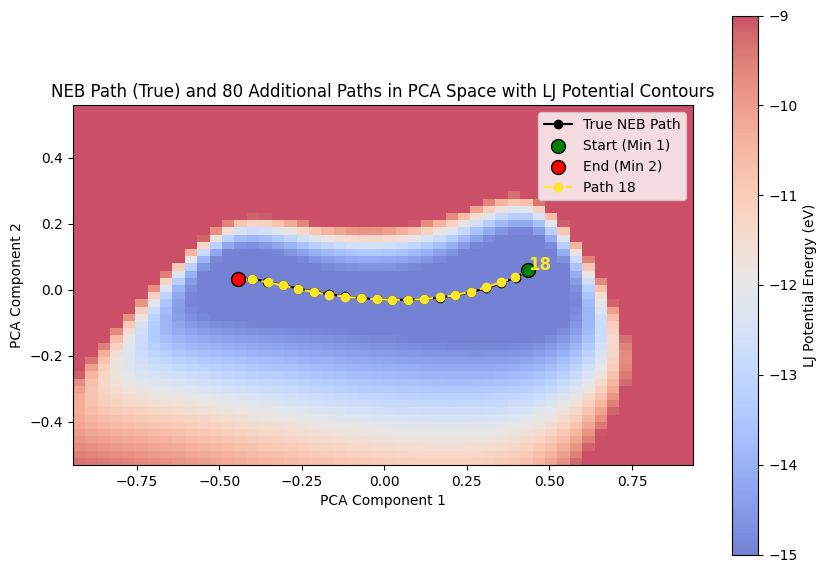

In [32]:
i = converged_index
path = subset_history_numpy[converged_index]


plt.figure(figsize=(10, 7))
    
# Plot the LJ energy contour map (background)
plt.imshow(
    lj_energies,
    cmap="coolwarm",
    alpha=0.7,
 vmin=-15,
vmax=-9,
    extent=(x_min, x_max, y_min, y_max),
    origin="lower"
)
plt.colorbar(label="LJ Potential Energy (eV)")

# Plot the true NEB path in black solid line with markers
plt.plot(pca_x, pca_y, marker='o', linestyle='-', color="black", label="True NEB Path")
plt.scatter(pca_x[0], pca_y[0], color="green", s=100, label="Start (Min 1)", edgecolors="black", zorder=3)
plt.scatter(pca_x[-1], pca_y[-1], color="red", s=100, label="End (Min 2)", edgecolors="black", zorder=3)

# Plot the BAX path in dashed line
path_pca = pca.transform(path)  # Transform the path to PCA space
plt.plot(path_pca[:, 0], path_pca[:, 1], marker='o', linestyle='--', 
         label=f"Path {i}", color=color)
plt.text(path_pca[0, 0], path_pca[0, 1], f"{i}", fontsize=12,
         fontweight='bold', color=color, zorder=4)


plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"NEB Path (True) and {num_paths} Additional Paths in PCA Space with LJ Potential Contours")
plt.legend()
plt.show()


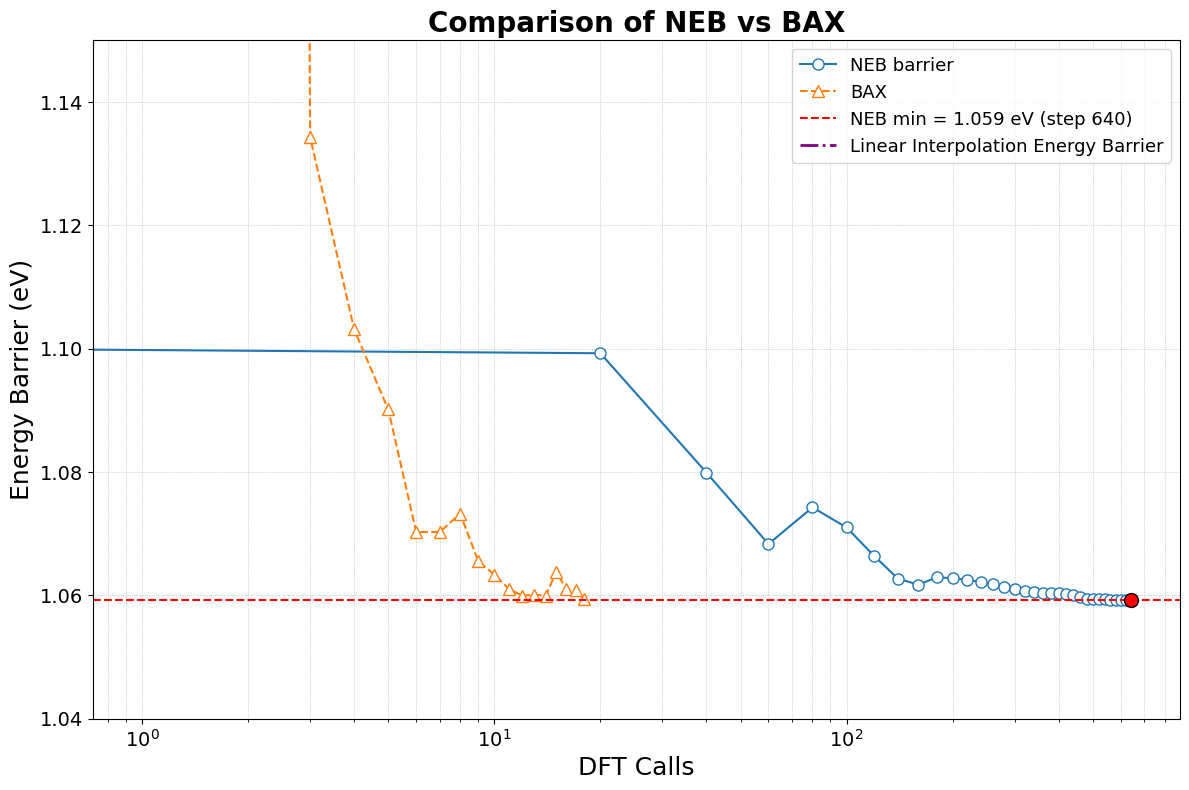

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# assume `barriers`, `energy_barrier`, and `energy_barrier_linear` are defined

# NEB data
x_neb = np.arange(len(barriers)) * 20
y_neb = np.array(barriers)

# BAX data
x_other = np.arange(len(energy_barrier))[:converged_index+1]
y_other = np.array(energy_barrier)[:converged_index+1]

# NEB minimum
min_val = y_neb.min()
min_step = x_neb[y_neb.argmin()]  # get x value, not index

plt.figure(figsize=(12, 8))

# Plot NEB
plt.plot(x_neb, y_neb, marker='o', linestyle='-', color='#1f77b4',
         markersize=8, label='NEB barrier', markerfacecolor='white')

# Plot BAX
plt.plot(x_other, y_other, marker='^', linestyle='--', color='#ff7f0e',
         markersize=8, label='BAX', markerfacecolor='white')

# NEB min line
plt.axhline(min_val, color='red', linestyle='--', linewidth=1.5,
            label=f'NEB min = {min_val:.3f} eV (step {min_step})')

# Linear interpolation barrier
plt.axhline(energy_barrier_linear, color='purple', linestyle='-.',
            linewidth=2, label='Linear Interpolation Energy Barrier')

# Highlight minimum point
plt.scatter(min_step, min_val, color='red', edgecolors='black',
            zorder=5, s=100)

# Labels and title
plt.xlabel('DFT Calls', fontsize=18)
plt.ylabel('Energy Barrier (eV)', fontsize=18)
plt.title('Comparison of NEB vs BAX', fontsize=20, weight='bold')

# Axes settings
plt.xscale('log')
#plt.xlim(10, 1000)
plt.ylim(1.04, 1.15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Legend
plt.legend(fontsize=13, loc='best', frameon=True)

plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()


# Prettier Plots

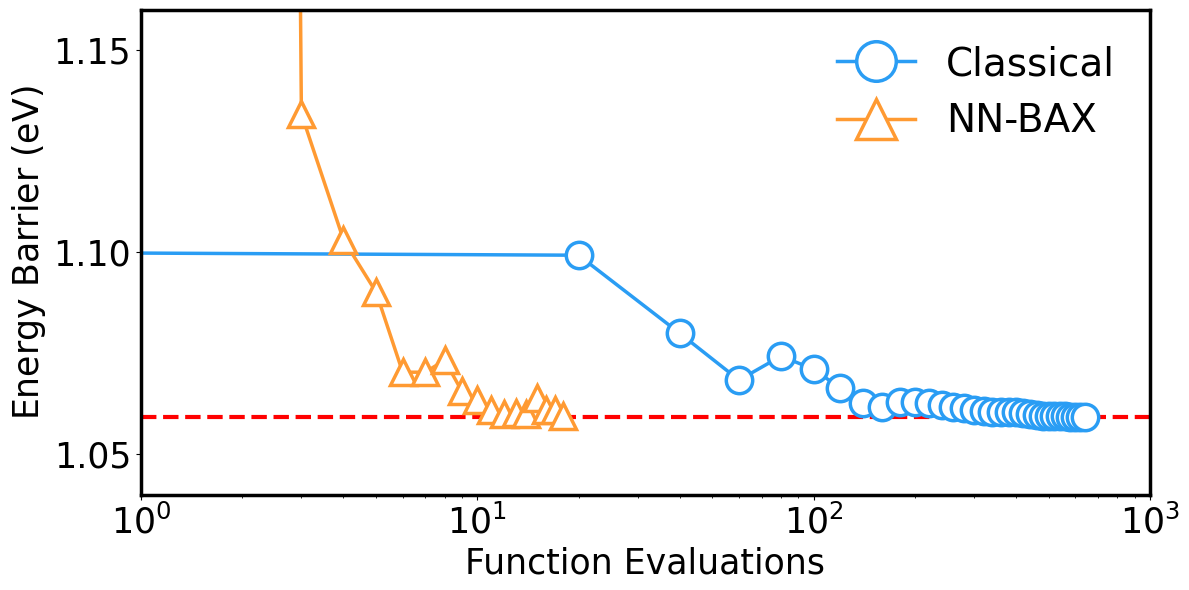

In [34]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.linewidth'] = 2.5

# assume `barriers`, `energy_barrier`, and `energy_barrier_linear` are defined

# NEB data
x_neb = np.arange(len(barriers)) * 20
y_neb = np.array(barriers)

# BAX data
x_other = np.arange(len(energy_barrier))[:converged_index+1]
y_other = np.array(energy_barrier)[:converged_index+1]

# NEB minimum
min_val = y_neb[-1]
min_step = x_neb[y_neb.argmin()]  # get x value, not index

plt.figure(figsize=(12, 6))

plt.axhline(min_val, color='red', linestyle='--', linewidth=3)



# Plot NEB (brighter blue)
plt.plot(x_neb, y_neb, marker='o', linestyle='-', color='#2a9df4',
         markersize=19, linewidth=2.5, markeredgewidth=2.5,label='Classical', markerfacecolor='white')

# Plot BAX (brighter orange)
plt.plot(x_other, y_other, marker='^', linestyle='-', color='#ff9a32',
         markersize=19, linewidth=2.5, markeredgewidth=2.5,label='NN-BAX', markerfacecolor='white')

# NEB min line

# Linear interpolation barrier
#plt.axhline(energy_barrier_linear, color='purple', linestyle='-.',
#            linewidth=3, label='Linear Interpolation Energy Barrier')

# Highlight minimum point
#plt.scatter(min_step, min_val, color='red', edgecolors='black',
#            zorder=5, s=100)

# Labels and title
plt.xlabel('Function Evaluations', fontsize=25)
plt.ylabel(r"Energy Barrier ($\mathrm{eV}$)", fontsize=25)
#plt.title('Comparison of NEB vs BAX', fontsize=20, weight='bold')

# Axes settings
plt.xscale('log')
plt.xlim(1, 1000)
plt.ylim(1.04, 1.16)
#plt.yscale('log')
plt.xticks(fontsize=25)
plt.yticks(ticks=[1.05, 1.1, 1.15],fontsize=25)


# Legend
plt.legend(fontsize=28, loc='best', frameon=False, markerscale = 1.5)

#plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()


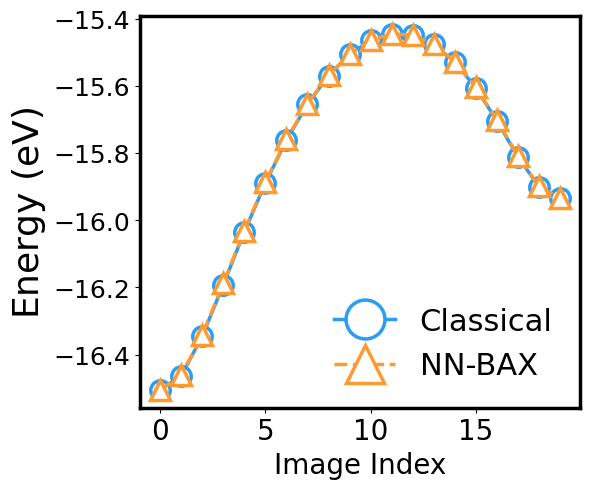

In [35]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.linewidth'] = 2.5

# Compute predicted path energies
path_energy = np.array([compute_lj_energy(pos) for pos in subset_history_numpy[converged_index]])

plt.figure(figsize=(6, 5))

# --- Classical NEB (bright blue, hollow circles, solid line) ---
plt.plot(
    energies, marker='o', linestyle='-', color='#2a9df4',
    markersize=14, markerfacecolor='white', markeredgecolor='#2a9df4',
    markeredgewidth=2.5, linewidth=2.5, label='Classical'
)

# --- NN-BAX (bright orange, hollow triangles, dashed line) ---
plt.plot(
    path_energy, marker='^', linestyle='--', color='#ff9a32',
    markersize=14, markerfacecolor='white', markeredgecolor='#ff9a32',
    markeredgewidth=2.5, linewidth=2.5, label='NN-BAX'
)

# Labels
plt.xlabel("Image Index", fontsize=20)
plt.ylabel(r"Energy ($\mathrm{eV}$)", fontsize=26)

# Tick font sizes
plt.xticks(ticks=range(0, len(energies), 5), fontsize=20)
plt.yticks(fontsize=18)

# Legend
plt.legend(fontsize=22, frameon=False, markerscale = 2)

plt.tight_layout()
plt.show()


In [36]:

# Convert ASE Atoms object list to a 2D numpy array (20 steps x 21D positions)
neb_positions = np.array([atoms.positions.flatten() for atoms in images_ase])  # Shape (20, 21)

# Perform PCA (reduce 21D path to 2D)
pca = PCA(n_components=2)
neb_pca = pca.fit_transform(neb_positions)  # Shape (20, 2)

# Extract the transformed coordinates
pca_x, pca_y = neb_pca[:, 0], neb_pca[:, 1]

# Function to calculate LJ energy for a given configuration
def compute_lj_energy(positions):
    atoms = images_ase[0].copy()  # Copy an Atoms object to set new positions
    atoms.set_positions(positions.reshape(7, 3))
    atoms.set_calculator(LennardJones(rc=100))
    return atoms.get_potential_energy()

# Generate a grid for the contour plot
num_grid = 50  # Resolution of the contour grid
#x_min, x_max = pca_x.min() - 0.5, pca_x.max() + 0.5
#y_min, y_max = pca_y.min() - 0.5, pca_y.max() + 0.5
bound = 0.7

x_min, x_max = -bound, bound
y_min, y_max = -bound, bound


#y_min, y_max = -1.25, 0.5

grid_x, grid_y = np.meshgrid(np.linspace(x_min, x_max, num_grid),
                             np.linspace(y_min, y_max, num_grid))

# Correct transformation: use PCA inverse_transform to go back to 21D
grid_points_2d = np.c_[grid_x.ravel(), grid_y.ravel()]
grid_positions = pca.inverse_transform(grid_points_2d)

# Generate potential energy values over the grid
lj_energies = np.array([compute_lj_energy(pos) for pos in grid_positions])
lj_energies = lj_energies.reshape(grid_x.shape)  # Reshape to match grid


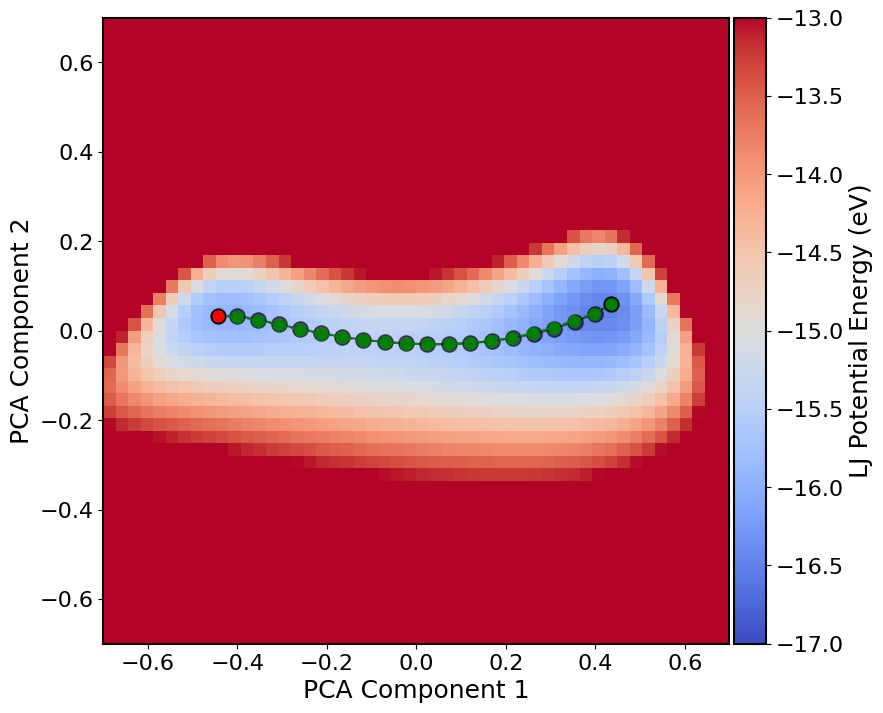

In [37]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(8, 8))

# Plot the LJ energy contour map with extent
im = ax.imshow(
    lj_energies,
    cmap="coolwarm",
    alpha=1,
    vmin=-17,
    vmax=-13,
    extent=(x_min, x_max, y_min, y_max),
    origin="lower"
)
plt.ylim(-0.2, 0.2)


# Force square shape visually
ax.set_box_aspect(1)

# Create an axes divider and append a colorbar axes that matches image height
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("LJ Potential Energy (eV)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# Plot the true NEB path (bigger, fainter black circles)
ax.plot(pca_x, pca_y, marker='o', linestyle='-', color="black", 
        markersize=11, alpha=0.6, label="Classical NEB Path")
ax.scatter(pca_x[0], pca_y[0], color="green", s=100, edgecolors="black", label="Start (Min 1)", zorder=3)
ax.scatter(pca_x[-1], pca_y[-1], color="red", s=100, edgecolors="black", label="End (Min 2)", zorder=3)

# Plot the BAX path in bright orange
path_pca = pca.transform(path)
ax.plot(path_pca[:, 0], path_pca[:, 1], marker='o', linestyle='--', 
        label="NN-BAX Path", color="green", markersize=8)
#ax.text(path_pca[0, 0], path_pca[0, 1], f"{i}", fontsize=12, fontweight='bold', color="#FFA500", zorder=4)

# Axis labels and ticks
ax.set_xlabel("PCA Component 1", fontsize=18)
ax.set_ylabel("PCA Component 2", fontsize=18)
ax.tick_params(axis='both', labelsize=16)

# Remove the title
# ax.set_title("...") ← removed

#ax.legend(fontsize=15)

plt.tight_layout()
plt.show()


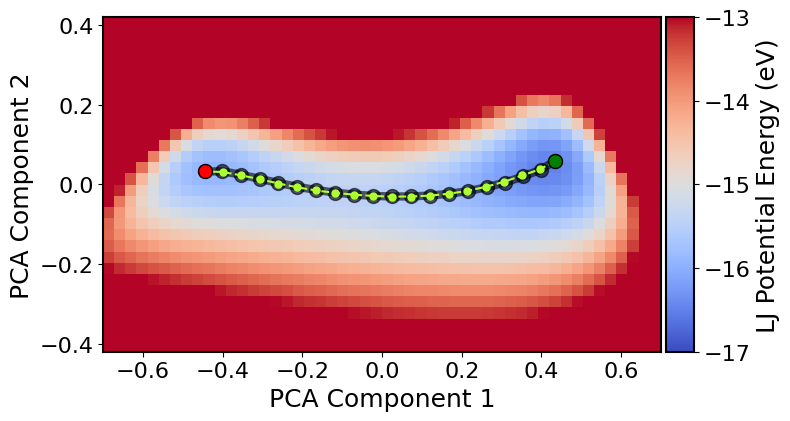

In [38]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(8, 8))

# Plot the LJ energy contour map with extent
im = ax.imshow(
    lj_energies,
    cmap="coolwarm",
    alpha=1,
    vmin=-17,
    vmax=-13,
    extent=(x_min, x_max, y_min, y_max),
    origin="lower"
)

# Keep the current x-limits
x_min_current, x_max_current = ax.get_xlim()
y_half_range = 0.6 * (x_max_current - x_min_current) / 2
ax.set_ylim(-y_half_range, y_half_range)

# Keep square shape
ax.set_aspect('equal', adjustable='box')

# Create an axes divider and append a colorbar axes that matches image height
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("LJ Potential Energy (eV)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# Plot the true NEB path (bigger, fainter black circles)
ax.plot(pca_x, pca_y, marker='o', linestyle='-', color="black", 
        markersize=10, linewidth = 6, alpha=0.6, label="Classical NEB Path")
ax.scatter(pca_x[0], pca_y[0], color="green", s=100, edgecolors="black", label="Start (Min 1)", zorder=3)
ax.scatter(pca_x[-1], pca_y[-1], color="red", s=100, edgecolors="black", label="End (Min 2)", zorder=3)

# Plot the BAX path in bright orange
path_pca = pca.transform(path)
ax.plot(path_pca[:, 0], path_pca[:, 1], marker='o', linestyle='--', 
        label="NN-BAX Path", color="greenyellow", markersize=5)

# Axis labels and ticks
ax.set_xlabel("PCA Component 1", fontsize=18)
ax.set_ylabel("PCA Component 2", fontsize=18)
ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.show()


In [39]:
import py3Dmol
import numpy as np

# Convert to an XYZ string:
coords = initial_ase.get_positions()
xyz   = "7\n\n" + "\n".join(
    f"Ar {x:.4f} {y:.4f} {z:.4f}" for x, y, z in coords
)

view = py3Dmol.view(width=1000, height=1000)
view.addModel(xyz, 'xyz')
view.setStyle({
    'sphere': {'radius': 0.4, },
    'stick':  {'radius': 0.05, 'color': 'lightgray'}
})
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [40]:
import py3Dmol
import numpy as np

# Convert to an XYZ string:
coords = final_ase.get_positions()
xyz   = "7\n\n" + "\n".join(
    f"Ar {x:.4f} {y:.4f} {z:.4f}" for x, y, z in coords
)

view = py3Dmol.view(width=1000, height=1000)
view.addModel(xyz, 'xyz')
view.setStyle({
    'sphere': {'radius': 0.4, },
    'stick':  {'radius': 0.05, 'color': 'lightgray'}
})
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Supplementary Material Plots

### Transition State Prediction

In [41]:
# Compute predicted path energies
path_energy = np.array([compute_lj_energy(pos) for pos in subset_history_numpy[converged_index]])
max_energy_index_BAX = np.argmax(path_energy)

max_energy_index_classical = np.argmax(energies)

print(max_energy_index_BAX,max_energy_index_classical )

11 11


In [42]:
# Convert to an XYZ string:
coords = subset_history_numpy[converged_index][max_energy_index_BAX].reshape(7, 3)
xyz   = "7\n\n" + "\n".join(
    f"Ar {x:.4f} {y:.4f} {z:.4f}" for x, y, z in coords
)

view = py3Dmol.view(width=1000, height=1000)
view.addModel(xyz, 'xyz')
view.setStyle({
    'sphere': {'radius': 0.4, 'color': 'c' },
    'stick':  {'radius': 0.05, 'color': 'lightgray'}
})
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [43]:
# Convert to an XYZ string:
coords = images_ase[max_energy_index_classical].get_positions()
xyz   = "7\n\n" + "\n".join(
    f"Ar {x:.4f} {y:.4f} {z:.4f}" for x, y, z in coords
)

view = py3Dmol.view(width=1000, height=1000)
view.addModel(xyz, 'xyz')
view.setStyle({
    'sphere': {'radius': 0.4, 'color': 'c'},
    'stick':  {'radius': 0.05, 'color': 'lightgray'}
})
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Convergence Plot (for all four)

In [44]:
with open("results/8_08_NHLJ38_BAX100_NEB65_Epochs=50_fmax=0_6_finalSuiteNeurIPS_mae_Nm1_on_N.pkl", "rb") as f:
    mae_Nm1_on_N_LJ38_1min = np.array(pickle.load(f))
    
    
with open("results/8_08_ELJ38_BAX100_NEB70_Epochs=50_fmax=0_1_finalSuiteNeurIPS_mae_Nm1_on_N.pkl", "rb") as f:
    mae_Nm1_on_N_LJ38_0min = np.array(pickle.load(f))
    
    
with open("results/8_08_SHLJ7_BAX100_NEB180_Epochs=50_fmax=0_3_finalSuiteNeurIPS_mae_Nm1_on_N.pkl", "rb") as f:
    mae_Nm1_on_N_LJ7_3min = np.array(pickle.load(f))
    
with open("results/8_08_ELJ7_BAX80_NEB25_Epochs=50_fmax=0_1_finalSuiteNeurIPS_mae_Nm1_on_N.pkl", "rb") as f:
    mae_Nm1_on_N_LJ7_0min = np.array(pickle.load(f))
    
conv_index_LJ7_0min = 17
conv_index_LJ7_3min = 25
conv_index_LJ38_0min = 35
conv_index_LJ38_1min = 22

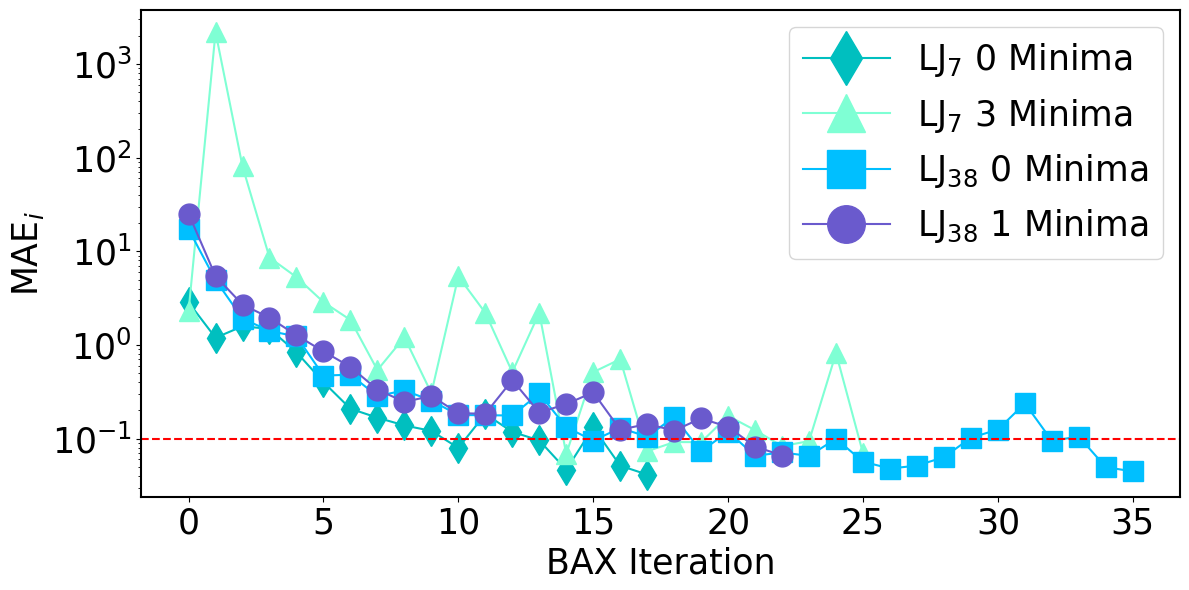

In [45]:
# --- Plot ---
plt.figure(figsize=(12, 6))

# Color mapping per your request + updated legend labels with subscripts
plt.plot(mae_Nm1_on_N_LJ7_0min[:conv_index_LJ7_0min+1],
         label=r"LJ$_7$ 0 Minima", color="c", lw=1.5, marker='d', markersize=15)

plt.plot(mae_Nm1_on_N_LJ7_3min[:conv_index_LJ7_3min+1],
         label=r"LJ$_7$ 3 Minima", color="aquamarine", lw=1.5, marker='^', markersize=15)

plt.plot(mae_Nm1_on_N_LJ38_0min[:conv_index_LJ38_0min+1],
         label=r"LJ$_{38}$ 0 Minima", color="deepskyblue", lw=1.5, marker='s', markersize=15)

plt.plot(mae_Nm1_on_N_LJ38_1min[:conv_index_LJ38_1min+1],
         label=r"LJ$_{38}$ 1 Minima", color="slateblue", lw=1.5, marker='o', markersize=15)

# Red dashed horizontal line
plt.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)

# Labels
plt.xlabel("BAX Iteration", fontsize=25)
plt.ylabel(r"MAE$_i$", fontsize=25)  # subscript i

# Legend bigger + larger markers in legend
plt.legend(fontsize=25, markerscale=1.8, handlelength=2.5)

# Log scale
plt.yscale('log')

# Tick sizes
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.tight_layout()
plt.show()


# Hyperparam Robustness Test

In [46]:
def converged_index_which(mae_hist, fmax_hist, t_m, t_f, p):
    converged_indices = []

    for i in range(len(mae_hist)):
        if mae_hist[i] < t_m and fmax_hist[i] < t_f:
            converged_indices.append(i)

    converged_index = converged_indices[p-1]
    return converged_index

In [47]:
thresh_mae = 0.1
thresh_fmax = 0.1
patience_num = 2


converged_index_which(mae_Nm1_on_N, fmax_history, thresh_mae, thresh_fmax, patience_num)

18

In [50]:
m_samples = [0.05, 0.1, 0.15, 0.2]
thresh_mae = 0.1
thresh_fmax = 0.1
patience_num = 2

mae_converged_indices = []

for i in range(len(m_samples)):
    conv_ind = converged_index_which(mae_Nm1_on_N, fmax_history, m_samples[i], thresh_fmax, patience_num)
    mae_converged_indices.append(conv_ind)
    
mae_converged_indices

[28, 18, 18, 15]

In [51]:
n_samples = np.array([1, 1.5, 2, 2.5])
t_samples = 0.05 * n_samples
thresh_mae = 0.1
thresh_fmax = 0.1
patience_num = 2

fmax_converged_indices = []

for i in range(len(m_samples)):
    conv_ind = converged_index_which(mae_Nm1_on_N, fmax_history, thresh_mae, t_samples[i], patience_num)
    fmax_converged_indices.append(conv_ind)
    
fmax_converged_indices

[50, 28, 18, 18]

In [52]:
p_samples = [1, 2, 3, 4]
thresh_mae = 0.1
thresh_fmax = 0.1
patience_num = 2

p_converged_indices = []

for i in range(len(m_samples)):
    conv_ind = converged_index_which(mae_Nm1_on_N, fmax_history, thresh_mae, thresh_fmax, p_samples[i])
    p_converged_indices.append(conv_ind)
    
p_converged_indices

[13, 18, 20, 21]

# plotting

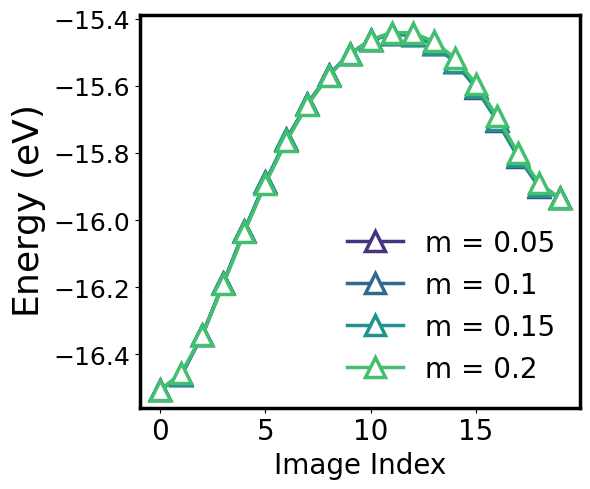

In [59]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.linewidth'] = 2.5

# Assume m_samples is length 4
# Assume mae_converged_indices has corresponding converged indices
# Example:
# m_samples = [1, 2, 4, 8]
# mae_converged_indices = [12, 15, 18, 20]

plt.figure(figsize=(6, 5))

# --- Gradient color map for 4 curves ---
cmap = plt.cm.viridis
colors = [cmap(i) for i in np.linspace(0.15, 0.7, len(m_samples))]

# --- Plot each curve for each m ---
for m, conv_idx, col in zip(m_samples, mae_converged_indices, colors):

    # Compute predicted energies for THIS m
    path_energy_m = np.array([
        compute_lj_energy(pos)
        for pos in subset_history_numpy[conv_idx]
    ])

    plt.plot(
        path_energy_m,
        marker='^',
        linestyle='-',
        color=col,
        markersize=14,
        markerfacecolor='white',
        markeredgecolor=col,
        markeredgewidth=2.5,
        linewidth=2.5,
        label=f"m = {m}"
    )

# --- Labels ---
plt.xlabel("Image Index", fontsize=20)
plt.ylabel(r"Energy ($\mathrm{eV}$)", fontsize=26)

# --- Tick fonts ---
plt.xticks(ticks=range(0, len(energies), 5), fontsize=20)
plt.yticks(fontsize=18)

# --- Legend ---
plt.legend(fontsize=20, frameon=False, markerscale=1)

plt.tight_layout()
plt.show()


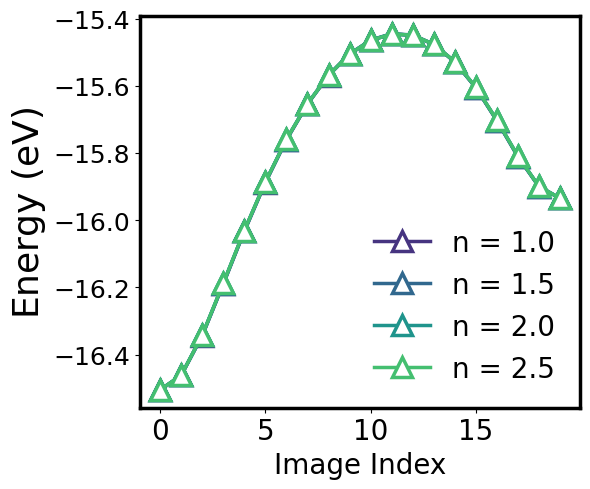

In [60]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.linewidth'] = 2.5

plt.figure(figsize=(6, 5))

# --- Gradient color map for N curves ---
cmap = plt.cm.viridis
colors = [cmap(i) for i in np.linspace(0.15, 0.7, len(n_samples))]

# --- Plot each curve for each n ---
for n, conv_idx, col in zip(n_samples, fmax_converged_indices, colors):

    # Compute predicted energies for THIS n
    path_energy_n = np.array([
        compute_lj_energy(pos)
        for pos in subset_history_numpy[conv_idx]
    ])

    plt.plot(
        path_energy_n,
        marker='^',
        linestyle='-',
        color=col,
        markersize=14,
        markerfacecolor='white',
        markeredgecolor=col,
        markeredgewidth=2.5,
        linewidth=2.5,
        label=f"n = {n}"
    )

# --- Labels ---
plt.xlabel("Image Index", fontsize=20)
plt.ylabel(r"Energy ($\mathrm{eV}$)", fontsize=26)

# --- Tick fonts ---
plt.xticks(ticks=range(0, len(energies), 5), fontsize=20)
plt.yticks(fontsize=18)

# --- Legend ---
plt.legend(fontsize=20, frameon=False, markerscale=1)

plt.tight_layout()
plt.show()


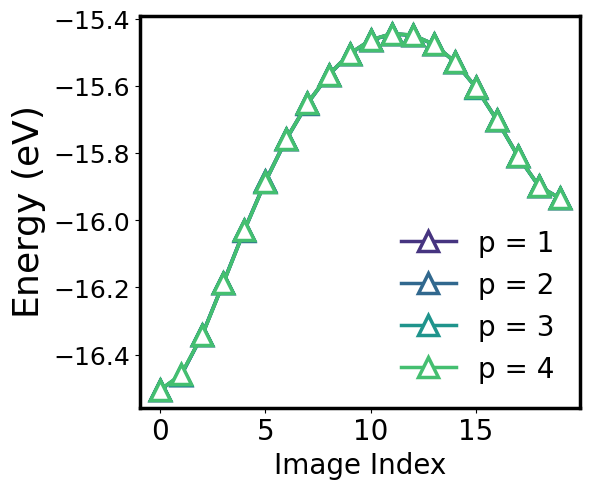

In [61]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.linewidth'] = 2.5

plt.figure(figsize=(6, 5))

# --- Gradient colormap for however many p values you have ---
cmap = plt.cm.viridis
colors = [cmap(i) for i in np.linspace(0.15, 0.7, len(p_samples))]

# --- Plot each curve for each p ---
for p, conv_idx, col in zip(p_samples, p_converged_indices, colors):

    # Compute predicted energies for THIS p
    path_energy_p = np.array([
        compute_lj_energy(pos)
        for pos in subset_history_numpy[conv_idx]
    ])

    plt.plot(
        path_energy_p,
        marker='^',
        linestyle='-',
        color=col,
        markersize=14,
        markerfacecolor='white',
        markeredgecolor=col,
        markeredgewidth=2.5,
        linewidth=2.5,
        label=f"p = {p}"
    )

# --- Labels ---
plt.xlabel("Image Index", fontsize=20)
plt.ylabel(r"Energy ($\mathrm{eV}$)", fontsize=26)

# --- Tick fonts ---
plt.xticks(ticks=range(0, len(energies), 5), fontsize=20)
plt.yticks(fontsize=18)

# --- Legend ---
plt.legend(fontsize=20, frameon=False, markerscale=1)

plt.tight_layout()
plt.show()
